# Step 2 — State-Level Competitiveness
**Objective:** Disaggregate Brazil's national trade picture to the state level — identifying which states drive exports and imports, which sectors and products dominate each region, how trade balances vary, how growth is distributed, and whether the China dependency identified in Step 1 is uniform or concentrated.

This notebook covers:
##### 1. State Trade Participation — Who Drives Brazilian Trade?
##### 1.1 State Trade by Export Value
##### 1.2 Trade Balance by State — Net Exporters vs Net Importers (2025)
##### 1.3 State Trade Balance Through Economic Cycles — Which States Were Most Resilient?
##### 2. State Export Growth Dynamics — Which States Are Rising and Falling?
##### 3. Regional Export and Import Distribution
##### 3.1 How Brazil's Five Macro-Regions Compare
##### 3.2 Where Brazil's Five Macro-Regions Source From
##### 4. Export Sector Structure — What Brazil's States and Regions Actually Sell
##### 4.1 Top 10 Export Sectors by State (SH2): Ranked Table with Share of State Total
##### 4.2 Brazil Annual Export Composition by Sector (1997–2025)
##### 5. Import Sector Structure — What Brazil's States and Regions Actually Buy
##### 5.1 Top 10 Import Sectors by State (SH2): Ranked Table with Share of State Total
##### 5.2 Brazil Annual Import Composition by Sector (1997–2025)
##### 6. Product-Level Detail — Top 10 NCM Products by State and Region
##### 7. China Dependency at State Level — Is the 28.7% National Average Uniform?
##### 7.1 China Share of State Exports
##### 7.2 What Each State Sends to China
##### 8. Monthly Export Volatility by State — How Stable Are State Export Flows?
##### 9. Monthly Import Volatility by State — How Stable Are State Import Flows?
##### 10. State Trade Hub Profiles — Export and Import Fingerprint for Each State
##### 11. Regional Trade Hub Profiles — What Each Macro-Region Specialises In
##### 12. Commodities vs Processed Products
##### 12.1 State and Region
##### 12.2 National Level Comparison
##### 12.3 Overview
##### 13. YoY Export Growth by State — Identifying Fast-Growing and Declining States
##### 14. Unit Price (USD/kg) by State — Distinguishing Commodity vs Value-Added Exporters
##### 15. Volume vs Value Decomposition — Is State Export Growth Driven by Price or Volume?
##### 16. Market Concentration — Top 3 Destination Share and HHI Diversification Index
##### 17. How Trade-Self-Sufficient Is Each State?
##### 17.1 Coverage Ratio by State — How Trade-Self-Sufficient Is Each State?
##### 17.2 Coverage Ratio by Region
##### 18. Key Findings

## Setup

This section initializes the database connection and establishes the time horizon of the analysis.  
The full series covers 1997–2025, while a recent 10-year window (2016–2025) is used to analyze monthly patterns and variability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from IPython.display import display

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data which distorts trend visuals
MAX_YEAR  = 2025
MIN_YEAR  = 1997
## Monthly box plot window — last 10 years
BOX_START = 2016

Connected to database successfully


## 2.1 — State Trade Participation — Who Drives Brazilian Trade?


***Note:** REGIAO NAO DECLARADA (UNDECLARED) is retained to preserve total national trade volume. Its exports ($2.31bn) cannot be attributed to a specific state and will be excluded from any state-level structural analysis.*

### 2.1.1 - State Trade by Export Value
Ranking all states by export, import and balance value in the most recent year — establishing which states dominate national trade and how concentrated Brazil's trade geography is.

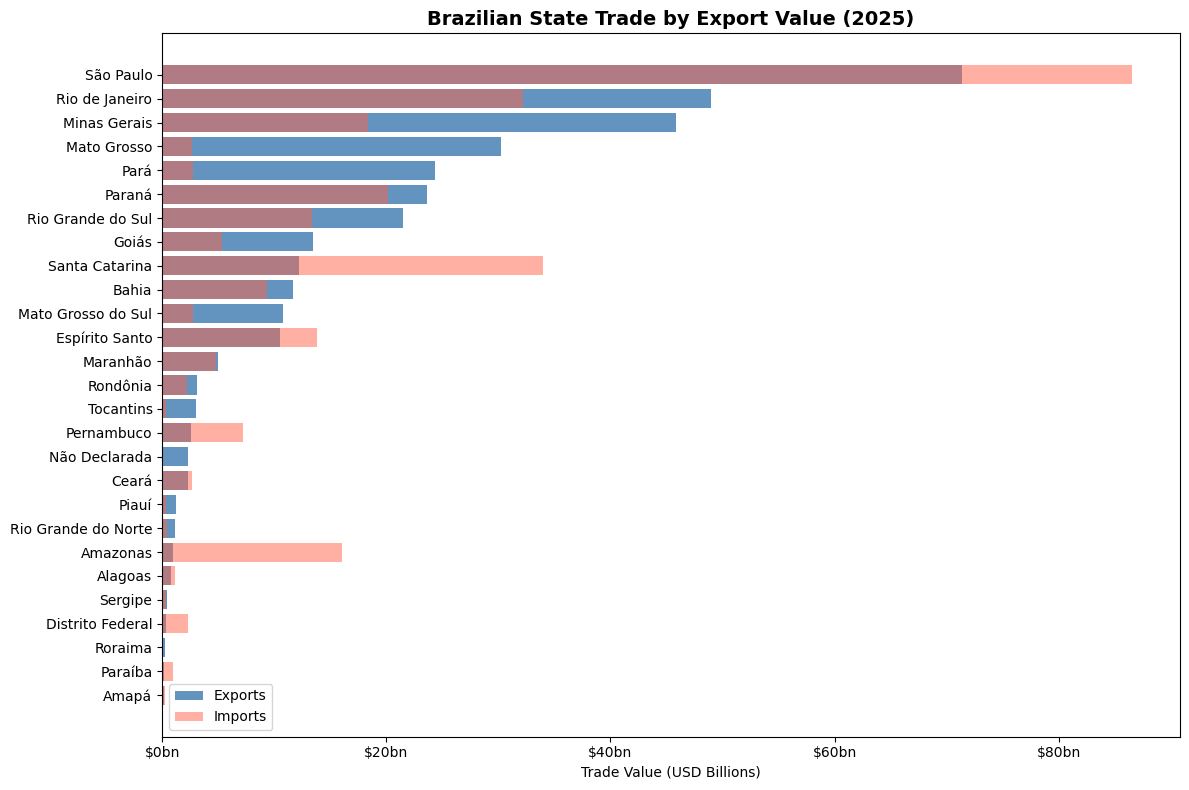


All states — Exports, Imports and Balance (2025)
              state      region uf  exports_usd_bn  imports_usd_bn  balance_usd_bn
          São Paulo   Southeast SP           71.39           86.50          -15.11
     Rio de Janeiro   Southeast RJ           48.98           32.17           16.80
       Minas Gerais   Southeast MG           45.83           18.33           27.50
        Mato Grosso Center-West MT           30.19            2.62           27.57
               Pará       North PA           24.34            2.74           21.59
             Paraná       South PR           23.65           20.15            3.50
  Rio Grande do Sul       South RS           21.53           13.38            8.15
              Goiás Center-West GO           13.47            5.36            8.11
     Santa Catarina       South SC           12.20           33.99          -21.80
              Bahia   Northeast BA           11.63            9.31            2.32
 Mato Grosso do Sul Center-West MS   

In [2]:
query_state_trade = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd,
           COALESCE(e.exports_usd, 0) - COALESCE(i.imports_usd, 0) AS balance_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""

df_state = pd.read_sql(query_state_trade, engine)
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
df_state['balance_usd_bn'] = (df_state['balance_usd'] / 1e9).round(2)


## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_state['region'] = df_state['region'].map(region_name_map).fillna(df_state['region'])


df_top = df_state.head(27).sort_values('exports_usd_bn')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_top['state'], df_top['exports_usd_bn'], color='steelblue', alpha=0.85, label='Exports')
ax.barh(df_top['state'], df_top['imports_usd_bn'], color='tomato', alpha=0.5, label='Imports')
ax.set_title(f"Brazilian State Trade by Export Value ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Value (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend()
plt.tight_layout()
plt.savefig('output_2_1_state_trade.png', dpi=150)
plt.show()

total_row = pd.DataFrame([{
    'state': 'TOTAL',
    'region': '',
    'uf': '',
    'exports_usd_bn': df_state['exports_usd_bn'].sum().round(2),
    'imports_usd_bn': df_state['imports_usd_bn'].sum().round(2),
    'balance_usd_bn': df_state['balance_usd_bn'].sum().round(2)
}])

df_state_print = pd.concat([df_state, total_row], ignore_index=True)

print(f"\nAll states — Exports, Imports and Balance ({MAX_YEAR})")
print(df_state_print[['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']].to_string(index=False))

### Overview

**National concentration is extreme.** The top 5 exporting states — São Paulo, Rio de Janeiro, Minas Gerais, Mato Grosso and Pará — account for approximately \\$221bn of Brazil's \\$348bn total exports, or roughly 64% of national export value concentrated in five states across three regions.

**The Southeast dominates on both sides.** São Paulo (\\$71.39bn exports, \$86.50bn imports), Rio de Janeiro (\\$48.98bn, \\$32.17bn) and Minas Gerais (\\$45.83bn, \\$18.33bn) together represent the largest single regional trade cluster in Brazil. Their combined export value of \\$166bn exceeds the entire output of every other region combined.

**17 states run surpluses, 10 run deficits.** The largest surpluses are Mato Grosso (+\$27.57bn) and Minas Gerais (+\\$27.50bn) — both commodity-driven export economies with minimal import needs relative to their export scale. The largest deficits are Santa Catarina (-\\$21.80bn), Amazonas (-\\$15.13bn) and São Paulo (-\\$15.11bn), each driven by structurally different factors.

**Santa Catarina's deficit is the most anomalous finding.** It is the 11th largest exporter (\\$12.20bn) but the 2nd largest importer (\\$33.99bn) — importing nearly three times what it exports. No other state of comparable export size runs a deficit of this magnitude. This implies a significant import hub or re-export function that goes beyond its domestic industrial needs and warrants product-level investigation in Step 5.

**Amazonas confirms the Zona Franca dynamic.** \$0.94bn in exports vs \\$16.06bn in imports — a coverage ratio of approximately 0.06. The Free Trade Zone is structurally an import platform that sources components globally and manufactures for the domestic Brazilian market rather than for export. Despite generating the highest USD/kg value density in Step 2b, Amazonas runs the second largest absolute import deficit in the country.

**The Center-West states are the purest surplus generators.** Mato Grosso (+\\$27.57bn), Mato Grosso do Sul (+\\$8.04bn) and Goiás (+\\$8.11bn) all run large surpluses with negligible import volumes relative to their exports. This reflects the agricultural frontier profile — bulk commodity exports require minimal imported inputs compared to industrial production.

> ⚠️ *Não Declarada (\\$2.31bn exports, \\$0 imports) represents transactions where the origin state was not recorded in the MDIC system. At \\$2.31bn this is not negligible — it would rank 17th among all states. The zero imports figure is likely a recording artefact rather than a true reflection of undeclared import origins.*

---
---

### 2.1.2 — Trade Balance by State: Net Exporters vs Net Importers (2025)
Which states run trade surpluses and which run deficits? The coverage ratio (exports/imports) reveals each state's degree of external trade dependency.

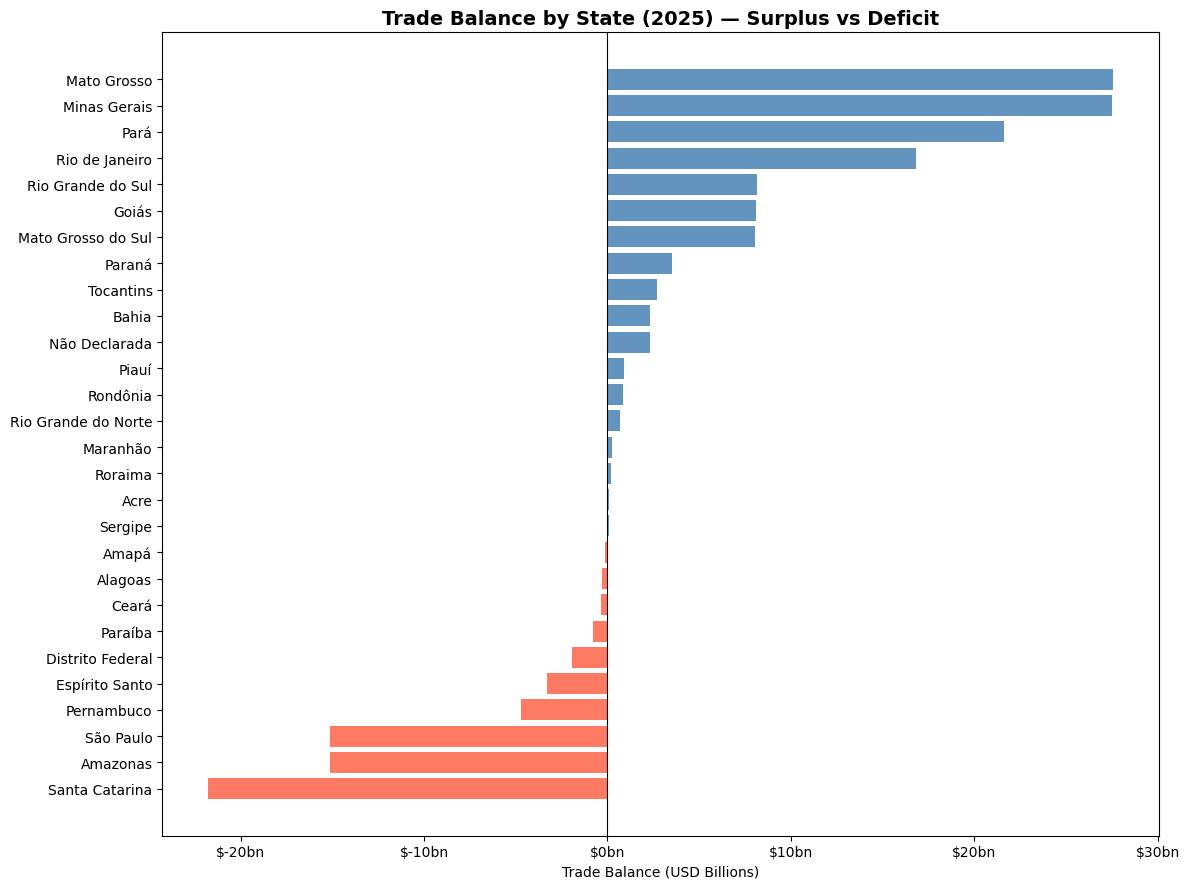

Net exporting states (2025):
              state      region  balance_usd_bn
        Mato Grosso Center-West           27.57
       Minas Gerais   Southeast           27.50
               Pará       North           21.59
     Rio de Janeiro   Southeast           16.80
  Rio Grande do Sul       South            8.15
              Goiás Center-West            8.11
 Mato Grosso do Sul Center-West            8.04
             Paraná       South            3.50
          Tocantins       North            2.70
              Bahia   Northeast            2.32
      Não Declarada  Undeclared            2.31
              Piauí   Northeast            0.90
           Rondônia       North            0.85
Rio Grande do Norte   Northeast            0.69
           Maranhão   Northeast            0.26
            Roraima       North            0.20
               Acre       North            0.09
            Sergipe   Northeast            0.06

Net importing states (2025):
           state      region 

In [3]:
## Uses df_state from 2.1
df_balance = (
    df_state[
        (df_state['state'] != 'Exterior')  # remove unwanted category
    ][['state', 'uf', 'region', 'balance_usd_bn']]
    .sort_values('balance_usd_bn')
)
colors = ['tomato' if x < 0 else 'steelblue' for x in df_balance['balance_usd_bn']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_balance['state'], df_balance['balance_usd_bn'], color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f"Trade Balance by State ({MAX_YEAR}) — Surplus vs Deficit", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Balance (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_3_state_balance.png', dpi=150)
plt.show()

surplus_states = df_balance[df_balance['balance_usd_bn'] > 0].sort_values('balance_usd_bn', ascending=False)
deficit_states = df_balance[df_balance['balance_usd_bn'] < 0].sort_values('balance_usd_bn')

print(f"Net exporting states ({MAX_YEAR}):")
print(surplus_states[['state', 'region', 'balance_usd_bn']].to_string(index=False))
print(f"\nNet importing states ({MAX_YEAR}):")
print(deficit_states[['state', 'region', 'balance_usd_bn']].to_string(index=False))

#### Overview

**18 states run surpluses, 10 run deficits.** The surplus states are predominantly commodity exporters from Centro-Oeste, Norte and Nordeste (elaborated in 2b). The deficit states are predominantly industrial, administrative or import-dependent economies from Sul, Sudeste and Nordeste.

##### Surplus States

The top four surpluses — Mato Grosso (+\\$27.57bn), Minas Gerais (+\\$27.50bn), Pará (+\\$21.59bn) and Rio de Janeiro (+\\$16.80bn) — together account for the bulk of Brazil's national trade surplus. All four are commodity-driven: soybeans, iron ore, iron ore and oil respectively (as seen in 2b.1 and 2b.7).

The Centro-Oeste — Mato Grosso, Mato Grosso do Sul and Goiás all run surpluses, confirming the region's role as a net contributor to Brazil's export balance. None of the three has meaningful import volumes relative to its export scale.

##### Deficit States

**Santa Catarina (-\\$21.80bn)** is the largest deficit state and the most structurally anomalous. Its deficit exceeds its entire export value (\\$12.20bn), implying it imports nearly three times what it exports. Further investigation is required to evaluate if it is functioning as a regional import hub rather than simply a net importer. What drives \\$33.99bn in imports into a state with \\$12.20bn in exports requires product-level investigation in Step 5.

**Amazonas (-\\$15.13bn) and São Paulo (-\\$15.11bn)** are almost identical in deficit magnitude despite being completely different economies:
- São Paulo's deficit reflects the import intensity of industrial production (elaborate in step 2b) — capital goods, components, chemicals and energy for Brazil's largest manufacturing base
- Amazonas's deficit reflects the Zona Franca structure — imported components assembled domestically for the Brazilian consumer market rather than for export

**Distrito Federal (-\\$1.94bn)** runs a deficit as expected — it is an administrative capital with minimal productive export base and imports goods for government and consumption purposes.

##### Regional Balance Pattern

| Region | Net position | Key driver |
|---|---|---|
| Centro-Oeste | Strongly positive | Agricultural commodity surpluses |
| Norte | Mixed — large surpluses (Pará) offset by Amazonas deficit | Mineral extraction vs Zona Franca |
| Sul | Mixed — Paraná and RS surplus offset by SC deficit | SC deficit anomaly |
| Sudeste | Mixed — MG and RJ surplus offset by SP deficit | Commodity surplus vs industrial deficit |
| Nordeste | Predominantly balanced considering small values | Small agricultural surpluses dominate |

> ⚠️ *Santa Catarina's -\\$21.80bn deficit is the single most analytically unresolved finding in Step 2. Its scale relative to the state's export base (coverage ratio ~0.36) is without parallel among comparable-sized states and requires product-level import data analysis in Step 5 to explain.*

---
---

### 2.1.3 — Trade Balance by State:  Which States Were Most Resilient?

Comparing state-level trade balances across the key periods identified in Step 1 (1997, 2009, 2014, 2020, 2025) — showing which states drove Brazil's national trade deficit during the 2014 recession and which demonstrated the greatest resilience across all three shock periods (2009 global recession, 2014 domestic recession, 2020 COVID).

Only the 12 largest export states by 2025 export value are included, representing states with sufficient export scale to meaningfully influence Brazil's national trade position. Smaller states are excluded as their individual contribution to aggregate dynamics is negligible.

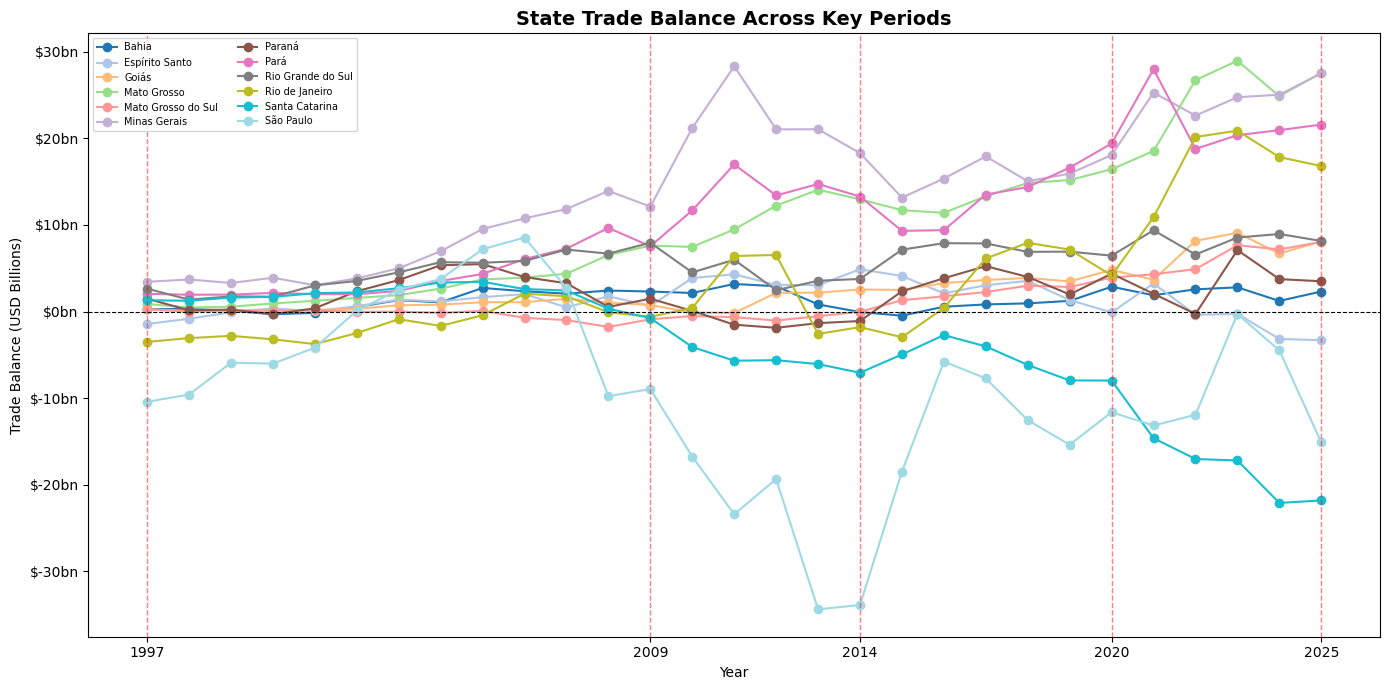


State trade balance across all years (USD bn):


C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\898191218.py:111: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_balance, subset=df_display.columns[1:])


State,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Acre,$-0.0,$-0.0,$0.0,$-0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$-0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.1,$0.1,$0.0,$0.1,$0.1
Alagoas,$0.2,$0.2,$0.2,$0.2,$0.2,$0.2,$0.3,$0.4,$0.5,$0.6,$0.4,$0.7,$0.7,$0.7,$0.9,$0.6,$0.2,$0.0,$0.1,$-0.2,$0.1,$-0.1,$-0.3,$-0.2,$-0.3,$-0.2,$0.2,$0.0,$-0.3
Amapá,$0.0,$0.1,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.1,$0.1,$0.1,$0.1,$0.1,$0.3,$0.5,$0.3,$0.3,$0.3,$0.2,$0.2,$0.2,$0.1,$0.1,$0.1,$-0.1,$-0.6,$-1.0,$-0.4,$-0.1
Amazonas,$-4.0,$-2.7,$-2.4,$-3.1,$-2.4,$-2.0,$-2.1,$-3.1,$-3.0,$-4.7,$-5.8,$-8.9,$-6.2,$-10.0,$-11.8,$-12.5,$-13.3,$-12.2,$-8.2,$-5.7,$-8.0,$-9.3,$-9.4,$-8.9,$-12.4,$-13.3,$-11.7,$-15.2,$-15.1
Bahia,$0.3,$0.3,$0.1,$-0.3,$-0.1,$0.5,$1.3,$1.1,$2.7,$2.4,$2.1,$2.4,$2.3,$2.1,$3.2,$2.9,$0.8,$-0.1,$-0.5,$0.6,$0.8,$0.9,$1.2,$2.9,$1.9,$2.6,$2.8,$1.2,$2.3
Ceará,$-0.3,$-0.3,$-0.2,$-0.2,$-0.1,$-0.1,$0.2,$0.3,$0.3,$-0.1,$-0.3,$-0.3,$-0.1,$-0.9,$-1.0,$-1.6,$-1.9,$-1.5,$-1.6,$-2.2,$-0.1,$-0.2,$-0.1,$-0.6,$-1.1,$-2.6,$-1.1,$-1.6,$-0.3
Distrito Federal,$-0.3,$-0.4,$-0.7,$-0.5,$-0.6,$-0.6,$-0.5,$-0.5,$-0.7,$-0.8,$-1.1,$-0.9,$-1.0,$-1.4,$-1.1,$-0.9,$-1.1,$-0.9,$-0.9,$-1.3,$-0.8,$-0.7,$-0.9,$-1.2,$-3.3,$-2.0,$-1.8,$-1.3,$-1.9
Espírito Santo,$-1.4,$-0.8,$-0.1,$0.4,$0.0,$0.6,$1.4,$1.2,$1.7,$2.0,$0.5,$1.8,$0.7,$3.9,$4.3,$3.1,$3.0,$4.9,$4.1,$2.1,$3.0,$3.5,$1.3,$-0.1,$3.2,$-0.4,$-0.3,$-3.2,$-3.3
Goiás,$0.2,$0.1,$0.0,$0.2,$0.2,$0.3,$0.7,$0.8,$1.1,$1.1,$1.5,$1.0,$0.8,$-0.1,$-0.2,$2.2,$2.2,$2.5,$2.5,$3.3,$3.6,$3.9,$3.5,$4.8,$3.7,$8.2,$9.1,$6.7,$8.1
Maranhão,$0.3,$0.3,$0.3,$0.3,$-0.3,$-0.2,$0.1,$0.5,$0.3,$-0.0,$-0.2,$-1.3,$-0.8,$-0.9,$-3.2,$-4.0,$-4.5,$-4.3,$-0.6,$0.1,$0.5,$0.7,$-0.0,$1.4,$0.2,$-1.8,$0.6,$1.6,$0.3


In [4]:
## Key periods from Step 1 analysis
key_years = [1997, 2009, 2014, 2020, MAX_YEAR]
key_years_2 = list(range(1997, MAX_YEAR + 1))

query_balance_periods = f"""
    SELECT year, uf, state,
           COALESCE(MAX(exports_usd), 0) - COALESCE(MAX(imports_usd), 0) AS balance_usd
    FROM (
        SELECT e."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               SUM(e."VL_FOB") AS exports_usd,
               NULL::numeric AS imports_usd
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" IN ({','.join(map(str, key_years_2))})
        GROUP BY e."CO_ANO", u.sigla, u.nome_estado
        UNION ALL
        SELECT i."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               NULL::numeric AS exports_usd,
               SUM(i."VL_FOB") AS imports_usd
        FROM imp i
        JOIN uf u ON i."SG_UF_NCM" = u.sigla
        WHERE i."CO_ANO" IN ({','.join(map(str, key_years_2))})
        GROUP BY i."CO_ANO", u.sigla, u.nome_estado
    ) t
    GROUP BY year, uf, state
"""

df_periods = pd.read_sql(query_balance_periods, engine)
df_periods['balance_usd_bn'] = (df_periods['balance_usd'] / 1e9).round(2)

## Pivot: rows = states, columns = years
df_periods_pivot = df_periods.pivot(index='state', columns='year', values='balance_usd_bn').fillna(0)

## Focus on top 15 states by absolute balance in MAX_YEAR
top15_balance = df_state.nlargest(12, 'exports_usd_bn')['state'].tolist()
df_periods_plot = df_periods_pivot.loc[df_periods_pivot.index.isin(top15_balance)]

# Creating second layer to create a table
all_balance = df_state[df_state['state'] != 'Não Declarada'].nlargest(27, 'exports_usd_bn')['state'].tolist()
df_all_periods_plot = df_periods_pivot.loc[df_periods_pivot.index.isin(all_balance)]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(key_years))

# Add distinct colors using tab20 colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(df_periods_plot.index)))

for i, state in enumerate(df_periods_plot.index):
    ax.plot(
        key_years_2,
        df_periods_plot.loc[state],
        marker='o',
        label=state,
        linewidth=1.5,
        color=colors[i]  # <-- key addition
    )

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Add vertical lines for key years
for year in key_years:
    ax.axvline(
        x=year,
        linestyle='--',
        linewidth=1,
        color='red',
        alpha=0.5
    )
    
# Titles and labels
ax.set_title("State Trade Balance Across Key Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Trade Balance (USD Billions)")
ax.set_xticks(key_years)
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

plt.tight_layout()
plt.savefig('output_2_4_state_balance_periods.png', dpi=150)
plt.show()


## _______________________Table_________________________________________________________________
df_display = df_all_periods_plot.copy().reset_index()
df_display.columns = ['State'] + [str(col) for col in df_display.columns[1:]]

# Defining the function
def color_balance(val):
    if pd.isna(val):
        return 'color: gray'
    return 'color: #2e7d32' if val >= 0 else 'color: #c62828'

styled = (
    df_display.style
    .set_properties(**{
        'font-size': '11px',
        'text-align': 'right',
        'padding': '4px 8px',
        'white-space': 'nowrap',
    })
    .set_properties(subset=['State'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
    .format(lambda x: f'${x:.1f}' if isinstance(x, (int, float)) else x)
    # APPLY COLORING
    .applymap(color_balance, subset=df_display.columns[1:])
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f5f5f5'),
            ('font-size', '10px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '6px 8px'),
            ('border-bottom', '2px solid #ddd'),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#fafafa'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f4ff'),
        ]},
        {'selector': 'td, th', 'props': [
            ('border-bottom', '1px solid #eee'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('font-family', 'monospace'),
        ]},
    ])
    .hide(axis='index')
)

print(f"\nState trade balance across all years (USD bn):")
display(styled)

#### Overview

Across 1997–2025, three structural patterns emerge: states that expanded surpluses across all three shock periods; states whose balances swung with commodity price cycles; and states whose import dependency deepened regardless of the economic cycle. 

The 2009 global recession, 2014 domestic recession, and 2020 COVID shock produced temporary moderation rather than structural reversals in the majority of states. Espírito Santo and Paraná are the two exceptions where the post-2014 trajectory did not recover.

---

#### States That Strengthened Consistently

**Mato Grosso** expanded its surplus from \\$0.88bn (1997) to \\$27.57bn (2025) without a single period of contraction across all three shock periods.

**Pará** moved from \\$2.05bn (1997) to \\$21.59bn (2025) with only minor moderation at each of the three shocks.

**Rio Grande do Sul** recorded no deficit years across either reference point or any shock period, growing from \\$2.65bn (1997) to \\$8.15bn (2025).

---

#### States With Reversals

**Minas Gerais** peaked at \\$28.32bn (2011), fell to \\$18.30bn (2014), held at \\$18.07bn through COVID, and recovered to \\$27.50bn (2025).

**Rio de Janeiro** moved from -\\$3.50bn (1997) to +\\$16.80bn (2025). In 1997 it was a net importer; by 2025 it is among Brazil's largest surplus states.

**Espírito Santo** reversed from +\\$4.89bn (2014) to -\\$3.30bn (2025) — an \\$8.19bn swing in eleven years with no recovery across subsequent years.

> ⚠️ Espírito Santo's reversal mechanism is unconfirmed. Step 5 (product-level import analysis by state) will determine whether iron ore import volumes are the primary driver.

**Paraná** moved from -\\$1.93bn (2012) to +\\$3.50bn (2025), though the recovery path is not monotonic.

> ⚠️ Drivers of Paraná's recovery are unidentified. Step 4 (trade balances and competitiveness analysis) will investigate whether product mix change, new export markets, or logistics improvements explain the shift.

---

#### Persistent Deficit States

**São Paulo** peaked at -\\$33.88bn (2014) before recovering to -\\$15.11bn (2025). The near-balance of -\\$0.30bn in 2023 is the closest São Paulo has come to balance outside the 2002–2007 window. São Paulo will remain a structural deficit state; its industrial economy requires imported inputs that cannot be substituted domestically.

**Santa Catarina** moved from +\\$1.31bn (1997) to -\\$21.80bn (2025) — a \\$23.11bn deterioration and the largest absolute deterioration of any state in the dataset. The worsening is present across both reference points and all three shock periods including COVID.

> ⚠️ Step 5 (product-level import analysis by state) is required to determine whether Santa Catarina's deterioration reflects industrial input dependency, transshipment dynamics, or both.

---

#### The Center-West Transformation

The three Center-West states reached a combined surplus of \\$43.72bn in 2025, up from \\$1.38bn in 1997. As established in Section 2.12 (commodity vs processed product composition), Center-West exports are overwhelmingly classified as primary commodities — raw agricultural goods, principally soybeans and beef, with minimal processing before export. The surplus expansion reflects volume and price growth in raw commodity exports, not a shift toward higher value-added production.

| State                  | 1997         | 2025          | Change        |
|------------------------|--------------|---------------|---------------|
| Mato Grosso            | +\\$0.88bn     | +\\$27.57bn     | +\\$26.69bn     |
| Goiás                  | +\\$0.25bn     | +\\$8.11bn      | +\\$7.86bn      |
| Mato Grosso do Sul     | +\\$0.25bn     | +\\$8.04bn      | +\\$7.79bn      |
| **Center-West Total**  | **+\\$1.38bn** | **+\\$43.72bn** | **+\\$42.34bn** |

> ⚠️ Step 5 (product-level export analysis by state) will confirm the specific commodity composition driving each state's surplus expansion.

---
---

## 2.2 — State Export Growth Dynamics: Which States Are Rising and Falling?
Tracking the top 8 exporting states from 1997 to 2025 — identifying fast-growing emerging exporters, states in structural decline, and how key economic events impacted different states differently.

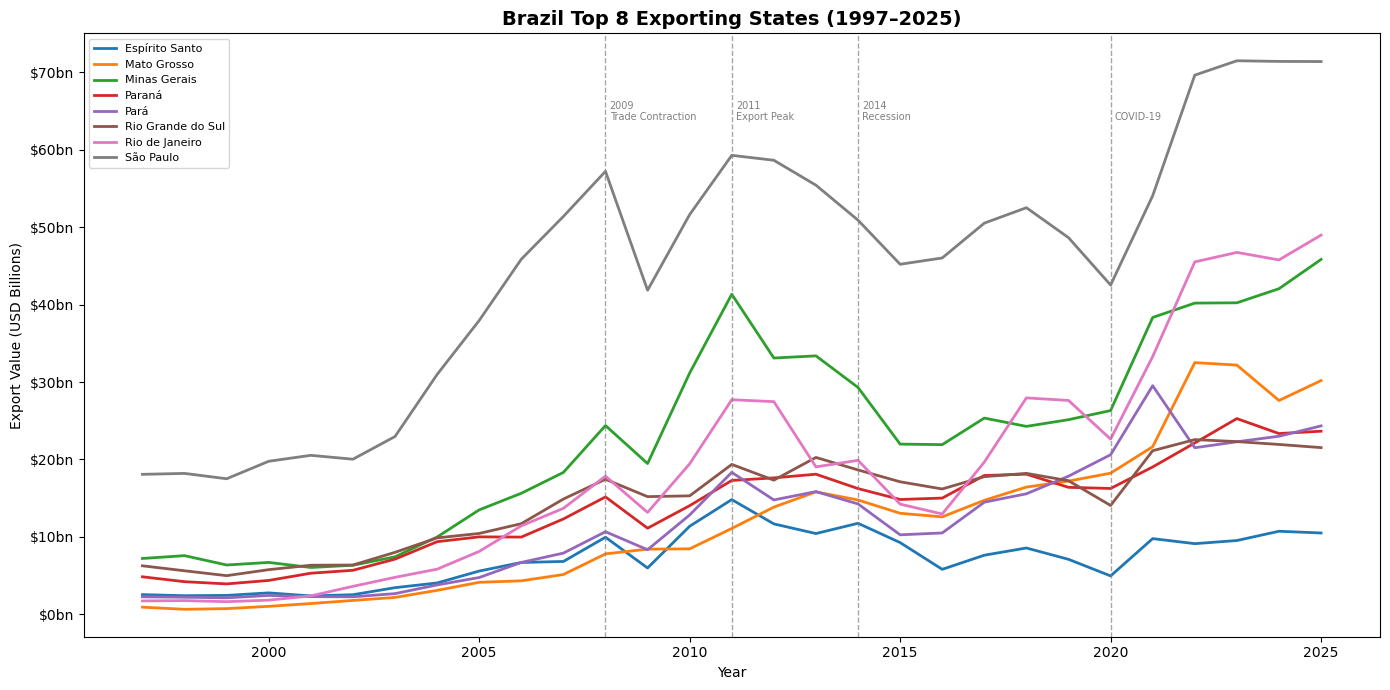

State Export Growth Summary — 1997 to 2025


C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\3557282519.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['exports_usd_bn'].idxmax(), ['year', 'exports_usd_bn']])
C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\3557282519.py:185: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pct, subset=pct_cols)


#,State,Region,Exports 1997 (USD bn),Exports 2025 (USD bn),Total Growth 1997–2025 (%),CAGR 1997–2025 (%),CAGR 2020–2025 — Last 5Y (%),YoY Growth 2024–2025 (%),Peak Year,Peak Exports (USD bn)
1,São Paulo,Southeast,$18.08,$71.39,+294.9%,+5.0%,+10.9%,-0.0%,2023,$71.49
2,Rio de Janeiro,Southeast,$1.73,$48.98,+2728.1%,+12.7%,+16.7%,+7.0%,2025,$48.98
3,Minas Gerais,Southeast,$7.22,$45.83,+535.0%,+6.8%,+11.7%,+9.0%,2025,$45.83
4,Mato Grosso,Center-West,$0.93,$30.19,+3157.0%,+13.2%,+10.6%,+9.3%,2022,$32.51
5,Pará,North,$2.26,$24.34,+975.2%,+8.9%,+3.4%,+5.8%,2021,$29.53
6,Paraná,South,$4.85,$23.65,+387.7%,+5.8%,+7.8%,+1.3%,2023,$25.28
7,Rio Grande do Sul,South,$6.27,$21.53,+243.5%,+4.5%,+8.9%,-1.9%,2022,$22.56
8,Goiás,Center-West,$0.48,$13.47,+2733.3%,+12.7%,+10.6%,+9.4%,2022,$14.15
9,Santa Catarina,South,$2.80,$12.20,+335.3%,+5.4%,+8.5%,+4.4%,2025,$12.20
10,Bahia,Northeast,$1.87,$11.63,+523.1%,+6.8%,+8.2%,-2.3%,2022,$13.92


In [5]:
query_state_time = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_estado
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_state_time = pd.read_sql(query_state_time, engine)
df_state_time['exports_usd_bn'] = df_state_time['exports_usd'] / 1e9

top8_states = (
    df_state_time.groupby('state')['exports_usd']
    .sum().nlargest(8).index.tolist()
)

df_top8 = df_state_time[df_state_time['state'].isin(top8_states)]
df_pivot = df_top8.pivot(index='year', columns='state', values='exports_usd_bn').fillna(0)

## Annotate key periods identified in Step 1
events = {
    2009: ('2009\nTrade Contraction', 2008),
    2011: ('2011\nExport Peak',       2011),
    2014: ('2014\nRecession',         2014.0),
    2020: ('COVID-19',                2020)
}

fig, ax = plt.subplots(figsize=(14, 7))
for state in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[state], label=state, linewidth=2)
for year, (label, xpos) in events.items():
    ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(xpos + 0.1, ax.get_ylim()[1] * 0.85, label, fontsize=7, color='gray')

ax.set_title(f"Brazil Top 8 Exporting States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_2_state_exports_time.png', dpi=150)
plt.show()

## ── Growth summary table ─────────────────────────────────────────────────────
region_map = (
    df_state[['state', 'region']]
    .drop_duplicates()
    .assign(region=lambda d: d['region'].map({
        'REGIAO NORDESTE'     : 'Northeast',
        'REGIAO NORTE'        : 'North',
        'REGIAO SUDESTE'      : 'Southeast',
        'REGIAO CENTRO OESTE' : 'Center-West',
        'REGIAO SUL'          : 'South',
        'REGIAO NAO DECLARADA': 'Undeclared'
    }).fillna(d['region']))
)

exclude_states = [
    'Não Declarada', 'Exterior',
    'Consumo de Bordo', 'Mercadoria Nacionalizada',
    'Reexportação', 'Zona Não Declarada'
]
df_growth = df_state_time[~df_state_time['state'].isin(exclude_states)].copy()

val_1997 = (
    df_growth[df_growth['year'] == 1997]
    .set_index('state')['exports_usd_bn']
    .rename('val_1997')
)
val_2025 = (
    df_growth[df_growth['year'] == MAX_YEAR]
    .set_index('state')['exports_usd_bn']
    .rename('val_2025')
)
val_prev = (
    df_growth[df_growth['year'] == MAX_YEAR - 1]
    .set_index('state')['exports_usd_bn']
    .rename('val_prev')
)
val_2020 = (
    df_growth[df_growth['year'] == MAX_YEAR - 5]
    .set_index('state')['exports_usd_bn']
    .rename('val_2020')
)

yoy_growth = (
    (val_2025 / val_prev.reindex(val_2025.index).replace(0, float('nan'))) - 1
) * 100

peak = (
    df_growth.groupby('state')
    .apply(lambda x: x.loc[x['exports_usd_bn'].idxmax(), ['year', 'exports_usd_bn']])
    .rename(columns={'year': 'peak_year', 'exports_usd_bn': 'peak_val_usd_bn'})
)

n_full   = MAX_YEAR - 1997
n_recent = 5

cagr_full = (
    (val_2025 / val_1997.reindex(val_2025.index).replace(0, float('nan'))) ** (1 / n_full) - 1
) * 100

cagr_recent = (
    (val_2025 / val_2020.reindex(val_2025.index).replace(0, float('nan'))) ** (1 / n_recent) - 1
) * 100

total_growth = (
    (val_2025 / val_1997.reindex(val_2025.index).replace(0, float('nan'))) - 1
) * 100

df_summary = pd.DataFrame({
    'exports_1997_usd_bn'       : val_1997,
    'exports_2025_usd_bn'       : val_2025,
    'total_growth_1997_2025_pct': total_growth,
    'cagr_1997_2025_pct'        : cagr_full,
    'cagr_2020_2025_pct'        : cagr_recent,
    'yoy_growth_2024_2025_pct'  : yoy_growth,
    'peak_year'                 : peak['peak_year'],
    'peak_exports_usd_bn'       : peak['peak_val_usd_bn'],
}).reset_index().rename(columns={'index': 'state'})

df_summary = df_summary.merge(region_map, on='state', how='left')
df_summary = df_summary.sort_values('exports_2025_usd_bn', ascending=False).reset_index(drop=True)
df_summary.insert(0, 'rank_2025', df_summary.index + 1)

for col in ['exports_1997_usd_bn', 'exports_2025_usd_bn', 'peak_exports_usd_bn']:
    df_summary[col] = df_summary[col].round(2)
for col in ['total_growth_1997_2025_pct', 'cagr_1997_2025_pct',
            'cagr_2020_2025_pct', 'yoy_growth_2024_2025_pct']:
    df_summary[col] = df_summary[col].round(1)
df_summary['peak_year'] = df_summary['peak_year'].astype('Int64')

## ── Styled display ───────────────────────────────────────────────────────────
df_display = df_summary[[
    'rank_2025', 'state', 'region',
    'exports_1997_usd_bn', 'exports_2025_usd_bn',
    'total_growth_1997_2025_pct',
    'cagr_1997_2025_pct',
    'cagr_2020_2025_pct',
    'yoy_growth_2024_2025_pct',
    'peak_year', 'peak_exports_usd_bn'
]].copy()

df_display.columns = [
    '#', 'State', 'Region',
    'Exports 1997 (USD bn)', 'Exports 2025 (USD bn)',
    'Total Growth 1997–2025 (%)',
    'CAGR 1997–2025 (%)',
    'CAGR 2020–2025 — Last 5Y (%)',
    'YoY Growth 2024–2025 (%)',
    'Peak Year', 'Peak Exports (USD bn)'
]

pct_cols = [
    'Total Growth 1997–2025 (%)',
    'CAGR 1997–2025 (%)',
    'CAGR 2020–2025 — Last 5Y (%)',
    'YoY Growth 2024–2025 (%)'
]

def color_pct(val):
    if pd.isna(val):
        return 'color: gray'
    return 'color: #2e7d32' if val >= 0 else 'color: #c62828'

styled = (
    df_display.style
    .set_properties(**{
        'font-size' : '12px',
        'text-align': 'right',
        'padding'   : '4px 10px',
        'white-space': 'nowrap',
    })
    .set_properties(subset=['State', 'Region'], **{
        'text-align': 'left',
    })
    .set_properties(subset=['#'], **{
        'text-align': 'center',
        'color'     : 'gray',
        'font-size' : '11px',
    })
    .applymap(color_pct, subset=pct_cols)
    .format({
        'Exports 1997 (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Exports 2025 (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Peak Exports (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Total Growth 1997–2025 (%)'     : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'CAGR 1997–2025 (%)'             : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'CAGR 2020–2025 — Last 5Y (%)'  : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'YoY Growth 2024–2025 (%)'       : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'Peak Year'                      : lambda x: str(int(x)) if pd.notna(x) else '—',
    })
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f5f5f5'),
            ('font-size', '11px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '6px 10px'),
            ('border-bottom', '2px solid #ddd'),
            ('white-space', 'nowrap'),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#fafafa'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f4ff'),
        ]},
        {'selector': 'td, th', 'props': [
            ('border-bottom', '1px solid #eee'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('font-family', 'monospace'),
        ]},
    ])
    .hide(axis='index')
)

print(f"State Export Growth Summary — 1997 to {MAX_YEAR}")
display(styled)

### Overview

**São Paulo (\\$18.08bn → \\$71.39bn, CAGR +5.0%)** has been the dominant exporter throughout the period. Growth has been consistent rather than cycle-driven — the post-2020 trajectory is steeper than any prior period. The last 5Y CAGR of +10.9% is materially above the full-period CAGR, confirming this acceleration. The near-zero YoY figure for 2024–2025 suggests a recent slowdown in growth.

**Rio de Janeiro (\\$1.73bn → \\$48.98bn, CAGR +12.7%)** records the highest full-period CAGR among large exporters — a result of its near-zero 1997 base. Its peak year is 2025 and last 5Y CAGR of +16.7% confirms post-2020 growth is ongoing. Unlike Minas Gerais it did not show a pronounced peak around 2011.

**Minas Gerais (\\$7.22bn → \\$45.83bn, CAGR +6.8%)** shows a clear cyclical pattern — strong growth to 2011, followed by contraction through 2015–2016, and recovery to a new peak in 2025. The +11.7% last 5Y CAGR and +9.0% YoY indicate that this recovery is ongoing.

**Mato Grosso (\\$0.93bn → \\$30.19bn, CAGR +13.2%)** peaked at \\$32.51bn in 2022 before moderating to $30.19bn by 2025. The +10.6% last 5Y CAGR and +9.3% YoY indicate continued growth.

**Pará (\\$2.26bn → \\$24.34bn, CAGR +8.9%)** peaked in 2021 at \\$29.53bn — a \\$5bn gap to its 2025 value, the largest peak-to-current divergence among the top 10. Its trajectory shows moderate growth to 2011, contraction through 2014–2016, recovery post-2017, and lower values after 2021. The +3.4% last 5Y CAGR is the weakest among the top 10 states.

**The Southern states (Paraná +5.8%, Rio Grande do Sul +4.5%, Santa Catarina +5.4%)** have the three most similar full-period CAGRs of any region — a quantitative confirmation of the structural coherence identified in Step 2b. All three show last 5Y CAGRs materially above their full-period figures (+7.8%, +8.9%, +8.5% respectively), consistent with post-COVID recovery. Neither Paraná nor Rio Grande do Sul do not exhibit the pronounced peaks and contractions through 2014–2016, recovery post-2017, and lower values after 2021. Rio Grande do Sul's -1.9% YoY is the only negative figure in the Sul cluster and warrants monitoring.

**Espírito Santo (\\$2.55bn → \\$10.51bn, CAGR +5.2%)** peaked in 2011 at \\$14.82bn and remains below that level in 2025 — the only top-12 state still below its historical peak. The combination of a +16.2% last 5Y CAGR and -2.1% YoY indicates strong recent growth followed by a decline in the most recent year.

**Macroeconomic events are visible across all states simultaneously.** The 2014 recession produced a contraction or flattening across every state between 2013 and 2016 — confirming it was a national rather than state-specific event. The 2009 trade contraction is visible as a brief dip before rapid recovery. COVID-19 produced a noticeably smaller disruption than 2014 — consistent with the Step 1 finding that Brazil's goods trade was resilient during the pandemic.

**The small-state growth figures require context.** Tocantins (+22.8% CAGR), Acre (+24.7%) and Rondônia (+17.1%) record the highest CAGRs in the dataset — a direct result of near-zero 1997 bases. These are not analytically comparable to large-state CAGRs and should be read alongside absolute values (\\$3.05bn, \\$0.10bn and $3.09bn respectively).

**Ceará's +55.6% YoY is the most anomalous single-year figure in the table** — a rise from approximately \\$1.47bn in 2024 to \\$2.28bn in 2025. Sergipe’s +62.6% last 5Y CAGR is similarly high relative to its absolute value (\\$0.45bn). These changes cannot be explained using aggregate data at this level of analysis.


>*⚠️ Three figures warrant specific follow-up in Step 5: Ceará's +55.6% YoY, Sergipe's +62.6% last 5Y CAGR, and Pará's \\$5bn gap to its 2021 peak. All three cannot be resolved from aggregate trade flow data alone.*

---
---

## 2.3 — Regional Export and Import Distribution

### 2.3.1 — Regional Export Distribution: How Brazil's Five Macro-Regions Compare
Breaking down export value and share by Brazil's five macro-regions (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) from 1997 to 2025 — showing which regions have gained or lost export share over 30 years

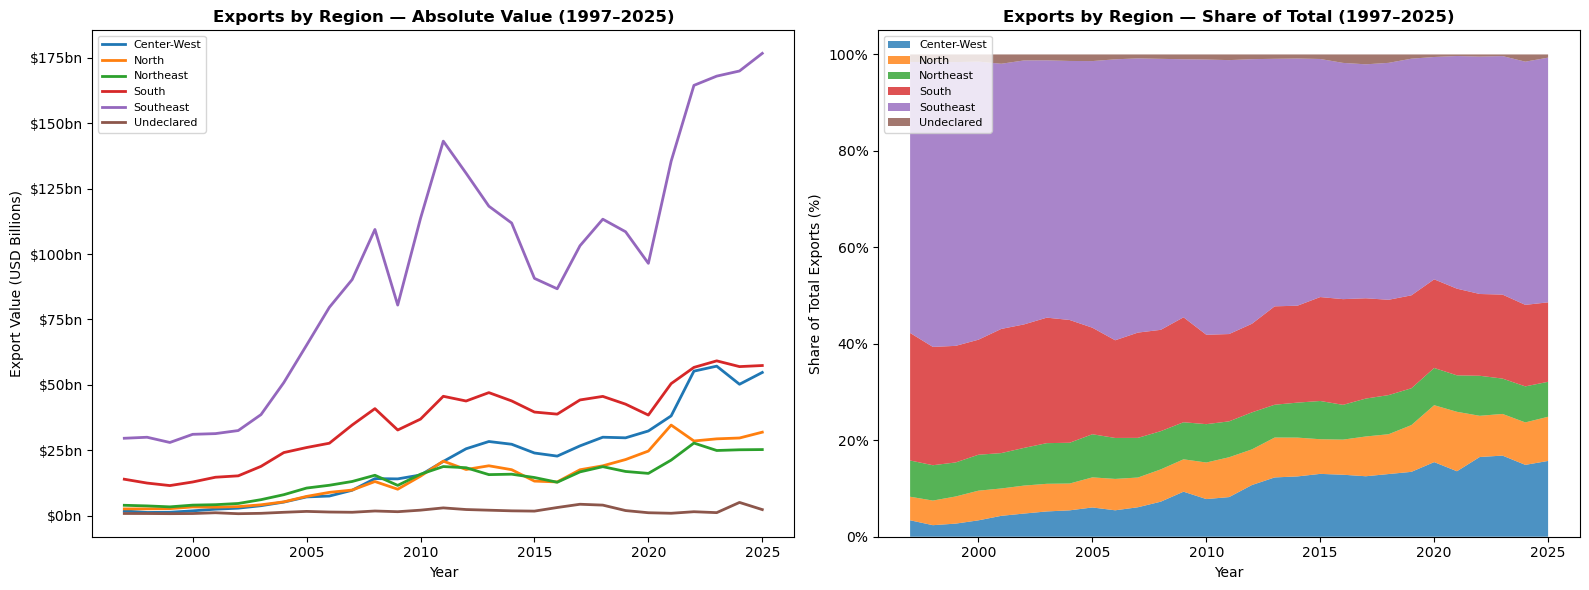


Regional export share — 1997 vs 2025
     Region  1997 (%)  1997 (USD bn)  2025 (%)  2025 (USD bn)  Change (pp)
  Southeast      56.2          29.58      50.7         176.71         -5.5
      South      26.4          13.92      16.5          57.38        -10.0
Center-West       3.4           1.79      15.7          54.73         12.3
      North       4.9           2.57       9.2          31.90          4.3
  Northeast       7.5           3.96       7.3          25.25         -0.3
 Undeclared       1.6           0.82       0.7           2.31         -0.9


In [13]:
query_region = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_regiao
    ORDER BY e."CO_ANO"
"""

# Mapping dictionary (Portuguese -> English)
region_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}

# Regions/categories to exclude
exclude_regions = [
    'Não Declarada',
    'Exterior',
    'CONSUMO DE BORDO',
    'MERCADORIA NACIONALIZADA',
    'REEXPORTACAO',
    'Zona Não Declarada'
]

df_region = pd.read_sql(query_region, engine)

# Remove unwanted categories BEFORE mapping/pivot
df_region = df_region[~df_region['region'].isin(exclude_regions)]

# Apply mapping
df_region['region'] = df_region['region'].map(region_map).fillna(df_region['region'])

df_region['exports_usd_bn'] = df_region['exports_usd'] / 1e9
df_region_pivot = df_region.pivot(index='year', columns='region', values='exports_usd_bn').fillna(0)
df_region_pct   = df_region_pivot.div(df_region_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for region in df_region_pivot.columns:
    ax1.plot(df_region_pivot.index, df_region_pivot[region], label=region, linewidth=2)

ax1.set_title(f"Exports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Export Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(
    df_region_pct.index,
    df_region_pct.T,
    labels=df_region_pct.columns,
    alpha=0.8
)

ax2.set_title(f"Exports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Exports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_5_region_exports.png', dpi=150)
plt.show()

start_year = df_region_pct.index[0]

usd_start = df_region_pivot.loc[start_year].round(2)
usd_end   = df_region_pivot.loc[MAX_YEAR].round(2)

summary_region = pd.DataFrame({
    'Region'                 : df_region_pct.columns,
    f'{start_year} (%)'      : df_region_pct.loc[start_year].round(1).values,
    f'{start_year} (USD bn)' : usd_start.values,
    f'{MAX_YEAR} (%)'        : df_region_pct.loc[MAX_YEAR].round(1).values,
    f'{MAX_YEAR} (USD bn)'   : usd_end.values,
    'Change (pp)'            : (df_region_pct.loc[MAX_YEAR] - df_region_pct.loc[start_year]).round(1).values
})

print(f"\nRegional export share — {start_year} vs {MAX_YEAR}")
print(summary_region.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

#### Overview

In 1997, two regions accounted for 82.6% of Brazil's total exports: Southeast (\\$29.58bn, 56.2%) and South (\\$13.92bn, 26.4%). By 2025, that combined share had fallen to 67.2% (\\$234.09bn) — not because either region contracted in absolute terms, but because Center-West and North grew faster.

| Region      | 1997 (%) | 1997 (USD bn) | 2025 (%) | 2025 (USD bn) | Change (pp) |
|-------------|----------|---------------|----------|---------------|-------------|
| Southeast   | 56.2%    | \\$29.58bn      | 50.7%    | \\$176.71bn     | -5.5        |
| South       | 26.4%    | \\$13.92bn      | 16.5%    | \\$57.38bn      | -10.0       |
| Center-West | 3.4%     | \\$1.79bn       | 15.7%    | \\$54.73bn      | +12.3       |
| North       | 4.9%     | \\$2.57bn       | 9.2%     | \\$31.90bn      | +4.3        |
| Northeast   | 7.5%     | \\$3.96bn       | 7.3%     | \\$25.25bn      | -0.3        |

**Center-West (+12.3pp)** recorded the largest shift in the dataset — from \\$1.79bn (3.4%) to \\$54.73bn (15.7%) over 28 years. As established in Section 2.12, this expansion is driven by primary commodity exports with minimal processing before export. Product-level composition is confirmed in Step 5.

**South (-10.0pp)** recorded the largest decline — from \\$13.92bn (26.4%) to $57.38bn (16.5%). This is not a contraction in absolute export value but a relative one, as Center-West growth outpaced South's over the period.

**Southeast (-5.5pp)** remained the dominant export region at \\$176.71bn (50.7%) in 2025. The drivers of both its sustained dominance and its share decline are examined at product level in Step 5.

**North (+4.3pp)** grew from \\$2.57bn (4.9%) to \\$31.90bn (9.2%), consistent with the surplus expansion identified in Section 2.1.3. Product-level confirmation is deferred to Step 5.

**Northeast (-0.3pp)** was the most stable region — \\$3.96bn (7.5%) in 1997 to \\$25.25bn (7.3%) in 2025.

The structural implication is a geographic rebalancing of Brazilian export capacity toward the commodity interior. By 2025, Center-West and North combined account for 24.9% (\\$86.63bn) of national exports, up from 8.3% (\\$4.36bn) in 1997.

#### Non-Geographic Categories

Undeclared declined from 1.6% (\\$0.82bn) to 0.7% (\\$2.31bn), suggesting gradual improvement in state-level trade recording.

> ⚠️ *The South's -10.0pp share loss does not indicate an absolute export decline but reflects that Brazil's export growth over 28 years was disproportionately driven by bulk agricultural commodity expansion in the Center-West rather than the diversified manufacturing and agribusiness base of the South. The value-added and competitiveness implications of this structural shift are examined in Steps 4 and 5 (trade balance and product-level analysis).*
---
---

### 2.3.2 — Regional Import Distribution: Where Brazil's Five Macro-Regions Source From
Mirroring the export analysis — how import value and share are distributed across Brazil's five macro-regions, and how that distribution has shifted over 30 years.How are exports distributed across Brazil's five macro-regions? How has this shifted from 1997 to 2025?

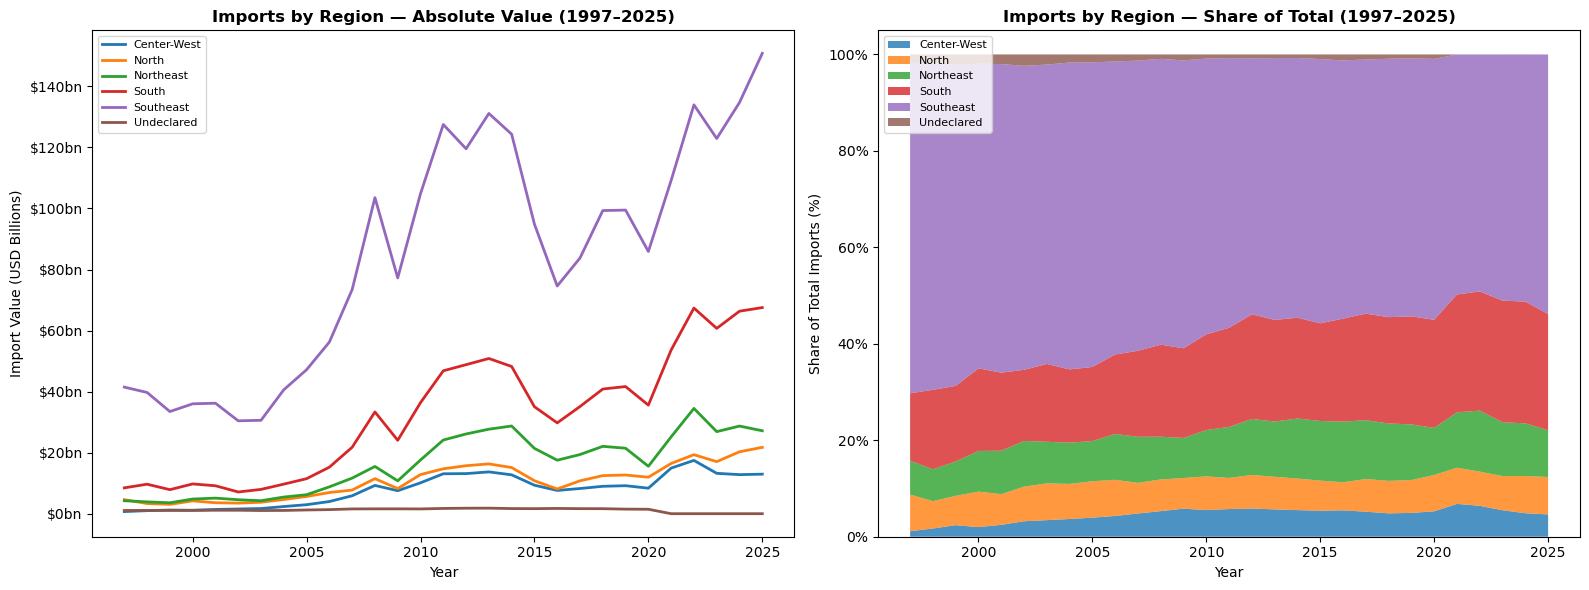


Regional import share — 1997 vs 2025
     Region  1997 (%)  1997 (USD bn)  2025 (%)  2025 (USD bn)  Change (pp)
  Southeast      68.5          41.47      53.8         150.82        -14.7
      South      14.0           8.47      24.1          67.53         10.1
  Northeast       7.0           4.25       9.7          27.17          2.7
      North       7.6           4.60       7.8          21.74          0.2
Center-West       1.1           0.69       4.6          12.96          3.5
 Undeclared       1.7           1.05       0.0           0.00         -1.7


In [7]:
query_region_imp = f"""
    SELECT i."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", u.nome_regiao
    ORDER BY i."CO_ANO"
"""

# Mapping dictionary (Portuguese -> English)
region_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}

# Regions/categories to exclude
exclude_regions = [
    'Não Declarada',
    'Exterior',
    'Consumo de Bordo',
    'Mercadoria Nacionalizada',
    'Reexportação',
    'Zona Não Declarada'
]

df_region_imp = pd.read_sql(query_region_imp, engine)

# Remove unwanted categories BEFORE mapping/pivot
df_region_imp = df_region_imp[~df_region_imp['region'].isin(exclude_regions)]

# Apply mapping
df_region_imp['region'] = df_region_imp['region'].map(region_map).fillna(df_region_imp['region'])

df_region_imp['imports_usd_bn'] = df_region_imp['imports_usd'] / 1e9
df_region_imp_pivot = df_region_imp.pivot(index='year', columns='region', values='imports_usd_bn').fillna(0)
df_region_imp_pct   = df_region_imp_pivot.div(df_region_imp_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for region in df_region_imp_pivot.columns:
    ax1.plot(df_region_imp_pivot.index, df_region_imp_pivot[region], label=region, linewidth=2)

ax1.set_title(f"Imports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Import Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(
    df_region_imp_pct.index,
    df_region_imp_pct.T,
    labels=df_region_imp_pct.columns,
    alpha=0.8
)

ax2.set_title(f"Imports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Imports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_5b_region_imports.png', dpi=150)
plt.show()

start_year = df_region_imp_pct.index[0]
# Get absolute USD values for start and max year (already in billions)
usd_start = df_region_imp_pivot.loc[start_year].round(2)
usd_end   = df_region_imp_pivot.loc[MAX_YEAR].round(2)

summary_region_imp = pd.DataFrame({
    'Region'                      : df_region_imp_pct.columns,
    f'{start_year} (%)'           : df_region_imp_pct.loc[start_year].round(1).values,
    f'{start_year} (USD bn)'      : usd_start.values,
    f'{MAX_YEAR} (%)'             : df_region_imp_pct.loc[MAX_YEAR].round(1).values,
    f'{MAX_YEAR} (USD bn)'        : usd_end.values,
    'Change (pp)'                 : (df_region_imp_pct.loc[MAX_YEAR] - df_region_imp_pct.loc[start_year]).round(1).values
})

print(f"\nRegional import share — {start_year} vs {MAX_YEAR}")
print(summary_region_imp.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

#### Overview

In 1997, the Southeast accounted for 68.5% (\\$41.47bn) of Brazil's total imports. By 2025, that share had fallen to 53.8% (\\$150.82bn) — not because Southeast imports contracted in absolute terms, but because the South grew substantially faster. The result is a geographic rebalancing of Brazilian import demand toward the southern coast.

| Region      | 1997 (%) | 1997 (USD bn) | 2025 (%) | 2025 (USD bn) | Change (pp) |
|-------------|----------|---------------|----------|---------------|-------------|
| Southeast   | 68.5%    | \\$41.47bn      | 53.8%    | \\$150.82bn     | -14.7       |
| South       | 14.0%    | \\$8.47bn       | 24.1%    | \\$67.53bn      | +10.1       |
| Northeast   | 7.0%     | \\$4.25bn       | 9.7%     | \\$27.17bn      | +2.7        |
| North       | 7.6%     | \\$4.60bn       | 7.8%     | \\$21.74bn      | +0.2        |
| Center-West | 1.1%     | \\$0.69bn       | 4.6%     | \\$12.96bn      | +3.5        |

**South (+10.1pp)** recorded the largest shift on the import side — from \\$8.47bn (14.0%) to \\$67.53bn (24.1%), an approximately 8x increase compared to approximately 3.75x for the national total. Santa Catarina's \\$33.99bn import figure is the primary driver, consistent with the anomalous deficit identified in Sections 2.1 and 2.3. The absolute value chart confirms the timing: the South line is flat from 1997 to approximately 2015, then accelerates sharply and persistently. Product-level breakdown is deferred to Step 5.

**Southeast (-14.7pp)** remains the largest import region at \\$150.82bn (53.8%), but its share loss is the largest regional shift on the import side — nearly three times the magnitude of its export share loss (-5.1pp). Southeast imports grew from \\$41.47bn to $150.82bn in absolute terms, but growth slowed noticeably post-2015 as the South accelerated.

**Northeast (+2.7pp)** grew from \\$4.25bn to \\$27.17bn. **Center-West (+3.5pp)** grew from \\$0.69bn to \\$12.96bn. Product-level composition for both regions is unconfirmed and deferred to Step 5.

**North (+0.2pp)** held its import share virtually flat — \\$4.60bn (7.6%) to \\$21.74bn (7.8%) — despite its export share growing from 4.9% to 9.2% over the same period. This confirms that North's export growth is surplus-generating rather than import-dependent. Amazonas (\\$16.06bn imports) accounts for a substantial portion of the North total.

#### Export and Import Share Shifts Compared

| Region      | Export share Δ | Import share Δ |
|-------------|----------------|----------------|
| Southeast   | -5.1pp         | -14.7pp        |
| South       | -9.8pp         | +10.1pp        |
| Center-West | +12.3pp        | +3.5pp         |
| North       | +4.3pp         | +0.2pp         |
| Northeast   | -0.2pp         | +2.7pp         |

The South is the only region where export share declined while import share rose. The North and Center-West present the inverse: export share gains outpacing import share growth. The Southeast lost share on both sides.

> ⚠️ *The South's import surge from \\$8.47bn (14.0%) to \\$67.53bn (24.1%) is the most unresolved finding in this section. Santa Catarina's \\$33.99bn import figure is the primary driver, but the product-level composition of what is being imported requires Step 5 investigation before any structural conclusion can be drawn.*

> ⚠️ *Undeclared declining from 1.7% to effectively 0% on the import side — compared to 1.6% to 0.7% on the export side — suggests import origin recording improved more dramatically than export origin recording over the period.*
---
---

## 2.4 — Export Sector Structure: What Brazil's States and Regions Actually Sell

### 2.4.1 — Top 10 Export Sectors by State (SH2): Ranked Table with Share of State Total
For every state, the top 10 export sectors by SH2 classification ranked by value — each showing its share of that state's total exports.

In [8]:
top10_states_uf = df_state.head(10)['uf'].tolist()
top10_states_uf_str = ','.join([f"'{s}'" for s in top10_states_uf])

query_exp_sectors = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2_ing,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_exp_sectors = pd.read_sql(query_exp_sectors, engine)
df_exp_sectors['exports_usd_bn'] = (df_exp_sectors['exports_usd'] / 1e9).round(2)

df_top10_sectors = (
    df_exp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 export sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_sectors['state'].unique():
    subset = df_top10_sectors[df_top10_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2_ing'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 export sectors per state — SH2 classification (2025)

Acre — Total exports: $0.1bn
  SH2 Meat and edible meat offal                         $0.05bn (47.5%)
  SH12 Oil seeds and oleaginous fruits; Grains, Seeds, ot $0.02bn (20.4%)
  SH8 Edible fruit and nuts; peel of citrus fruits or me $0.01bn (12.4%)
  SH1 Live animals                                       $0.01bn (5.1%)
  SH44 Wood and articles of wood; wood charcoal           $0.01bn (5.1%)
  SH5 Products of animal origin, not specified or includ $0.00bn (4.8%)
  SH72 Iron and steel                                     $0.00bn (1.2%)
  SH10 Cereals                                            $0.00bn (0.7%)
  SH23 Residues and waste from the food industries; other $0.00bn (0.4%)
  SH76 Aluminium and articles thereof                     $0.00bn (0.2%)

Alagoas — Total exports: $0.8bn
  SH17 Sugars and sugar confectionery                     $0.57bn (69.9%)
  SH26 Ores, slag and ash                                 $0.23bn (27.5%)


C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\2577196992.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


#### Overview

Brazil's 27 states exported a combined \\$348.8bn in 2025. Export activity is highly concentrated: São Paulo (\\$71.4bn), Rio de Janeiro (\\$49.0bn), and Minas Gerais (\\$45.8bn) alone account for 47.9% of national exports. At the other end, six states — Acre, Amapá, Paraíba, Roraima, Sergipe, and Distrito Federal — each exported under \\$0.5bn, collectively representing under 0.4% of the national total.

The state-level product data reveals four structurally distinct export profiles across Brazil's states.

---

#### Export Profile 1 — Soybean-Led Agricultural Commodity States

The most prevalent profile in the dataset. States in this group are defined by SH12 (oil seeds, principally soybeans) as the dominant export sector, typically complemented by SH2 (meat), SH10 (cereals), and SH23 (soy residues and animal feed).

| State | Total Exports | SH12 Share |
|---|---|---|
| Mato Grosso | \\$30.2bn | 43.6% |
| Piauí | \\$1.2bn | 82.8% |
| Goiás | \\$13.5bn | 38.7% |
| Mato Grosso do Sul | \\$10.8bn | 23.0% |
| Rondônia | \\$3.1bn | 32.7% |
| Tocantins | \\$3.0bn | 53.3% |
| Roraima | \\$0.2bn | 41.1% |

Mato Grosso is the archetype: \\$30.2bn in total exports with SH12 (\\$13.17bn), SH10 (\\$4.67bn), SH2 (\\$4.47bn), SH52 (\\$3.13bn), and SH23 (\\$2.95bn) accounting for 94.1% of state exports across five commodity sectors. Piauí is the most concentrated in the dataset — SH12 alone at 82.8% (\\$0.99bn) with no other sector above 3.6%.

This profile corresponds directly to the structural reversal documented in Section 2.12: the expansion of primary commodity exports from 27.7% to 58.2% of national exports between 1997 and 2025 is driven disproportionately by this group.

---

#### Export Profile 2 — Mineral Extraction States

Defined by SH26 (ores, slag and ash) as the primary or co-primary sector. These states sit on Brazil's principal mineral belts.

| State | Total Exports | Primary Mineral Sector | Share |
|---|---|---|---|
| Pará | \\$24.3bn | SH26 Ores | 64.6% |
| Minas Gerais | \\$45.8bn | SH26 Ores | 27.0% |
| Espírito Santo | \\$10.5bn | SH26 Ores | 28.2% |

Pará is the most concentrated mineral exporter — SH26 at \\$15.73bn (64.6%) with SH28 inorganic chemicals at \\$2.30bn (9.4%) as the secondary sector. Minas Gerais presents a more diversified mineral profile: SH26 (\\$12.37bn, 27.0%) combined with SH9 coffee (\\$11.29bn, 24.6%) and SH72 iron and steel (\\$4.67bn, 10.2%), making it the only state in this group with meaningful non-mineral export diversification. Espírito Santo's profile combines SH26 with SH9 coffee, SH72 iron and steel, and SH47 pulp.

---

#### Export Profile 3 — Petroleum-Dominant States

Defined by SH27 (mineral fuels and oils) as the dominant sector. This profile is limited to two states and one non-geographic category.

| State | Total Exports | SH27 Share |
|---|---|---|
| Rio de Janeiro | \\$49.0bn | 83.3% |
| Rio Grande do Norte | \\$1.1bn | 52.7% |
| Sergipe | \\$0.5bn | 61.9% |

Rio de Janeiro is the most concentrated single-sector state in the dataset — SH27 at \\$40.79bn (83.3%) with no other sector above 4.3%. This concentration is the primary reason Rio de Janeiro was identified as the structural outlier in the regression analysis (Section 2b.5): its export frequency profile is distorted by bulk petroleum shipment volumes that are structurally incomparable to other states.

---

#### Export Profile 4 — Industrialised and Diversified States

Defined by the presence of manufactured goods — vehicles (SH87), machinery (SH84), electrical equipment (SH85), aircraft (SH88) — among the top export sectors, with no single commodity sector above 50%.

| State | Total Exports | Distinguishing Sectors |
|---|---|---|
| São Paulo | \\$71.4bn | SH17 sugar, SH87 vehicles, SH84 machinery, SH88 aircraft |
| Paraná | \\$23.6bn | SH87 vehicles, SH84 machinery alongside SH12, SH2 |
| Rio Grande do Sul | \\$21.5bn | SH24 tobacco, SH87 vehicles, SH84 machinery alongside SH12, SH2 |
| Santa Catarina | \\$12.2bn | SH2 meat, SH84 machinery, SH85 electrical equipment |
| Amazonas | \\$0.9bn | SH87 vehicles, SH85 electrical equipment, SH84 machinery |
| Pernambuco | \\$2.5bn | SH87 vehicles (39.7%) |
| Ceará | \\$2.3bn | SH72 iron and steel (51.8%) |

São Paulo is the only state in the dataset that combines commodity scale (SH17 sugar at \\$8.47bn) with a diversified industrial base across vehicles, machinery, aircraft, and electrical equipment. Paraná and Rio Grande do Sul are hybrid states — commodity export volumes comparable to Center-West states combined with meaningful manufactured goods sectors. Santa Catarina's profile is notable: SH2 meat at 34.1% followed by machinery and electrical equipment, consistent with the industrial-agribusiness mix of its economy.

Amazonas is structurally anomalous within the North region — SH87 vehicles (\\$0.14bn) and SH85 electrical equipment (\\$0.06bn) in a region otherwise defined by commodities, a legacy of the Zona Franca de Manaus industrial policy. This is consistent with the value density outlier identified in Section 2b.6.

---

#### Cross-Cutting Observations

**SH12 is the single most widely distributed sector in the dataset.** It appears in the top 10 export sectors of 23 of 27 states. No other sector approaches this geographic penetration. SH2 (meat) appears in 20 states. Together, SH12 and SH2 are present as top-10 sectors in the majority of Brazilian states regardless of region or economic profile — reflecting the scale of Brazil's agribusiness footprint even in states where manufacturing or minerals dominate.

**SH72 (iron and steel) appears in 18 states** across all four profiles, including industrialised states (São Paulo, Paraná), commodity states (Goiás, Mato Grosso), and mineral states (Minas Gerais, Pará). Its presence reflects both domestic steel production capacity and the downstream processing of mineral extraction — it is not confined to a single export profile.

**Single-sector concentration above 50% is a risk indicator present in eight states:** Rio de Janeiro (83.3% SH27), Piauí (82.8% SH12), Pará (64.6% SH26), Sergipe (61.9% SH27), Rio Grande do Norte (52.7% SH27), Tocantins (53.3% SH12), Ceará (51.8% SH72), and Rondônia (50.3% SH2). For these states, export revenue is materially exposed to price cycles in a single global commodity market.

**The industrial base is geographically narrow.** Manufactured goods in meaningful volumes — vehicles, machinery, aircraft, electrical equipment — are concentrated in São Paulo, Paraná, Rio Grande do Sul, Santa Catarina, and Amazonas. Outside these five states, manufactured exports either do not appear in the top 10 or appear at marginal values. Brazil's export diversification challenge, documented at national level in Section 2.12, is a state-level concentration problem rather than a uniform national characteristic.

> ⚠️ *Ceará's top sector is SH72 iron and steel at 51.8% (\\$1.18bn). Given Ceará's 55.6% YoY export growth identified in Section 2.13, this concentration warrants NCM-level investigation to confirm whether this reflects CSP steel plant ramp-up volumes. Deferred to Step 5.*

> ⚠️ *Bahia's SH71 (natural or cultured pearls, precious or semi-precious stones) at \\$1.10bn (9.5%) was resolved as gold bullion in Section 2.7. The same SH71 entries appear in Goiás (\\$0.36bn), Maranhão (\\$0.25bn), Tocantins ($0.20bn), and Amazonas (\\$0.17bn) — NCM-level confirmation of composition is deferred to Step 5.*
---
---

### 2.4.2 — Brazil Annual Export Composition by Sector (1997–2025)
Annual stacked bar chart showing Brazil's total export value by SH2 sector from 1997 to 2025, revealing how the export product mix has shifted over time.

*Sectors below 0.1% share of total exports are excluded from the summary table. All sectors areincluded in the stacked bar chart.*

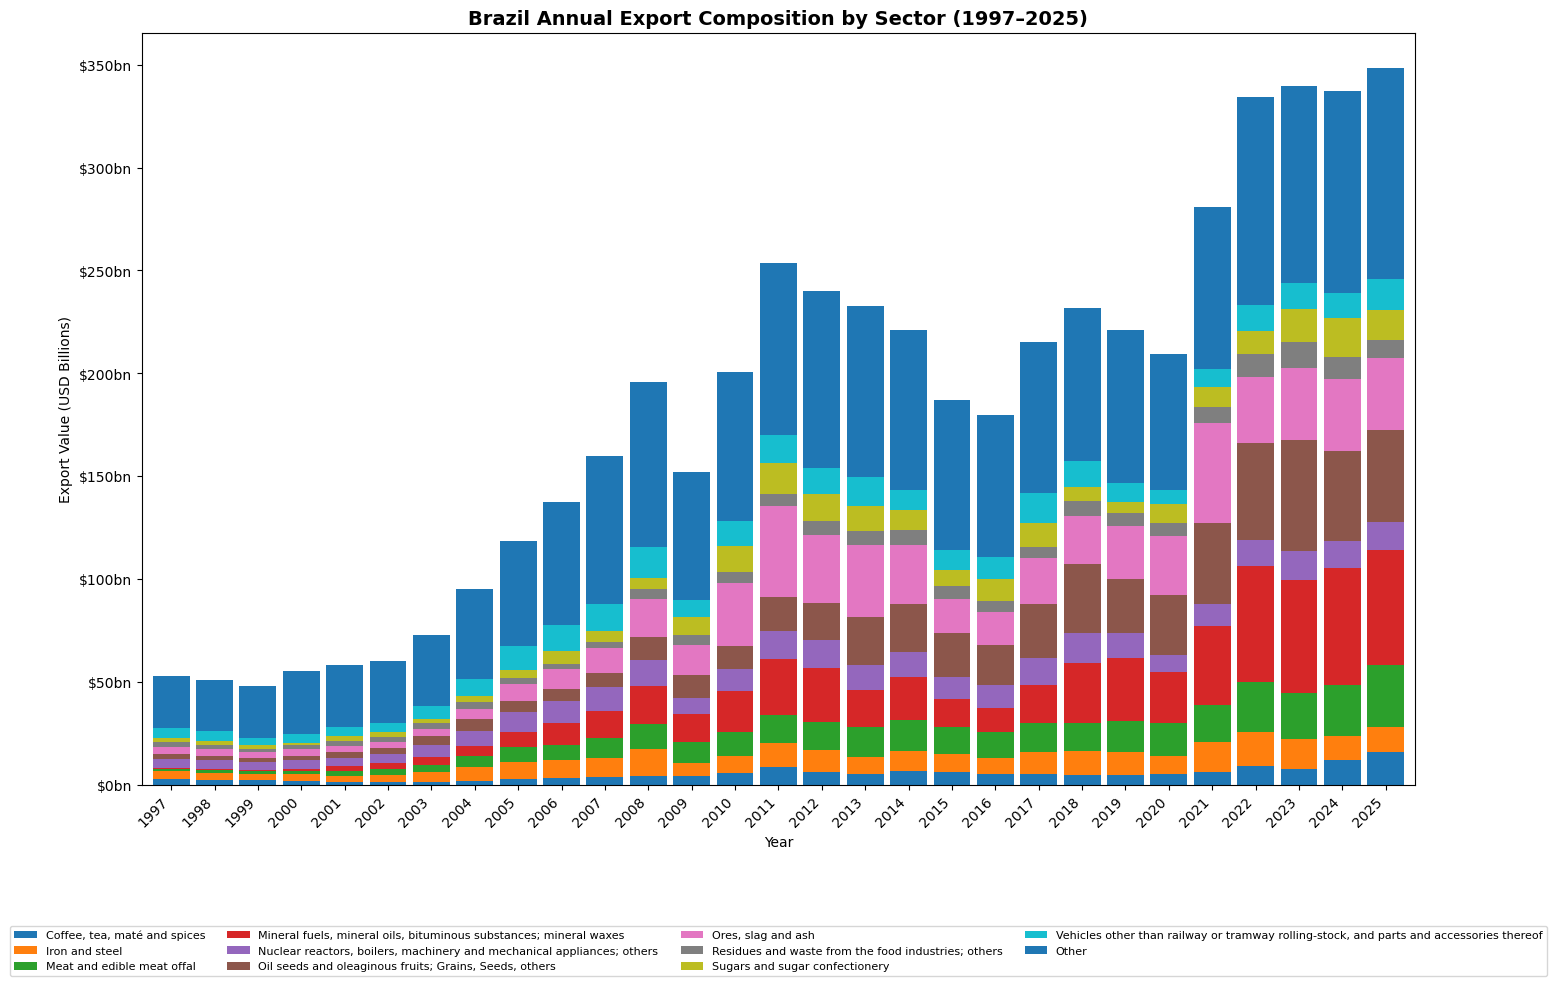


Brazil export composition by sector (2025) — Total: $348.3bn



Sector,Exports (USD bn),Share (%)
"Mineral fuels, mineral oils, bituminous substances; min",$55.96bn,16.1%
"Oil seeds and oleaginous fruits; Grains, Seeds, others",$44.67bn,12.8%
"Ores, slag and ash",$34.89bn,10.0%
Meat and edible meat offal,$29.98bn,8.6%
"Coffee, tea, maté and spices",$15.65bn,4.5%
"Vehicles other than railway or tramway rolling-stock, a",$15.08bn,4.3%
Sugars and sugar confectionery,$14.34bn,4.1%
"Nuclear reactors, boilers, machinery and mechanical app",$13.89bn,4.0%
Iron and steel,$12.35bn,3.5%
"Pulp of wood or of other fibrous cellulosic material, o",$10.17bn,2.9%


In [15]:
## Brazil annual export composition by SH2 sector (1997–MAX_YEAR)
query_brazil_exp_annual = f"""
    SELECT e."CO_ANO" AS year,
           s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", s.descricao_sh2_ing
    ORDER BY e."CO_ANO", exports_usd DESC
"""
df_brazil_exp_annual = pd.read_sql(query_brazil_exp_annual, engine)
df_brazil_exp_annual['exports_usd_bn'] = df_brazil_exp_annual['exports_usd'] / 1e9

## Identify top 10 sectors by total exports across all years — group rest as Other
top10_exp_sectors = (
    df_brazil_exp_annual.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)
df_brazil_exp_annual['sector_group'] = df_brazil_exp_annual['sector'].apply(
    lambda x: x if x in top10_exp_sectors else 'Other'
)
df_brazil_exp_grouped = (
    df_brazil_exp_annual.groupby(['year', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_brazil_exp_pivot = df_brazil_exp_grouped.pivot(
    index='year', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_exp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_exp_pivot = df_brazil_exp_pivot[cols_ordered]

## ---- Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
df_brazil_exp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Export Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=8,
    frameon=True
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_6b_brazil_exp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## ---- Summary table (MAX_YEAR only, filtered to >= 0.1%) ─────────────────────
df_exp_annual_display = (
    df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]
    .groupby('sector')['exports_usd_bn'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .assign(share=lambda x: (x['exports_usd_bn'] / x['exports_usd_bn'].sum() * 100).round(1))
)

## Filter out sectors below 0.1% share
df_exp_annual_display = df_exp_annual_display[df_exp_annual_display['share'] >= 0.1]

df_exp_annual_display = (
    df_exp_annual_display
    .rename(columns={
        'sector'        : 'Sector',
        'exports_usd_bn': 'Exports (USD bn)',
        'share'         : 'Share (%)'
    })
    .reset_index(drop=True)
)
df_exp_annual_display['Sector']           = df_exp_annual_display['Sector'].str[:55]
df_exp_annual_display['Exports (USD bn)'] = df_exp_annual_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_exp_annual_display['Share (%)']        = df_exp_annual_display['Share (%)'].apply(lambda x: f'{x:.1f}%')

total = df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]['exports_usd_bn'].sum()
print(f"\nBrazil export composition by sector ({MAX_YEAR}) — Total: ${total:.1f}bn\n")
display(df_exp_annual_display.style
    .set_caption(f"Brazil export composition by sector ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

#### Overview

Brazil's total exports reached \\$348.3bn in 2025, up from approximately \\$53bn in 1997 — a 6.6x increase over 28 years. The chart reveals three structurally distinct periods: a gradual expansion from 1997 to 2011 (peak at approximately \\$256bn), a contraction and stagnation from 2011 to 2016, and a recovery phase from 2016 onward that reached a new peak in 2025. The sector composition shifted materially across the period.

#### 2025 Sector Composition

The top 10 sectors account for 70.8% of total exports (\\$246.7bn). The top 4 sectors are all primary or minimally processed commodities and account for \\$165.50bn (47.5%) combined.

| Sector | 2025 (\\$bn) | Share (%) |
|---|---|---|
| Mineral fuels and oils (SH27) | \\$55.96bn | 16.1% |
| Oil seeds and oleaginous fruits (SH12) | \\$44.67bn | 12.8% |
| Ores, slag and ash (SH26) | \\$34.89bn | 10.0% |
| Meat and edible meat offal (SH2) | \\$29.98bn | 8.6% |
| Coffee, tea, maté and spices (SH9) | \\$15.65bn | 4.5% |
| Vehicles (SH87) | \\$15.08bn | 4.3% |
| Sugars and sugar confectionery (SH17) | \\$14.34bn | 4.1% |
| Machinery (SH84) | \\$13.89bn | 4.0% |
| Iron and steel (SH72) | \\$12.35bn | 3.5% |
| Pulp of wood (SH47) | \\$10.17bn | 2.9% |

The first manufactured goods sector, vehicles (SH87), appears sixth at 4.3% — below four primary commodity sectors and coffee.

Below the top 10, 52 additional sectors contribute the remaining 29.2% (\\$101.6bn). No individual sector in this long tail exceeds 2.7% (cereals, \\$9.56bn). The data table confirms 94 active SH2 export chapters in 2025 — Brazil exports something from nearly every product category, but the top 10 account for 70.8% of total value and the bottom 50+ chapters collectively account for less than 5%.

##### Structural Transformation 1 — The Commodity Surge (2003–2011)

From approximately \\$50bn (1997–2002) to \\$256bn (2011) — a 5x increase in 9 years. The chart shows the bar growing dramatically taller while the relative proportions of the underlying sectors remain broadly similar. Oil seeds (SH12), ores (SH26), meat (SH2) and coffee (SH9) all expanded in absolute value simultaneously across this period.

##### Structural Transformation 2 — The Oil Emergence (Post-2015)

The SH27 (mineral fuels) segment remains relatively limited through 2014, before increasing significantly from 2016 onward. By the 2020–2025 period, it becomes the largest individual export segment. In 2025, SH27 reaches approximately \\$55.96 billion (16.1% of total exports), a position it does not appear to hold prior to around 2018.

This shift coincides with the [expansion of production in Brazil’s pre-salt oil fields](https://worldoil.com/magazine/2021/february-2021/features/regional-report-brazil/), suggesting a structural change in the composition of exports over the period.

##### Structural Transformation 3 — The Soybean Acceleration (Post-2020)

The SH12 (soybeans) segment shows a marked increase beginning in 2020, with the highest absolute export values observed between 2022 and 2025.

This expansion occurs alongside several external and domestic factors, including the [disruption of global agricultural supply chains following the Russia–Ukraine conflict (from 2022 onward)](https://www.oecd.org/content/dam/oecd/en/publications/reports/2022/06/oecd-fao-agricultural-outlook-2022-2031_e00c413c/f1b0b29c-en.pdf), [continued agricultural frontier expansion in the MATOPIBA region](https://www.embrapa.br/en/tema-matopiba), and sustained demand from China. These factors, discussed in Step 1 and Section 2.7, align temporally with the observed increase in soybean exports.

---

#### The Industrial Sectors

The industrial segments — vehicles (SH87), machinery (SH84), electrical equipment (SH85, \\$5.10bn, 1.5%), and aerospace (SH88, \\$4.89bn, 1.4%) — maintained broadly stable absolute values across the full period while the commodity base expanded beneath them.

Combined vehicles and machinery accounted for approximately 15–18% of exports in the late 1990s and early 2000s against 8.3% in 2025. The absolute values of these sectors grew modestly but their share declined as commodity sectors expanded at a faster rate.

> ⚠️ *The 15–18% vehicles and machinery share for 1997–2002 is estimated from the chart and has not been confirmed from the underlying data. A query isolating SH87 and SH84 share by year is needed to confirm this figure precisely.*

---

#### Contractions and Shocks

**2009** — All sectors contracted proportionally. The sector composition within the bar is effectively unchanged — the contraction compressed the entire export base without altering its structure.

**2014–2016** — The ores and iron and steel segments visibly shrank while the oil seeds and mineral fuels segments held more stable. This is consistent with the state-level finding in Section 2.1.3 that Pará and Minas Gerais — mineral extraction states — were more affected during this period than Centro-Oeste agricultural states.

**2020 (COVID-19)** — The 2020 bar shows minimal contraction relative to 2019 and the sector composition is effectively unchanged. This is consistent with the findings in Steps 1 and 2 that Brazil's goods trade was not materially disrupted at the aggregate level during the pandemic year.

---

#### The Post-2020 Surge

The bars for 2021–2025 are the tallest in the dataset. Three concurrent factors are visible in the chart:

1. The SH27 mineral fuels segment grows year-on-year from 2020 onward
2. The SH12 oil seeds segment reaches its largest absolute values in 2022–2023
3. The SH26 ores segment recovered from its 2015–2016 contraction

The 2022 bar shows the SH27, SH12 and SH26 segments all at or near peak values simultaneously. Whether this convergence reflects price effects, volume effects, or currency effects requires the volume vs. value decomposition in Section 2.15 and is not resolvable from the composition chart alone.

---

#### Structural Conclusion

Brazil's export composition became more commodity-concentrated between 1997 and 2025. The top 4 primary commodity sectors increased their combined share from an estimated 35–40% in 1997 to 47.5% in 2025, while vehicles and machinery declined from an estimated 15–18% to 8.3% over the same period.

> ⚠️ *The 1997 share estimates for primary commodities and industrial sectors are derived from visual inspection of the stacked bar chart and require query-level confirmation before they can be stated as precise figures in any published output.*

> ⚠️ *SH71 (natural or cultured pearls, precious or semi-precious stones) appears at \\$7.19bn (2.1%) — the 13th largest export sector nationally. As flagged in Section 2.4.1, the NCM-level composition of this category requires Step 5 investigation before the figure can be interpreted structurally.*

---
---

## 2.5 — Import Sector Structure: What Brazil's States and Regions Actually Buy

### 2.5.1 — Top 10 Import Sectors by State (SH2): Ranked Table with Share of State Total
For every state, the top 10 import sectors by SH2 classification ranked by value — each showing its share of that state total imports.

In [10]:
top10_imp_states_uf = df_state.nlargest(10, 'imports_usd_bn')['uf'].tolist()
top10_imp_states_uf_str = ','.join([f"'{s}'" for s in top10_imp_states_uf])

query_imp_sectors = f"""
    SELECT i."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2_ing,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY i."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2_ing
    ORDER BY i."SG_UF_NCM", imports_usd DESC
"""

df_imp_sectors = pd.read_sql(query_imp_sectors, engine)
df_imp_sectors['imports_usd_bn'] = (df_imp_sectors['imports_usd'] / 1e9).round(2)

df_top10_imp_sectors = (
    df_imp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'imports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 import sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_imp_sectors['state'].unique():
    subset = df_top10_imp_sectors[df_top10_imp_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['imports_usd_bn'].iloc[0]
    print(f"\n{state} — Total imports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['imports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2_ing'])[:50]:<50} ${row['imports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 import sectors per state — SH2 classification (2025)

Acre — Total imports: $0.0bn
  SH88 Aircraft, spacecraft, and parts thereof            $0.00bn (19.3%)
  SH84 Nuclear reactors, boilers, machinery and mechanica $0.00bn (9.4%)
  SH93 Arms and ammunition; parts and accessories thereof $0.00bn (7.9%)
  SH85 Electrical machinery and equipment and parts there $0.00bn (5.4%)
  SH90 Optical, photographic, cinematographic instruments $0.00bn (3.9%)
  SH40 Rubber and articles thereof                        $0.00bn (1.7%)
  SH32 Tanning or dyeing extracts; tannins and their deri $0.00bn (1.0%)
  SH28 Inorganic chemicals; organic or inorganic compound $0.00bn (0.6%)
  SH7 Edible vegetables and certain roots and tubers     $0.00bn (0.5%)
  SH44 Wood and articles of wood; wood charcoal           $0.00bn (0.5%)

Alagoas — Total imports: $1.1bn
  SH39 Plastics and articles thereof                      $0.12bn (10.4%)
  SH85 Electrical machinery and equipment and parts there $0.11bn (10.1%)

C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\2095680266.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'imports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\2095680266.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  share = (row['imports_usd'] / (total * 1e9) * 100)


#### Overview

Brazil's 27 states imported a combined \\$281.5bn in 2025. Import activity is even more concentrated than exports: São Paulo (\\$86.5bn), Santa Catarina (\\$34.0bn), and Rio de Janeiro (\\$32.2bn) account for 54.2% of national imports. At the other end, six states — Acre, Amapá, Roraima, Tocantins, Rio Grande do Norte, and Sergipe — each imported under \\$0.5bn, collectively representing under 0.5% of the national total.

The state-level import data reveals four structurally distinct import profiles.

---

#### Import Profile 1 — Fertiliser-Dependent Agricultural States

Defined by SH31 (fertilisers) as the dominant or co-dominant import sector. These are the same states that appear in Export Profile 1 — the agricultural commodity exporters whose surplus generation depends on imported agricultural inputs.

| State | Total Imports | SH31 Share | SH31 Value |
|---|---|---|---|
| Mato Grosso | \\$2.6bn | 61.7% | \\$1.62bn |
| Tocantins | \\$0.3bn | 51.0% | \\$0.18bn |
| Maranhão | \\$4.8bn | 25.0% | \\$1.19bn |
| Paraná | \\$20.1bn | 15.0% | \\$3.02bn |
| Rio Grande do Sul | \\$13.4bn | 19.4% | \\$2.59bn |
| Pará | \\$2.7bn | 24.4% | \\$0.67bn |
| Roraima | \\$0.1bn | 29.1% | \\$0.01bn |

Mato Grosso is the archetype: \\$1.62bn in fertiliser imports (61.7%) against \\$30.2bn in agricultural exports — a coverage ratio that confirms the export surplus is structurally dependent on imported inputs. Maranhão presents the starkest combined picture: SH27 mineral fuels at 66.0% (\\$3.14bn) combined with SH31 fertilisers at 25.0% (\\$1.19bn) account for 91.0% of total imports — a state whose entire import profile is defined by energy and agricultural production inputs.

The fertiliser dependency finding identified at national level in Section 2.12 is confirmed at state level: the agricultural surplus states are simultaneously the most fertiliser-import- dependent states in the dataset.

---

#### Import Profile 2 — Industrial Input States

Defined by SH84 (machinery) and SH85 (electrical equipment) as the dominant import sectors, reflecting manufacturing and industrial activity rather than commodity production.

| State | Total Imports | Primary Import Sectors |
|---|---|---|
| São Paulo | \\$86.5bn | SH84 \\$15.72bn (18.2%), SH85 \\$10.66bn (12.3%) |
| Santa Catarina | \\$34.0bn | SH84 \\$4.41bn (13.0%), SH85 \\$3.68bn (10.8%) |
| Minas Gerais | \\$18.3bn | SH84 \\$3.16bn (17.2%), SH85 \\$1.87bn (10.2%) |
| Paraná | \\$20.1bn | SH84 \\$3.07bn (15.2%), SH85 \\$1.50bn (7.4%) |
| Amazonas | \\$16.1bn | SH85 \\$7.06bn (44.0%), SH84 \\$2.23bn (13.9%) |

São Paulo's import profile mirrors its export diversification — machinery, electrical equipment, organic chemicals (\\$7.72bn), pharmaceuticals (\\$6.60bn), and precision instruments (\\$4.70bn) span six economic domains with no single sector above 18.2%. Amazonas is the outlier within this group: SH85 at 44.0% (\\$7.06bn) reflects the Zona Franca de Manaus electronics assembly model, where components are imported for domestic manufacturing rather than for industrial production inputs. This import profile is structurally distinct from São Paulo's diversified industrial sourcing.

Santa Catarina's import profile — SH84, SH85, SH39 plastics, SH72 iron and steel, SH74 copper — is consistent with a manufacturing and assembly economy. However, at \\$34.0bn total imports against \\$12.2bn total exports, the scale of Santa Catarina's import volume relative to its export base remains the most unresolved structural finding in the dataset. The import composition does not itself explain the deficit. Deferred to Step 5.

---

#### Import Profile 3 — Petroleum-Dominated States

Defined by SH27 (mineral fuels) as the dominant import sector. The states in this group are largely smaller economies without domestic refining capacity or with port-linked fuel distribution roles.

| State | Total Imports | SH27 Share | SH27 Value |
|---|---|---|---|
| Amapá | \\$0.3bn | 76.0% | \\$0.22bn |
| Maranhão | \\$4.8bn | 66.0% | \\$3.14bn |
| Paraíba | \\$1.0bn | 49.0% | \\$0.49bn |
| Sergipe | \\$0.4bn | 47.2% | \\$0.18bn |
| Bahia | \\$9.3bn | 43.8% | \\$4.08bn |
| Ceará | \\$2.6bn | 24.8% | \\$0.65bn |

Bahia's SH27 dominance (\\$4.08bn, 43.8%) combined with SH31 fertilisers (\\$0.98bn, 10.5%) and SH84 machinery (\\$0.67bn, 7.2%) reflects the Camaçari industrial complex's energy and chemical input requirements — the same complex that produces Bahia's diversified export profile in Section 2.4.1.

---

#### Import Profile 4 — Structurally Anomalous States

Three states present import profiles that do not fit the above categories and require specific explanation.

**Rio de Janeiro (\\$32.2bn)** — SH84 machinery dominates at 37.6% (\\$12.10bn), followed by SH27 mineral fuels (\\$6.19bn, 19.3%) and SH89 ships and floating structures (\\$2.46bn, 7.7%). This profile reflects offshore oil infrastructure: the machinery, vessels, and fuel imports are inputs to the petroleum extraction industry that generates Rio de Janeiro's \\$40.79bn in SH27 exports. Rio de Janeiro is simultaneously Brazil's largest petroleum exporter and a major importer of the capital equipment required to produce that petroleum.

**Distrito Federal (\\$2.3bn)** — SH30 pharmaceutical products at 82.5% (\\$1.86bn) is the most concentrated single-sector import profile in the dataset. This reflects the concentration of federal health procurement in Brasília rather than local industrial activity. No other sector exceeds 3.8%.

**Espírito Santo (\\$13.8bn)** — SH87 vehicles at 45.0% (\\$6.21bn) is anomalous for a state whose export profile is defined by ores, coffee and steel. Vehicle imports at this scale in a state without a major domestic vehicle market suggest a transshipment or re-export role through the ports of Vitória and Vila Velha. This hypothesis is unconfirmed. Deferred to Step 5.

---

#### Cross-Cutting Observations

**SH84 (machinery) appears in the top 10 of all 27 states.** It is the only sector with universal geographic presence on the import side — reflecting the dependence of every state economy on imported capital equipment regardless of economic profile.

**SH85 (electrical equipment) appears in the top 10 of 24 states.** Combined with SH84, these two sectors represent Brazil's broadest and most consistent import dependency — industrial capital goods sourced internationally across the entire country.

**SH31 (fertilisers) appears in the top 10 of 17 states**, concentrated in agricultural and frontier states. The national fertiliser import bill identified in Section 2.12 (\\$15.49bn) is distributed across these 17 states, with Paraná (\\$3.02bn), Rio Grande do Sul (\\$2.59bn), and Mato Grosso (\\$1.62bn) accounting for the largest volumes.

**SH27 (mineral fuels) appears in the top 10 of 22 states**, reflecting Brazil's continued dependence on imported petroleum products despite being a major crude oil exporter — a refining capacity gap that is visible at state level across every region.

**The import side is structurally more uniform than the export side.** On exports, five distinct profiles with meaningful product differentiation were identified. On imports, the majority of states draw from the same three or four sectors — machinery, electrical equipment, fuels, and fertilisers — with variation primarily in the weighting rather than the composition. This uniformity reflects Brazil's import structure being driven by industrial input requirements and energy dependency rather than by state-specific economic activity.

> ⚠️ *Espírito Santo's SH87 vehicle imports at \\$6.21bn (45.0%) cannot be explained by domestic demand alone. The transshipment hypothesis requires NCM-level and customs declaration analysis to confirm whether these vehicles are re-exported or retained domestically. Deferred to Step 5.*

> ⚠️ *Santa Catarina's \\$34.0bn import total against $12.2bn exports produces a \\$21.8bn deficit — the largest state trade deficit in the dataset. The import composition (machinery, electrical equipment, plastics, iron and steel, copper) is consistent with a manufacturing economy but does not at SH2 level explain the scale of the deficit. NCM-level analysis in Step 5 is required before any structural conclusion can be drawn.*
---
---

## 2.5.2 — Brazil Annual Import Composition by Sector (1997–2025)
Annual stacked bar chart showing Brazil's total import value by SH2 sector from 1997 to 2025, revealing how the import product mix has shifted over time.

*Sectors below 0.1% share of total imports are excluded from the summary table. All sectors are included in the stacked bar chart.*

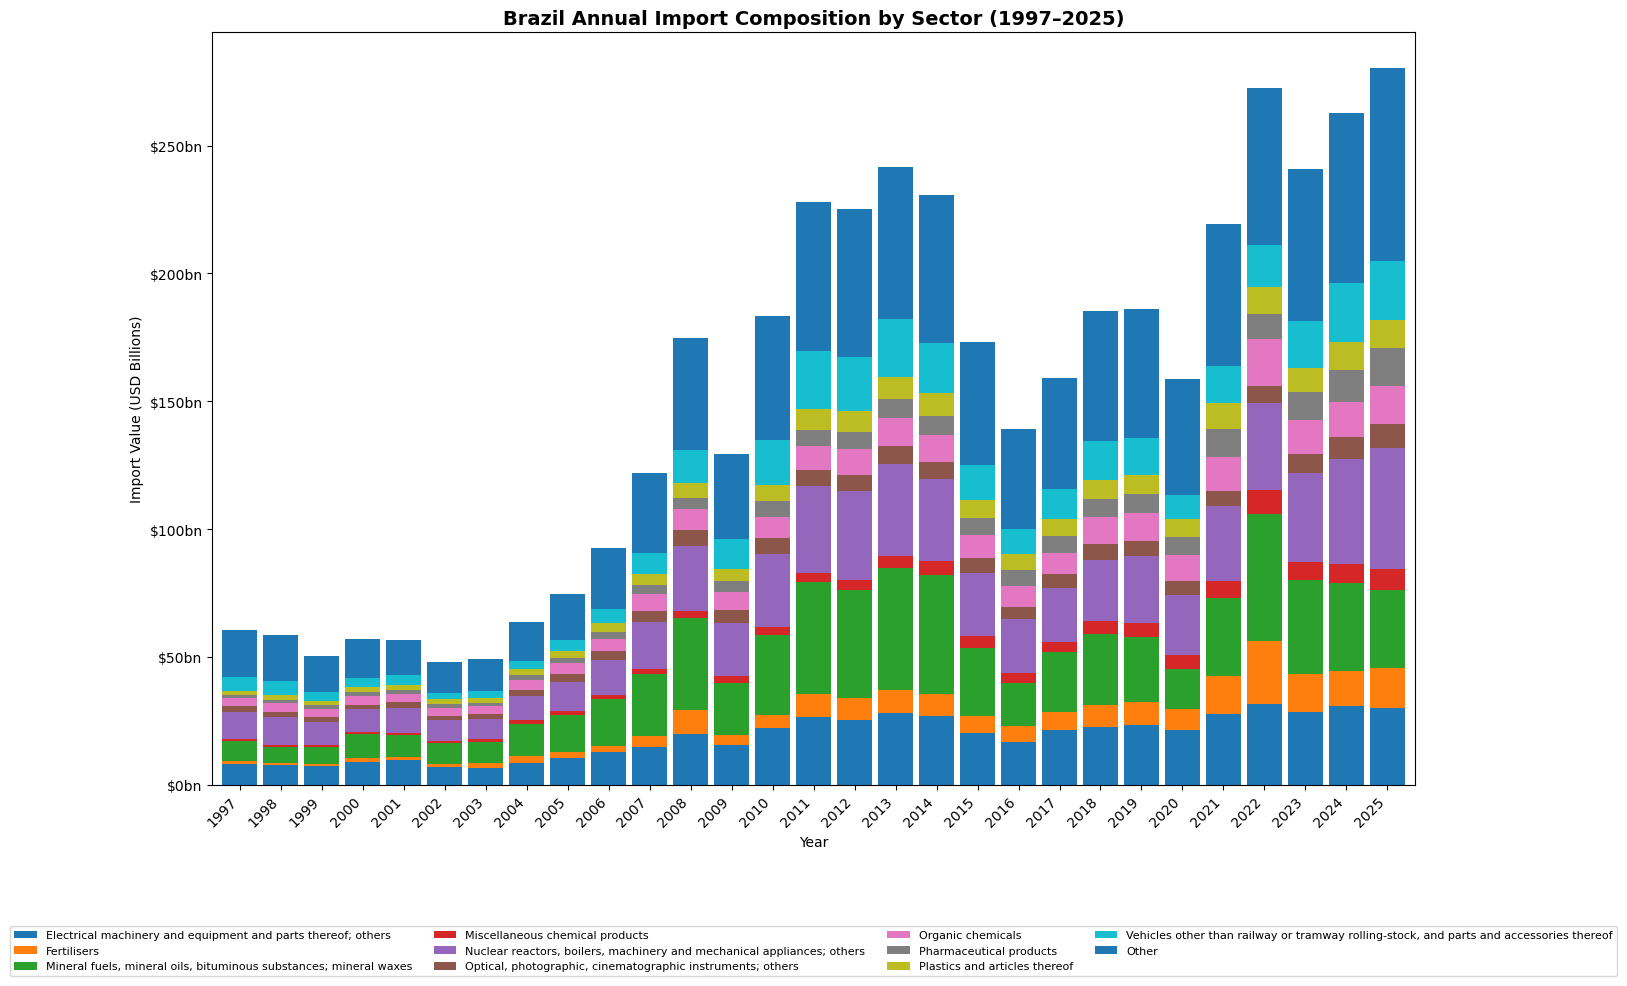


Brazil import composition by sector (2025) — Total: $280.2bn



Sector,Imports (USD bn),Share (%)
"Nuclear reactors, boilers, machinery and mechanical app",$47.03bn,16.8%
"Mineral fuels, mineral oils, bituminous substances; min",$30.53bn,10.9%
Electrical machinery and equipment and parts thereof; o,$30.13bn,10.8%
"Vehicles other than railway or tramway rolling-stock, a",$23.06bn,8.2%
Fertilisers,$15.49bn,5.5%
Organic chemicals,$14.97bn,5.3%
Pharmaceutical products,$14.54bn,5.2%
Plastics and articles thereof,$10.99bn,3.9%
"Optical, photographic, cinematographic instruments; oth",$9.55bn,3.4%
Miscellaneous chemical products,$8.47bn,3.0%


In [16]:
## Brazil annual import composition by SH2 sector (1997–MAX_YEAR)
query_brazil_imp_annual = f"""
    SELECT i."CO_ANO" AS year,
           s.descricao_sh2_ing AS sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", s.descricao_sh2_ing
    ORDER BY i."CO_ANO", imports_usd DESC
"""

### ____________ Graph - Brazil Annual Import Composition by Sector (All Years) _______________________

df_brazil_imp_annual = pd.read_sql(query_brazil_imp_annual, engine)
df_brazil_imp_annual['imports_usd_bn'] = df_brazil_imp_annual['imports_usd'] / 1e9

## Identify top 10 sectors by total imports across all years — group rest as Other
top10_imp_sectors = (
    df_brazil_imp_annual.groupby('sector')['imports_usd']
    .sum().nlargest(10).index.tolist()
)

df_brazil_imp_annual['sector_group'] = df_brazil_imp_annual['sector'].apply(
    lambda x: x if x in top10_imp_sectors else 'Other'
)

df_brazil_imp_grouped = (
    df_brazil_imp_annual.groupby(['year', 'sector_group'])['imports_usd_bn']
    .sum().reset_index()
)

df_brazil_imp_pivot = df_brazil_imp_grouped.pivot(
    index='year', columns='sector_group', values='imports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_imp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_imp_pivot = df_brazil_imp_pivot[cols_ordered]

## Plot
fig, ax = plt.subplots(figsize=(16, 10))
df_brazil_imp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Import Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Import Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=8,
    frameon=True
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_7b_brazil_imp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()

###___________ Summary Table Brazil import composition by sector _________________
## Summary table for MAX_YEAR
df_imp_annual_display = (
    df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]
    .groupby('sector')['imports_usd_bn'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .assign(share=lambda x: (x['imports_usd_bn'] / x['imports_usd_bn'].sum() * 100).round(1))
)

# Remove sectors with share < 0.1%
df_imp_annual_display = df_imp_annual_display[df_imp_annual_display['share'] >= 0.1]

# Formatting
df_imp_annual_display = (
    df_imp_annual_display
    .rename(columns={
        'sector'        : 'Sector',
        'imports_usd_bn': 'Imports (USD bn)',
        'share'         : 'Share (%)'
    })
    .reset_index(drop=True)
)

df_imp_annual_display['Sector'] = df_imp_annual_display['Sector'].str[:55]
df_imp_annual_display['Imports (USD bn)'] = df_imp_annual_display['Imports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_imp_annual_display['Share (%)'] = df_imp_annual_display['Share (%)'].apply(
    lambda x: f'{x:.1f}%'
)

total = df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]['imports_usd_bn'].sum()

print(f"\nBrazil import composition by sector ({MAX_YEAR}) — Total: ${total:.1f}bn\n")

display(
    df_imp_annual_display.style
    .set_caption(f"Brazil import composition by sector ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview

Brazil's total imports reached \\$280.2bn in 2025, up from approximately \\$62bn in 1997 — a 4.5x increase over 28 years. The import chart follows a broadly similar trajectory to exports: expansion from 1997 to 2013 (peak at approximately \\$243bn), contraction from 2014 to 2016, and recovery from 2017 onward reaching a new peak in 2025. The import composition is structurally more stable than the export composition — the same three or four sectors dominate throughout the period with variation primarily in weighting rather than composition.

#### 2025 Sector Composition

The top 10 sectors account for 73.0% of total imports (\\$204.6bn). The top 3 sectors alone — machinery, mineral fuels, and electrical equipment — account for 38.5% (\\$107.7bn).

| Sector | 2025 (\\$bn) | Share (%) |
|---|---|---|
| Machinery (SH84) | \\$47.03bn | 16.8% |
| Mineral fuels and oils (SH27) | \\$30.53bn | 10.9% |
| Electrical machinery and equipment (SH85) | \\$30.13bn | 10.8% |
| Vehicles (SH87) | \\$23.06bn | 8.2% |
| Fertilisers (SH31) | \\$15.49bn | 5.5% |
| Organic chemicals (SH29) | \\$14.97bn | 5.3% |
| Pharmaceutical products (SH30) | \\$14.54bn | 5.2% |
| Plastics and articles thereof (SH39) | \\$10.99bn | 3.9% |
| Optical and photographic instruments (SH90) | \\$9.55bn | 3.4% |
| Miscellaneous chemical products (SH38) | \\$8.47bn | 3.0% |

The top 4 sectors — machinery, mineral fuels, electrical equipment, and vehicles — are all industrial capital goods or energy inputs. The first agricultural input sector, fertilisers (SH31), appears fifth at 5.5% (\\$15.49bn).

Below the top 10, 63 additional sectors contribute the remaining 27.0% (\\$75.6bn). No individual sector below the top 10 exceeds 1.9% (ships and floating structures, SH89, \\$5.42bn).

---

#### Export-Import Structural Contrast

Comparing Brazil's export and import top 4 directly:

| Export top 4 | \\$bn | Import top 4 | \\$bn |
|---|---|---|---|
| Mineral fuels (SH27) | \\$55.96bn | Machinery (SH84) | \\$47.03bn |
| Oil seeds (SH12) | \\$44.67bn | Mineral fuels (SH27) | \\$30.53bn |
| Ores (SH26) | \\$34.89bn | Electrical equipment (SH85) | \\$30.13bn |
| Meat (SH2) | \\$29.98bn | Vehicles (SH87) | \\$23.06bn |

Brazil's export top 4 are all primary commodities. Brazil's import top 4 are all industrial capital goods or energy. This structural contrast is the national-level expression of the commodity-vs-manufactured goods finding documented in Section 2.12.

#### Import Deficit by Strategic Sector

Six sectors where Brazil's imports materially exceed its exports:

| Sector | Exports | Imports | Net |
|---|---|---|---|
| Machinery (SH84) | \\$13.89bn | \\$47.03bn | -\\$33.14bn |
| Electrical equipment (SH85) | \\$5.10bn | \\$30.13bn | -\\$25.03bn |
| Fertilisers (SH31) | \\$0.32bn | \\$15.49bn | -\\$15.17bn |
| Organic chemicals (SH29) | \\$1.72bn | \\$14.97bn | -\\$13.25bn |
| Pharmaceuticals (SH30) | \\$1.27bn | \\$14.54bn | -\\$13.27bn |
| Vehicles (SH87) | \\$15.08bn | \\$23.06bn | -\\$7.98bn |

These six categories generate a combined import deficit of \\$107.77bn. Brazil's overall trade surplus is generated by overcoming this \\$107.77bn deficit in capital goods and industrial inputs through commodity exports.

---

#### Structural Transformation 1 — Capital Goods Dominance (1997–Present)

Machinery (SH84) and electrical equipment (SH85) form a consistent base across all 29 years. Their combined absolute value grew from approximately \\$10bn (1997) to approximately \\$77bn (2025) — a 7.7x increase — while holding broadly stable as a share of total imports. This reflects a capital goods import dependency that has persisted regardless of commodity price cycles or macroeconomic conditions.

#### Structural Transformation 2 — The 2003–2013 Import Expansion

Brazil's imports grew from approximately \\$50bn (2003) to approximately \\$240bn (2013) — a nearly 5x increase in a decade. The chart shows all segments growing simultaneously across this period. The Real appreciation from 2005 to 2014 made imports cheaper in domestic currency terms — the import expansion coincides directly with the [period of Real overvaluation documented in Brazilian macroeconomic literature](https://rosa.uniroma1.it/rosa04/psl_quarterly_review/article/view/17308). Vehicles (SH87) and petroleum (SH27) grew particularly visibly in this period.

> ⚠️ *The contribution of Real appreciation to the 2003–2013 import expansion is a standard macroeconomic inference but requires exchange rate data to quantify precisely. This is outside the scope of the current dataset.*

#### Structural Transformation 3 — The Mineral Fuels Position

Brazil simultaneously exports \\$55.96bn of mineral fuels (SH27) and imports \\$30.53bn — a net surplus of \\$25.43bn. The gross flows indicate that Brazil exports crude oil and imports refined petroleum products. The SH27 import segment is visible throughout all 29 years of the chart and grew in absolute terms post-2020 as global energy prices increased.

> ⚠️ *The crude export vs. refined product import split within SH27 requires NCM-level disaggregation to confirm and quantify. The \\$25.43bn net surplus figure conflates both flows and is not a clean measure of refining capacity deficit. Deferred to Step 5.*

#### Structural Transformation 4 — The Pharmaceutical Growth Trend

The pharmaceutical segment (SH30) grows from a small base in 1997 to \\$14.54bn (5.2%) in 2025. The growth is visible in the chart as a consistent year-on-year expansion across the full period, including during the 2014–2016 recession and the 2020 COVID contraction — making it the only top-10 import sector that did not contract during either downturn. At \\$14.54bn against \\$1.27bn in exports, the pharmaceutical import-to-export ratio is 11.5x.

---

#### Contractions and Shocks

**2009** — All segments contracted proportionally. The composition is effectively unchanged.

**2014–2016** — The contraction is more pronounced on the import side than on the export side. Vehicles, machinery, and electrical equipment segments all visibly shrank — consistent with domestic investment and consumer demand contraction. Pharmaceutical imports did not contract.

**2020 (COVID-19)** — The 2020 bar is visibly shorter than 2019, in contrast to the export chart where the 2020 bar barely dips. Consumer goods, capital goods, and vehicle imports fell as domestic demand contracted and mobility collapsed. Commodity exports continued — [China sustained soybean and iron ore purchases through 2020](https://www.spglobal.com/energy/en/news-research/latest-news/agriculture/042020-chinas-2019-2020-soybean-demand-to-remain-strong-despite-covid-19-african-swine-fever). This asymmetry between import contraction and export resilience is the mechanism by which Brazil maintained a positive trade balance through the pandemic year.

**2022 — The Fertiliser Spike**

The fertiliser segment (SH31) enlarges visibly in 2022, reflecting the global fertiliser supply disruption following the Russia-Ukraine conflict. The 2022 bar shows the fertiliser segment at its largest absolute value in the dataset. This supply shock simultaneously raised Brazilian agricultural input costs (fertiliser imports increased in price) and raised Brazilian agricultural export revenues (global food commodity prices surged). The net effect on the trade balance was positive in 2022, but the import cost increase is visible in the data.

---

#### Import and Export Chart Comparison

| Feature | Export chart | Import chart |
|---|---|---|
| Composition stability 1997–2025 | Low — commodity price cycles shift proportions | High — capital goods share consistent throughout |
| COVID-19 impact (2020) | Minimal — bars barely shorten | Visible — 2020 bar clearly shorter |
| Largest single segment (2025) | SH27 mineral fuels (16.1%) | SH84 machinery (16.8%) |
| Fastest growing segment post-2015 | SH27 petroleum (pre-salt ramp-up) | SH30 pharmaceuticals |
| Agricultural sector presence | Dominant — SH12, SH2, SH9 in top 5 | Minimal — SH31 fertilisers only in top 10 |

> ⚠️ *Fertilisers (SH31) at \\$15.49bn (5.5%) represent Brazil's most directly quantifiable agricultural supply chain dependency in this dataset. The 2022 price spike is visible in the chart. The origin country composition of fertiliser imports — and therefore the geopolitical concentration of this dependency — requires external trade partner data and is outside the scope of the current dataset.*

> ⚠️ *Vessels and floating structures (SH89) at \\$5.42bn are concentrated in Rio de Janeiro (\\$2.46bn) and São Paulo (\\$2.81bn), consistent with offshore oil infrastructure procurement. The NCM-level composition of this category — whether drill ships, FPSOs, support vessels or other marine structures — requires Step 5 investigation.*


---
---

## 2.6 — Product-Level Detail: Top 10 NCM Products by State and Region
Drilling below sector level to the specific NCM product codes — showing the top 10 individual products exported by each state and each region, with value and share of state or regional total.

In [19]:
## __________________________ TOP NCM BY STATE _________________________
query_ncm_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm_ing,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, e."CO_NCM", n.nome_ncm_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_ncm_state = pd.read_sql(query_ncm_state, engine)
df_ncm_state['exports_usd_bn'] = (df_ncm_state['exports_usd'] / 1e9).round(3)

df_top10_ncm_state = (
    df_ncm_state.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 NCM products by state ({MAX_YEAR})")
for state in df_top10_ncm_state['state'].unique():
    subset = df_top10_ncm_state[df_top10_ncm_state['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm_ing'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

## ______________________ TOP NCM BY REGION _______________________________
query_ncm_region = f"""
    SELECT u.nome_regiao AS region,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm_ing,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, e."CO_NCM", n.nome_ncm_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_ncm_region = pd.read_sql(query_ncm_region, engine)
df_ncm_region['exports_usd_bn'] = (df_ncm_region['exports_usd'] / 1e9).round(3)

df_top10_ncm_region = (
    df_ncm_region.groupby('region', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

## Build region totals directly from the NCM query — same source, same region names
region_totals_raw = (
    df_ncm_region.groupby('region')['exports_usd'].sum()
)

print(f"\nTop 10 NCM products by region ({MAX_YEAR})")
for region in df_top10_ncm_region['region'].unique():
    subset = df_top10_ncm_region[df_top10_ncm_region['region'] == region]
    total  = region_totals_raw.get(region, 0)
    
    ## Apply region name map for display
    region_display = region_map.get(region, region)
    
    print(f"\n{region_display} — Total exports: ${total/1e9:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / total * 100) if total > 0 else 0
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm_ing'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\984190713.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


Top 10 NCM products by state (2025)

Acre — Total exports: $0.1bn
  NCM 2023000 Frozen bovine meat, boneless                       $0.020bn (20.5%)
  NCM 12019000 Soybeans, whether or not crushed, except for sowin $0.020bn (20.4%)
  NCM 2032900 Other swine meat, frozen                           $0.014bn (13.7%)
  NCM 8012100 Fresh/dried, brazil nuts, in shell                 $0.009bn (9.4%)
  NCM 2013000 Fresh or chilled bovine meat, boneless             $0.007bn (7.1%)
  NCM 1022990 Other live catlle                                  $0.005bn (5.1%)
  NCM 5040090 Fresh, etc.bladders and stomach of anim.exc.fish   $0.004bn (3.8%)
  NCM 8012200 Fresh/dried, brazil nuts, shelled                  $0.003bn (3.0%)
  NCM 2062990 Other frozen edible bovine offal                   $0.003bn (2.7%)
  NCM 2031900 Other fresh or chilled meat of swine               $0.002bn (2.2%)

Alagoas — Total exports: $0.8bn
  NCM 17011400 Other cane sugar                                   $0.509bn (62.0%)
  NC

C:\Users\e_koh\AppData\Local\Temp\ipykernel_11864\984190713.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


### The NCM Level Reveals What SH2 Conceals

Moving from SH2 sector classification to individual NCM product codes resolves several ambiguities identified at the sector level and reveals the specific commodities driving each state's export identity.

### Key NCM-Level Findings by State

**Rio de Janeiro — crude oil is 79.2% of exports at a single NCM code.**
NCM 27090010 (óleos brutos de petróleo) at \\$38.815bn accounts for 79.2% of total exports — the highest single-NCM concentration of any state in the dataset. The next nine NCM codes collectively contribute less than 12%. This confirms that Rio de Janeiro's entire export identity rests on a single product from a single extraction activity.

**Piauí — soybeans at 82.8% of a single NCM code.**
NCM 12019000 (soja) at \\$0.993bn is 82.8% of total exports — the most extreme agricultural NCM concentration in the dataset. Piauí is functionally a single-product exporter.

**Minas Gerais — the only state with two NCM codes each exceeding \$11bn.**
Iron ore (NCM 26011100, \\$12.231bn, 26.7%) and coffee beans (NCM 9011110, \\$11.263bn, 24.6%) sit almost equally at the top. No other state has two primary products of comparable absolute value competing for the dominant position. Together they account for 51.3% of Minas Gerais's exports — a concentrated but genuinely dual-anchor profile.

**Amazonas — the Zona Franca NCM fingerprint is unmistakable.**
The top NCM codes — beverage preparation bases (NCM 21069010, \$0.210bn), gold bars (NCM 71081310, \$0.158bn), ferro-niobium (NCM 72029300, \\$0.107bn) and motorcycles 150–250cc (NCM 87113000, \\$0.070bn) — reflect the specific manufacturing operations in Manaus. The motorcycle codes (Honda, Yamaha operations) and electronic components confirm the Zona Franca's manufactured goods profile. The ferro-niobium is unexpected — likely related to the CBMM niobium processing operations that supply global steel producers.

**Pará — two copper ore NCM codes alongside iron ore.**
After iron ore (NCM 26011100, \\$11.640bn, 47.8%), the second largest NCM is other copper ores (NCM 26030090, \\$3.590bn, 14.8%) and alumina (NCM 28182010, \\$1.988bn, 8.2%). Pará is not just an iron ore state — it is a multi-mineral extraction economy. The copper and aluminium presence reflects the Sossego and Cristalino copper mines and the Alunorte alumina refinery.

**Bahia — gold bullion in third position.**
NCM 71081210 (bulhão dourado — gold bullion in raw form) at \\$1.072bn (9.2%) ranks third in Bahia's export list, confirming the SH71 precious metals observation from cell 2.6. The Jacobina gold mine (Yamana Gold) is the primary source. Gold bullion is a genuine Bahia export rather than a statistical artefact.

**Ceará — semi-manufactured steel products dominate.**
NCM 72071200 (outros produtos semimanufaturados de ferro ou aço, \\$0.735bn, 32.2%) and NCM 72249000 (produtos semimanufaturados de outras ligas de aço, \\$0.420bn, 18.4%) together account for 50.6% of exports. This confirms the Pecém steel complex (CSP — Companhia Siderúrgica do Pecém) as the dominant driver of Ceará's export profile — Brazil's newest integrated steel plant, built specifically to export semi-finished steel products (billets and slabs) to international markets. This explains both Ceará's high ESI (structurally different from the national mix) and its moderate HHI (steel products span multiple NCM codes within SH72).

**Pernambuco — Stellantis vehicles dominate at NCM level.**
NCM 87032210 (automóveis com motor explosão, 1000–1500cc, \\$0.505bn, 19.9%) and NCM 87043190 (outros veículos com motor a explosão, \\$0.271bn, 10.7%) together account for 30.6% — confirming the Jeep Compass and commercial vehicle exports from the Goiana (PE) Stellantis plant as the anchor of Pernambuco's export profile.

**Santa Catarina — pork as the single largest NCM.**
NCM 2032900 (outras carnes de suíno, congeladas, \\$1.656bn, 13.6%) is Santa Catarina's largest single product. WH Group (formerly Shuanghui) and BRF operations in the state drive this. The electric motors (NCM 85015210, NCM 85015310) confirm the Weg and other industrial equipment manufacturers that are internationally significant but individually smaller than the meat sector.

**São Paulo — sugar as the largest single NCM despite industrial diversification.**
NCM 17011400 (outros açúcares de cana, \\$7.061bn, 9.9%) is the largest single NCM code — reflecting the massive sugarcane processing industry in São Paulo's interior (Ribeirão Preto region). The aircraft (NCM 88024090, \\$2.789bn, 3.9%) confirms Embraer as a major NCM-level contributor. São Paulo's top 10 NCM codes span sugar, crude oil, beef, aircraft, fuel oil, soybeans, pulp, aviation fuel, coffee and refined sugar — the most genuinely diversified NCM top-10 in the dataset.

**Maranhão — alumina as the second largest NCM.**
NCM 28182010 (alumina calcinada, \\$1.389bn, 27.7%) is the second largest product — the Alunorte alumina refinery (Norsk Hydro) in Barcarena processes bauxite from Pará and exports alumina through the Itaqui port. This confirms that Maranhão's port infrastructure serves as an export gateway for Norte region mineral processing.

**Goiás — ferro-niobium and ferro-nickel appear alongside soybeans.**
NCM 72029300 (ferro-nióbio, \\$0.424bn, 3.2%) and NCM 72026000 (ferro-níquel, \\$0.410bn, 3.0%) — both ferro-alloys — appear in Goiás's top 10 alongside the dominant agricultural products. CBMM (Companhia Brasileira de Metalurgia e Mineração) in Araxá, Goiás holds approximately 75% of global niobium reserves. The ferro-niobium export reflects this near-monopoly strategic mineral position. Goiás is simultaneously Brazil's soybean frontier and the world's niobium capital.

---

### Regional NCM-Level Findings

**Centro-Oeste — the most concentrated regional NCM profile.**
Soybeans (37.4%), beef (12.5%) and corn (11.1%) account for 61.0% of regional exports at the top three NCM positions. The agricultural commodity dominance is total at the regional level. Cotton (6.0%), pulp (5.7%) and animal feed (5.5%) complete an agricultural supply chain profile with minimal industrial presence.

**Norte — iron ore at 36.5% defines the region.**
Iron ore (NCM 26011100, \\$11.640bn, 36.5%) is almost entirely from Pará's Carajás complex. The copper ore presence (11.3%) reflects Pará's multi-mineral profile. Beef (9.4%) and alumina (6.2%) add agricultural and processing dimensions but the regional identity is primarily extractive mineral.

**Nordeste — soybeans are the largest regional NCM despite not being the Nordeste's traditional product.**
Soybeans at 21.2% (\\$5.341bn) reflect the MATOPIBA expansion into Piauí and Maranhão pulling the regional aggregate. Fuel oil (9.3%) is dominated by Rio Grande do Norte and Sergipe onshore oil. Alumina (5.5%, Maranhão) and gold bullion (5.6%) reveal the mineral processing and extraction activities that do not fit the traditional Nordeste agricultural narrative.

**Sudeste — crude oil at 24.3% anchors the region.**
NCM 27090010 at \\$42.873bn (24.3%) — almost entirely from Rio de Janeiro — is the largest regional NCM by an enormous margin. Coffee (8.1%, primarily Minas Gerais and Espírito Santo), iron ore (8.0%) and sugar (5.0%, primarily São Paulo) follow. The aerospace entry (NCM 88024090, \\$2.817bn, 1.6%) confirms Embraer's Sudeste contribution at the regional level. The Sudeste top 10 spans oil, coffee, iron ore, sugar, soybeans, beef, fuel oil, pulp, semi-manufactured steel and aircraft — the most structurally diverse regional NCM profile.

**Sul — soybeans lead but meat products dominate the bulk of the top 10.**
Soybeans (15.3%) lead but pork (5.1%), tobacco (4.7%), animal feed (3.8%), chicken breast (3.3%), whole chicken (2.4%), corn (2.4%), pulp (2.2%), sugar (2.0%) and chicken thighs (1.9%) follow — six of the top 10 positions are meat or animal products. The Sul is Brazil's protein export powerhouse at the NCM level. BRF (headquartered in Itajaí, SC), JBS Sul operations and tobacco processors (British American Tobacco, Philip Morris) define the regional product identity.

---

### Cross-Cutting NCM Observations

**NCM 12019000 (soybeans) appears in the top 10 of 22 of 27 states** — the most universally present individual NCM code in Brazil. Only Rio de Janeiro, Ceará, Sergipe, Alagoas and Acre do not have soybeans in their top 10 by value.

**NCM 71081210 (gold bullion in raw form) appears in 8 states** — Bahia, Minas Gerais, Pará, Tocantins, Maranhão, Amapá, Rio Grande do Norte and Mato Grosso. The geographic spread confirms that gold extraction is distributed across multiple states with different geological profiles. The cumulative value across these states is substantial and resolves the SH71 ambiguity identified in cell 2.6 — the precious stones category is predominantly gold bullion rather than gemstones or jewellery.

**The Pecém (Ceará) and CSP steel finding** — the semi-manufactured steel NCM dominance in Ceará (50.6% of exports from two steel NCM codes) is one of the most structurally specific findings at the NCM level. CSP was built as an export-oriented billet and slab facility and its product mix confirms this — semi-manufactured steel rather than finished steel products.

**The CBMM niobium finding** — ferro-niobium (NCM 72029300) appears in Goiás, Minas Gerais and Amazonas. Goiás (\\$0.424bn) and Minas Gerais (\\$2.126bn) are the primary sources. Brazil's near-monopoly on global niobium supply is visible at the NCM level — a strategic mineral that is essential for high-strength steel production and increasingly for battery technology.

> ⚠️ *NCM 71081210 (gold bullion) appearing in 8 states resolves the SH71 classification question from cell 2.6. The \\$7.19bn national SH71 figure is predominantly gold bullion exports rather than gemstones or jewellery — a distinction that matters for understanding Brazil's precious metals trade policy and its exposure to gold price cycles.*

> ⚠️ *The CBMM ferro-niobium finding (NCM 72029300) deserves specific attention in Step 5. Brazil controls approximately 75% of global niobium reserves and CBMM in Araxá holds the dominant share. Niobium is classified as a critical mineral by the EU, US and China for its role in steel strengthening and emerging battery technology applications. The \$2.126bn Minas Gerais + \\$0.424bn Goiás export volumes represent a strategically significant but analytically underexplored component of Brazil's mineral export base.*
---
---

## 2.7 — China Dependency at State Level: Is the 28.7% National Average Uniform?
Step 1 showed China absorbs 28.7% of Brazil total exports. This section examines whether that dependency is uniform across all states or concentrated in specific ones — and what products each state sends to China.

### 2.7.1 — China Share of State Exports: Which States Are Most Exposed?
Horizontal bar chart ranking all states by the share of their exports destined for China — with the 28.7% national average as a reference line.

In [ ]:
china_code_query = "SELECT codigo_pais FROM pais WHERE nome_pais_ing = 'China'"
china_code = pd.read_sql(china_code_query, engine)['codigo_pais'].iloc[0]

query_china_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_to_china
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_PAIS" = {china_code}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY exports_to_china DESC
"""

df_china_state = pd.read_sql(query_china_state, engine)
df_china_state['exports_to_china_bn'] = (df_china_state['exports_to_china'] / 1e9).round(2)

df_china_share = df_china_state.merge(
    df_state[['uf', 'exports_usd', 'exports_usd_bn']], on='uf', how='left'
)
df_china_share['china_share_%'] = (
    df_china_share['exports_to_china'] / df_china_share['exports_usd'] * 100
).round(1)

df_china_plot = df_china_share.sort_values('china_share_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_china_plot['state'], df_china_plot['china_share_%'], color='steelblue', alpha=0.85)
ax.axvline(x=28.7, color='tomato', linestyle='--', linewidth=1.5, label='National average (28.7%)')
ax.set_title(f"Share of State Exports Destined for China ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("China Share of State Exports (%)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('output_2_9_china_dependency.png', dpi=150)
plt.show()

print(f"\nChina dependency by state ({MAX_YEAR}) — national average: 28.7%")
print(df_china_share[['state', 'exports_to_china_bn', 'exports_usd_bn', 'china_share_%']]
      .sort_values('china_share_%', ascending=False)
      .to_string(index=False))

The national average of 28.7% masks enormous variation across states — ranging from 72.5% (Piauí) to 0.7% (Sergipe). The China dependency is highly concentrated in commodity-producing states and negligible in industrial or service-oriented states.

### States Far Above the National Average (>35%)

**Piauí (72.5%)** — the most China-dependent state in Brazil. Nearly three quarters of Piauí's exports go to China, almost entirely soybeans (95.2% of China-bound exports). Piauí has effectively one product and one buyer.

**Tocantins (55.6%)** — soybeans (74.5%) and beef (24.3%) dominate China-bound exports. Two agricultural commodities, one dominant buyer.

**Pará (45.4%)** — iron ore (81.6% of China-bound exports, \$9.01bn) defines the relationship. China's infrastructure and steel demand is the direct anchor of Pará's trade balance.

**Mato Grosso do Sul (44.6%)** — a notable finding. Pulp (36.3%) and soybeans (43.7%) together account for 80% of China-bound exports — a more diversified China profile than most agricultural states.

**Goiás (43.3%)** — soybeans (75.7%) and beef (12.4%) dominate. Ferro-niobium (not in top 3 to China) suggests the strategic mineral goes primarily to non-Chinese destinations — an analytically interesting divergence.

**Mato Grosso (40.7%)** — despite being Brazil's largest soybean exporter, Mato Grosso's China share (40.7%) is lower than Piauí (72.5%) or Tocantins (55.6%) because its export base is larger and more diversified — cotton, corn and beef spread the destination risk slightly.

**Rio de Janeiro (37.5%)** — crude oil to China (94.5% of China-bound exports, \$17.37bn). China is Rio de Janeiro's single largest oil customer by a wide margin. The pre-salt oil relationship with China is the largest bilateral state-country trade flow in Brazil.

**Minas Gerais (35.0%)** — iron ore to China (61.9%, \$9.94bn) dominates, with soybeans (14.6%) and iron and steel (6.6%) secondary. Minas Gerais and Pará together supply the bulk of China's Brazilian iron ore imports.

### States Near the National Average (20–35%)

**Maranhão (34.1%)** — almost entirely soybeans (98.6% of China-bound exports). Despite having alumina and pulp in its export mix, essentially all China-bound exports are agricultural.

**Rondônia (33.0%)** — beef (69.6%) and soybeans (25.0%) dominate. A pure agricultural frontier China dependency profile.

**Bahia (28.1%)** — the most diversified China-bound export profile among states near the average. Soybeans (56.3%), pulp (24.8%) and ores (8.8%) — three genuinely distinct sectors rather than a single commodity.

**Rio Grande do Sul (22.5%) and Paraná (22.5%)** — both below the national average despite being large exporters. Their diversified agro-industrial bases distribute exports across multiple destinations — USA, Europe, Middle East and Asia — rather than concentrating in China.

### States Far Below the National Average (<15%)

**São Paulo (13.7%)** — the most industrially diversified state has the lowest China share among large exporters. Its export mix (aerospace, vehicles, machinery, chemicals) finds more buyers in the USA, Europe and Latin America than in China. Petroleum (24.7% of China-bound) and beef (21.0%) dominate even São Paulo's China relationship — suggesting that China primarily sources commodities rather than industrial goods even from Brazil's most industrial state.

**Amazonas (12.7%)** — the Zona Franca manufactured goods (motorcycles, electronics) export primarily to Brazil's domestic market or Latin American neighbours rather than to China.

**Santa Catarina (9.9%)** — despite being a major pork and machinery exporter, only 9.9% goes to China. Santa Catarina's export destinations are more diversified than its northern neighbours.

**Espírito Santo (5.8%)** — counter-intuitive given that iron ore and coffee are major exports. The iron ore likely routes through Minas Gerais export statistics (Vale's headquarters) while Espírito Santo's own ore goes to a broader set of destinations.

**Ceará (3.8%) and Pernambuco (3.2%)** — the Nordeste industrial states have minimal China exposure. Ceará's semi-finished steel goes to non-Chinese markets; Pernambuco's vehicles export to Latin America and Europe via the Suape port.

**Sergipe (0.7%)** — effectively no China relationship. Onshore oil and citrus products find alternative markets.

### The Product Structure of China-Bound Exports

Across all states, China-bound exports are overwhelmingly concentrated in three product categories:
1. **Soybeans** — the agricultural anchor across 15+ states
2. **Iron ore** — the mineral anchor (Minas Gerais, Pará, Espírito Santo)
3. **Crude oil** — the energy anchor (Rio de Janeiro, São Paulo)

China does not import Brazil's industrial goods, aerospace products, vehicles or processed foods in any meaningful quantity. The China relationship is almost exclusively a primary commodity relationship — raw materials extracted from Brazil to fuel Chinese manufacturing and construction.

> ⚠️ *The top 5 most China-dependent states (Piauí 72.5%, Tocantins 55.6%, Pará 45.4%, Mato Grosso do Sul 44.6%, Goiás 43.3%) are all commodity states with minimal export market diversification. A sustained shift in Chinese demand — whether from economic slowdown, domestic soybean production expansion or energy transition reducing steel demand — would disproportionately impact exactly the states that have already benefited most from the commodity supercycle.*

---
---

### 2.7.2 — What Each State Sends to China: Export Composition by SH2 Sector
Stacked horizontal bar chart showing the product composition of each state exports to China by SH2 sector — revealing whether China dependency is driven by the same products across states or reflects different sectoral profiles.

In [ ]:
## Query China exports by state and SH2 sector
query_china_state_sh2 = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_PAIS" = {china_code}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.descricao_sh2_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_china_sh2 = pd.read_sql(query_china_state_sh2, engine)

## Stacked horizontal bar — exports to China by state, shaded by SH2 sector
## Shows the product composition of each state's exports to China

## Pivot: rows = states, columns = sectors, values = exports to China in USD bn
df_china_sh2['exports_usd_bn'] = df_china_sh2['exports_usd'] / 1e9

## Keep top 8 sectors by total value across all states — group rest as Other
top8_china_sectors = (
    df_china_sh2.groupby('sector')['exports_usd']
    .sum().nlargest(8).index.tolist()
)
df_china_sh2['sector_group'] = df_china_sh2['sector'].apply(
    lambda x: x if x in top8_china_sectors else 'Other'
)
df_china_sh2_grouped = (
    df_china_sh2.groupby(['state', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_china_stacked = df_china_sh2_grouped.pivot(
    index='state', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder states by total exports to China (descending)
df_china_stacked['_total'] = df_china_stacked.sum(axis=1)
df_china_stacked = df_china_stacked.sort_values('_total', ascending=True).drop(columns='_total')

## Put Other last
cols_ordered = [c for c in df_china_stacked.columns if c != 'Other'] + \
               (['Other'] if 'Other' in df_china_stacked.columns else [])
df_china_stacked = df_china_stacked[cols_ordered]

## Add national average share line — convert to USD for positioning
national_avg_line = df_china_share.set_index('state')['china_share_%']

fig, ax = plt.subplots(figsize=(14, 10))
df_china_stacked.plot(kind='barh', stacked=True, ax=ax, width=0.8,
                      colormap='tab10', alpha=0.85)

## Overlay national average as a reference annotation
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title(f"Exports to China by State — Product Composition ({MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Export Value to China (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='lower right', fontsize=7,
          title='SH2 Sector', title_fontsize=8,
          bbox_to_anchor=(1.01, 0), borderaxespad=0)
plt.tight_layout()
plt.savefig('output_2_9b_china_dependency_sh2_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table — top 3 sectors per state for exports to China
df_top3_china = (
    df_china_sh2.groupby(['state', 'sector'], group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'exports_usd'))
    .reset_index(drop=True)
)
df_top3_china['exports_usd_bn'] = (df_top3_china['exports_usd'] / 1e9).round(2)

print(f"\nTop 3 sectors exported to China by state ({MAX_YEAR})")
for state in df_china_stacked.sort_values(df_china_stacked.columns[0],
                                           ascending=False).index:
    subset = df_top3_china[df_top3_china['state'] == state]
    if subset.empty:
        continue
    total_to_china = df_china_share[df_china_share['state'] == state]['exports_to_china_bn'].iloc[0]
    print(f"\n{state} — Total to China: ${total_to_china:.2f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total_to_china * 1e9) * 100)
        print(f"  {str(row['sector'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

This cell reveals not just how much each state exports to China but what it exports — confirming whether the China relationship is product-diversified or concentrated in a single commodity.

### The Two China Export Archetypes

**Archetype 1 — Single-commodity dominance (>70% in one sector)**

| State | Top sector to China | Share |
|---|---|---|
| Rio de Janeiro | Mineral fuels (crude oil) | 94.5% |
| Pernambuco | Mineral fuels | 95.8% |
| Piauí | Soybeans | 95.2% |
| Distrito Federal | Soybeans | 99.7% |
| Maranhão | Soybeans | 98.6% |
| Pará | Ores and slag (iron ore) | 81.6% |
| Amazonas | Iron and steel (ferro-niobium) | 81.7% |

These states send China essentially one product. Any shift in Chinese demand for that product directly and immediately affects the state's entire China relationship.

**Archetype 2 — Multi-sector China relationship (no single sector >60%)**

| State | Top 3 sectors | Combined share |
|---|---|---|
| São Paulo | Petroleum + Meat + Soybeans | 62.2% |
| Mato Grosso do Sul | Soybeans + Pulp + Meat | 97.0% |
| Bahia | Soybeans + Pulp + Ores | 89.9% |
| Espírito Santo | Ores + Pulp + Minerals | 93.1% |
| Santa Catarina | Soybeans + Meat + Timber | 87.3% |

Even these "diversified" China exporters are almost exclusively sending primary commodities and processed primary goods. None are exporting manufactured goods, machinery, vehicles or high-technology products to China in any meaningful quantity.

### State-by-State Highlights

**Rio de Janeiro — \$17.37bn crude oil to China (94.5%).** The largest single-state single-sector bilateral flow in the dataset. China receives nearly all of Rio de Janeiro's pre-salt crude — the Chinese state oil companies (CNOOC, Sinopec) are significant investors in the Santos Basin fields and take the crude as part of their equity production agreements.

**São Paulo — the most diversified China profile among large states.** Petroleum (24.7%), beef (21.0%) and soybeans (16.5%) give São Paulo the broadest China export spread in the dataset. Yet even São Paulo's China relationship is overwhelmingly commodity and primary food driven — aerospace, vehicles and machinery barely appear in its China-bound exports.

**Mato Grosso do Sul — the pulp story.** Pulp (36.3%, \$1.74bn) is the second largest China-bound sector after soybeans (43.7%). Mato Grosso do Sul is a major eucalyptus pulp producer and China is the world's largest pulp importer for its paper and packaging industry. This is the clearest example of a lightly processed (but not manufactured) product in Brazil's China export mix.

**Rio Grande do Sul — tobacco to China.** Tobacco (11.5%, \$0.55bn) as the second sector in Rio Grande do Sul's China profile is unexpected. Chinese tobacco processors import Brazilian tobacco leaf for blending — a niche but genuine bilateral relationship that does not appear in any other state's China profile.

**Amazonas — ferro-niobium to China (81.7%).** The most analytically surprising China composition in the dataset. Amazonas sends iron and steel products (primarily ferro-niobium) to China as its dominant export — not the Zona Franca manufactured goods one would expect. This likely reflects niobium processing operations that route through Manaus rather than direct Zona Franca production. China is the world's largest steel producer and ferro-niobium is an essential steel additive — Brazil's near-monopoly niobium supply (via CBMM in Goiás, with some Amazonas processing) flows predominantly to Chinese steel mills.

**Ceará — salt, vegetable oils and seafood to China.** With only \$0.09bn in China-bound exports, Ceará's China relationship is negligible. Salt (28.7%), vegetable oils (26.5%) and seafood (18.6%) are the dominant products — none related to its steel manufacturing sector. Ceará's semi-finished steel (its largest export overall) goes to non-Chinese markets — primarily Europe and the Americas.

**Maranhão — 98.6% soybeans.** The most concentrated China profile outside Distrito Federal. Maranhão exports essentially only soybeans to China — all other products are rounding errors. The Itaqui port funnels MATOPIBA frontier soybeans directly to Chinese ports.

### The Industrial Goods Gap

Across all 27 states, Brazil's China-bound exports are almost exclusively:
1. Crude oil and petroleum products
2. Soybeans, corn and agricultural commodities
3. Iron ore and mineral concentrates
4. Pulp and timber products
5. Meat

**Not a single state has vehicles, machinery, aerospace products, pharmaceuticals or consumer electronics in its top 3 China-bound sectors.** China buys Brazil's raw materials and primary commodities but essentially none of its industrial output. This is the structural reality of the bilateral relationship — not a partnership of equals but a commodity supplier-industrial consumer dynamic.

### The Rounding Errors

Several states report percentage values exceeding 100% — Alagoas (103.2%), Roraima (107.5%), Sergipe (inf%). These are data artefacts from rounding in the underlying computation or very small denominators. These states' China exports are negligible in absolute terms and these percentage anomalies should not be interpreted as meaningful.

> ⚠️ *The complete absence of manufactured goods, vehicles, aerospace or pharmaceutical exports to China across all 27 states is the most strategically significant finding in cell 2.8.2. Brazil's China relationship is structurally a primary commodity exchange — Brazil provides the raw materials for Chinese industrial production and receives industrial equipment in return. Any Brazilian trade strategy seeking to build industrial export relationships with China faces this structural barrier: China currently has no demonstrated demand for Brazilian manufactured goods and domestic alternatives for virtually every industrial product Brazil could potentially export.*

> ⚠️ *The ferro-niobium to China flow through Amazonas (81.7% of China-bound exports) raises the question flagged in 2.8 — if China is receiving Brazilian niobium, and niobium is a critical strategic mineral, does Brazil have any pricing power or strategic leverage in this relationship? The CBMM near-monopoly and niobium's classification as a critical mineral by China itself suggest this is worth specific investigation.*

---
---

## 2.8 — Monthly Export Volatility by State: How Stable Are State Export Flows?
Box plots showing the distribution of monthly export values for all states over 2016–2025. A wide distribution indicates high volatility, typical of commodity-dependent states. A narrow distribution indicates stable flows, typical of industrial exporters.

In [ ]:
## Monthly export variation — box plot for all states + Brazil cumulative
## Window: 2016–2025 (last 10 years)

query_monthly_exp_all = f"""
    SELECT e."CO_ANO" AS year,
           e."CO_MES" AS month,
           u.nome_estado AS state,
           u.sigla AS uf,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM\" = u.sigla
    WHERE e."CO_ANO" BETWEEN {BOX_START} AND {MAX_YEAR}
    GROUP BY e."CO_ANO", e."CO_MES\", u.nome_estado, u.sigla
    ORDER BY u.nome_estado, year, month
"""

df_monthly_exp_all = pd.read_sql(query_monthly_exp_all, engine)
df_monthly_exp_all['exports_usd_bn'] = df_monthly_exp_all['exports_usd'] / 1e9

## Brazil cumulative monthly totals
df_brazil_monthly_exp = (
    df_monthly_exp_all.groupby(['year', 'month'])['exports_usd_bn']
    .sum().reset_index()
)

## Get all states ordered by median monthly exports (descending)
states_all = (
    df_monthly_exp_all.groupby('state')['exports_usd_bn']
    .median().sort_values(ascending=False).index.tolist()
)

## Build data arrays
monthly_data_all    = [df_monthly_exp_all[df_monthly_exp_all['state'] == s]['exports_usd_bn'].values
                       for s in states_all]
brazil_monthly_data = df_brazil_monthly_exp['exports_usd_bn'].values

## Plot — states on the left, Brazil cumulative separated on the right
## Using gridspec to give Brazil box more width
fig = plt.figure(figsize=(22, 9))
gs  = fig.add_gridspec(1, 2, width_ratios=[len(states_all), 2], wspace=0.05)

ax_states = fig.add_subplot(gs[0])
ax_brazil = fig.add_subplot(gs[1])

## States box plots
bp1 = ax_states.boxplot(
    monthly_data_all,
    labels     = states_all,
    patch_artist = True,
    boxprops   = dict(facecolor='steelblue', alpha=0.6),
    medianprops= dict(color='navy', linewidth=2),
    flierprops = dict(marker='o', markersize=3, alpha=0.4)
)
ax_states.set_title(f"Monthly Export Variation by State ({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_states.set_ylabel("Monthly Export Value (USD Billions)")
ax_states.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fbn'))
ax_states.tick_params(axis='x', rotation=90)

## Brazil cumulative box plot
bp2 = ax_brazil.boxplot(
    [brazil_monthly_data],
    labels       = ['Brazil'],
    patch_artist = True,
    boxprops     = dict(facecolor='tomato', alpha=0.6),
    medianprops  = dict(color='darkred', linewidth=2),
    flierprops   = dict(marker='o', markersize=3, alpha=0.4)
)
ax_brazil.set_title(f"Brazil Cumulative\n({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_brazil.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax_brazil.tick_params(axis='x')

## Share y-axis label only on left chart
ax_brazil.set_ylabel("")

plt.suptitle(f"Monthly Export Variation — All States + Brazil Cumulative ({BOX_START}–{MAX_YEAR})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2_10_monthly_exp_boxplot_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics
print(f"\nMonthly export summary statistics by state ({BOX_START}–{MAX_YEAR})")
summary_monthly_exp = (
    df_monthly_exp_all.groupby('state')['exports_usd_bn']
    .agg(median='median', mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('median', ascending=False)
)
print(summary_monthly_exp.to_string())
print(f"\nBrazil cumulative monthly exports ({BOX_START}–{MAX_YEAR})")
print(pd.DataFrame(brazil_monthly_data, columns=['exports_usd_bn'])
      .agg(['median', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

### Brazil Cumulative Monthly Exports (2016–2025)

- **Median:** \\$20.24bn per month
- **Mean:** \\$22.47bn per month
- **Std deviation:** \\$5.75bn — monthly exports vary by approximately 25% of the mean
- **Range:** \\$11.02bn (min) to \$32.82bn (max) — a nearly 3x swing between the lowest and highest months

### Key State-Level Volatility Findings

**São Paulo** — median \\$4.51bn, std \\$1.07bn. The largest and most stable large exporter. Coefficient of variation (CV = std/mean) of approximately 0.22 — the lowest among large states. Industrial and diversified export base dampens monthly swings.

**Rio de Janeiro** — median \\$2.39bn, std \\$1.21bn, CV approximately 0.44. Despite being the second largest exporter, Rio de Janeiro has the highest absolute volatility among large states. The oil price cycle drives monthly swings — a single commodity at 83% of exports creates maximum sensitivity to price and production fluctuations.

**Minas Gerais** — median \\$2.47bn, std \\$0.80bn, CV approximately 0.29. More stable than Rio de Janeiro despite similar export scale, reflecting the dual iron ore and coffee anchor which diversifies across two commodity cycles.

**Mato Grosso** — median \\$1.71bn, std \\$0.76bn, CV approximately 0.41. High volatility relative to its median — reflecting the strong agricultural seasonality of soybean and corn harvests. Mato Grosso's monthly exports are strongly bimodal — high in the March–June harvest period, lower in the off-season.

**Pará** — median \\$1.63bn, std \\$0.54bn, CV approximately 0.33. More stable than Mato Grosso despite similar scale — iron ore mining operates year-round without seasonal harvest cycles.

**Rio Grande do Sul and Paraná** — both show std of approximately \\$0.37–0.38bn and CV of approximately 0.23. The most stable large exporters alongside São Paulo — their diversified agro-industrial bases smooth monthly variation.

**Tocantins** — median \\$0.13bn, std \\$0.11bn, CV approximately 0.69. The highest CV among states with material export volumes — extreme monthly variation relative to its size, reflecting intense agricultural seasonality (soybeans harvest in one concentrated period) from a small base.

**Piauí** — median \\$0.06bn, std \\$0.06bn, CV approximately 0.75. Near-equal median and standard deviation — essentially random monthly variation from a very small export base with extreme soybean concentration.

**Sergipe** — std \\$0.02bn on a median of \\$0.01bn. The most volatile relative to size — likely driven by irregular oil shipment timing rather than genuine demand volatility.

### The Volatility-Concentration Relationship

The monthly volatility data confirms the commodity-industrial divide identified in Step 2b:
- Industrial states (São Paulo, Paraná, Rio Grande do Sul): low CV (~0.22–0.23)
- Diversified commodity states (Pará, Minas Gerais): moderate CV (~0.29–0.33)
- Single-commodity states (Mato Grosso, Rio de Janeiro): high CV (~0.41–0.44)
- Small single-commodity states (Tocantins, Piauí): very high CV (>0.69)

> ⚠️ *The monthly export box plots will show seasonality patterns for agricultural states — but interpreting which months peak and why requires the sector-level breakdown deferred to Step 6 (Seasonal Patterns). The summary statistics here capture the volatility range; the timing and drivers are a Step 6 question.*
---
---

## 2.9 — Monthly Import Volatility by State: How Stable Are State Import Flows?
Box plots showing the distribution of monthly imports values for all states over 2016–2025. A wide distribution indicates high volatility, typical of commodity-dependent states. A narrow distribution indicates stable flows, typical of industrial exporters.

In [ ]:
## Monthly import variation — box plot for all states + Brazil cumulative
## Window: 2016–2025 (last 10 years)

query_monthly_imp_all = f"""
    SELECT i."CO_ANO" AS year,
           i."CO_MES" AS month,
           u.nome_estado AS state,
           u.sigla AS uf,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" BETWEEN {BOX_START} AND {MAX_YEAR}
    GROUP BY i."CO_ANO", i."CO_MES", u.nome_estado, u.sigla
    ORDER BY u.nome_estado, year, month
"""

df_monthly_imp_all = pd.read_sql(query_monthly_imp_all, engine)
df_monthly_imp_all['imports_usd_bn'] = df_monthly_imp_all['imports_usd'] / 1e9

## Brazil cumulative monthly totals
df_brazil_monthly_imp = (
    df_monthly_imp_all.groupby(['year', 'month'])['imports_usd_bn']
    .sum().reset_index()
)

## Get all states ordered by median monthly imports (descending)
states_all_imp = (
    df_monthly_imp_all.groupby('state')['imports_usd_bn']
    .median().sort_values(ascending=False).index.tolist()
)

## Build data arrays
monthly_data_all_imp    = [df_monthly_imp_all[df_monthly_imp_all['state'] == s]['imports_usd_bn'].values
                           for s in states_all_imp]
brazil_monthly_imp_data = df_brazil_monthly_imp['imports_usd_bn'].values

## Plot — states on the left, Brazil cumulative separated on the right
fig = plt.figure(figsize=(22, 9))
gs  = fig.add_gridspec(1, 2, width_ratios=[len(states_all_imp), 2], wspace=0.05)

ax_states = fig.add_subplot(gs[0])
ax_brazil = fig.add_subplot(gs[1])

## States box plots
bp1 = ax_states.boxplot(
    monthly_data_all_imp,
    labels      = states_all_imp,
    patch_artist= True,
    boxprops    = dict(facecolor='tomato', alpha=0.6),
    medianprops = dict(color='darkred', linewidth=2),
    flierprops  = dict(marker='o', markersize=3, alpha=0.4)
)
ax_states.set_title(f"Monthly Import Variation by State ({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_states.set_ylabel("Monthly Import Value (USD Billions)")
ax_states.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fbn'))
ax_states.tick_params(axis='x', rotation=90)

## Brazil cumulative box plot
bp2 = ax_brazil.boxplot(
    [brazil_monthly_imp_data],
    labels      = ['Brazil'],
    patch_artist= True,
    boxprops    = dict(facecolor='steelblue', alpha=0.6),
    medianprops = dict(color='navy', linewidth=2),
    flierprops  = dict(marker='o', markersize=3, alpha=0.4)
)
ax_brazil.set_title(f"Brazil Cumulative\n({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_brazil.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax_brazil.set_ylabel("")

plt.suptitle(f"Monthly Import Variation — All States + Brazil Cumulative ({BOX_START}–{MAX_YEAR})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2_11_monthly_imp_boxplot_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics
print(f"\nMonthly import summary statistics by state ({BOX_START}–{MAX_YEAR})")
summary_monthly_imp = (
    df_monthly_imp_all.groupby('state')['imports_usd_bn']
    .agg(median='median', mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('median', ascending=False)
)
print(summary_monthly_imp.to_string())
print(f"\nBrazil cumulative monthly imports ({BOX_START}–{MAX_YEAR})")
print(pd.DataFrame(brazil_monthly_imp_data, columns=['imports_usd_bn'])
      .agg(['median', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

### Brazil Cumulative Monthly Imports (2016–2025)

- **Median:** \\$17.63bn per month
- **Mean:** \\$17.53bn per month
- **Std deviation:** \\$4.45bn — approximately 25% of the mean
- **Range:** \\$10.45bn (min) to \\$27.35bn (max) — a 2.6x swing

### Key State-Level Import Volatility Findings

**São Paulo** — median \$5.61bn, std \\$1.07bn, CV approximately 0.19. The largest importer and the most stable. Industrial supply chains for manufacturing require consistent monthly input flows regardless of economic conditions.

**Santa Catarina** — median \\$1.87bn, std \\$0.73bn, CV approximately 0.39. The second largest importing state has the highest absolute volatility among states with \$1bn+ monthly imports. This is the most analytically significant import volatility finding — Santa Catarina's monthly import flows swing more than any other comparably-sized state. The \\$0.74bn minimum vs \\$3.34bn maximum (a 4.5x range) suggests large irregular import events rather than steady industrial supply chains — consistent with the import gateway hypothesis.

**Rio de Janeiro** — median \\$1.78bn, std \\$0.72bn, CV approximately 0.40. High volatility reflecting irregular offshore equipment deliveries and crude oil product imports.

**Espírito Santo** — median \\$0.51bn, std \\$0.34bn, CV approximately 0.52. The highest CV among states with material import volumes — \\$0.21bn minimum vs \$2.21bn maximum, a 10x range. This extreme volatility is consistent with large irregular vessel and offshore equipment imports through the port of Vitória, explaining the anomalous vehicle import finding in cell 2.7.

**Amazonas** — median \\$0.94bn, std \\$0.29bn, CV approximately 0.30. More stable than its export profile despite the Zona Franca import dependency. Electronics component imports for the Manaus factories follow production schedules rather than market cycles.

**Mato Grosso** — median \\$0.17bn, std \\$0.13bn, CV approximately 0.62. High CV reflecting fertiliser import seasonality — large fertiliser shipments arrive before planting season (September–November) and are minimal in other periods.

**Ceará** — median \\$0.22bn, std \\$0.15bn, CV approximately 0.58. High volatility relative to size — likely reflecting irregular steel input imports for the CSP plant and volatile petroleum product imports.

### Import vs Export Volatility Comparison

| State | Export CV | Import CV | More volatile side |
|---|---|---|---|
| São Paulo | 0.22 | 0.19 | Export |
| Minas Gerais | 0.29 | 0.38 | Import |
| Rio de Janeiro | 0.44 | 0.40 | Export |
| Mato Grosso | 0.41 | 0.62 | Import |
| Paraná | 0.23 | 0.26 | Import |
| Rio Grande do Sul | 0.23 | 0.29 | Import |
| Santa Catarina | 0.21 | 0.39 | Import |
| Pará | 0.33 | 0.43 | Import |

Most states show higher import volatility than export volatility — suggesting that Brazil's export flows are more regularised (long-term contracts, consistent shipping schedules) than import flows (which include large irregular capital goods, equipment and bulk commodity deliveries).

> ⚠️ *Espírito Santo's import CV of 0.52 with a 10x min-max range is the most extreme import volatility profile in the dataset. The \\$2.21bn maximum monthly import value vs a \\$0.51bn median strongly suggests large one-off equipment or vessel imports rather than regular industrial supply chain activity. This reinforces the transshipment and offshore equipment hypothesis and should be investigated at the NCM import level in Step 5.*

---
---

## 2.10 — State Trade Hub Profiles: Export and Import Fingerprint for Each State
A structured profile for each of the top 10 states combining trade volume, balance, dominant export and import sectors, and top trading partners — providing a concise fingerprint of each state trade identity.

In [ ]:
## Top export partner per state
query_state_partner_exp = f"""
    SELECT e."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS partner_exports
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."SG_UF_NCM" IN ({top10_states_uf_str})
    GROUP BY e."SG_UF_NCM", p.nome_pais_ing
    ORDER BY e."SG_UF_NCM", partner_exports DESC
"""

## Top import partner per state
query_state_partner_imp = f"""
    SELECT i."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS partner_imports
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    AND i."SG_UF_NCM" IN ({top10_states_uf_str})
    GROUP BY i."SG_UF_NCM", p.nome_pais_ing
    ORDER BY i."SG_UF_NCM", partner_imports DESC
"""

df_sp_exp = pd.read_sql(query_state_partner_exp, engine)
df_sp_imp = pd.read_sql(query_state_partner_imp, engine)

## Keep only top partner per state
top_exp_partner = df_sp_exp.groupby('uf').first().reset_index()[['uf', 'top_export_partner']]
top_imp_partner = df_sp_imp.groupby('uf').first().reset_index()[['uf', 'top_import_partner']]

## Top export sector per state (from 2.6)
top_exp_sector = (
    df_exp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2_ing']]
    .rename(columns={'descricao_sh2_ing': 'top_export_sector'})
)

## Top import sector per state (from 2.7)
top_imp_sector = (
    df_imp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'imports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2_ing']]
    .rename(columns={'descricao_sh2_ing': 'top_import_sector'})
)

## Assemble hub profile
df_hub = df_state.head(10)[['uf', 'state', 'region', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]
df_hub = df_hub.merge(top_exp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_imp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_exp_sector,  on='uf', how='left')
df_hub = df_hub.merge(top_imp_sector,  on='uf', how='left')

print(f"State Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_hub.iterrows():
    print(f"\n  {row['state']} ({row['uf']}) — {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

Export partner: **USA** | Import partner: **China**

São Paulo is the only top-10 state whose largest export partner is the United States rather than China. Sugar (top export sector) going to the US and machinery (top import sector) coming from China reflects São Paulo's dual role — exporting processed agricultural commodities to developed markets while importing industrial equipment from China for its manufacturing base. The -\$15.11bn deficit confirms São Paulo as a net capital goods importer that sustains Brazil's industrial capacity.

### Rio de Janeiro (RJ) — The Oil State

Export partner: **China** | Import partner: **USA**

The mirror image of São Paulo — exports oil to China, imports machinery from the USA (offshore drilling equipment, platform components). The \$16.80bn surplus is entirely oil-driven. The US as top import partner reflects the dominance of American and European suppliers in offshore oil extraction equipment — Baker Hughes, Schlumberger, Halliburton operations supply Rio de Janeiro's pre-salt infrastructure.

### Minas Gerais (MG) — The Dual-Commodity State

Export partner: **China** | Import partner: **China**

Minas Gerais both exports to and imports from China as its top partner — the only top-10 state where China dominates both sides simultaneously. Iron ore and coffee go to China; machinery and chemicals come back. The \$27.50bn surplus reflects the asymmetry in value — Brazil's mineral and agricultural exports to China far exceed Chinese industrial goods imports into Minas Gerais.

### Mato Grosso (MT) — The Agricultural Surplus Machine

Export partner: **China** | Import partner: **China**

The purest expression of the commodity exchange: soybeans and beef exported to China, fertilisers imported from China (the top import sector). Mato Grosso literally exports food to China and imports the inputs needed to grow that food from China. The \$27.57bn surplus is the largest in the dataset and structurally dependent on the continuation of Chinese soybean demand.

### Pará (PA) — The Mineral Extraction State

Export partner: **China** | Import partner: **USA**

Iron ore to China, petroleum products from the USA. Pará's import profile (petroleum as top import) reflects the fuel required to run the Carajás mining operations — trucks, trains and processing equipment all run on imported diesel and fuel oil.

### Paraná (PR) — The Balanced Agro-Industrial State

Export partner: **China** | Import partner: **China**

Soybeans to China, machinery from China. Despite Paraná's industrial diversification (vehicles, machinery), the dominant flows are still commodity-driven on the export side and capital goods on the import side. The \$3.50bn surplus is modest relative to its export scale — reflecting the import-intensive nature of Paraná's agro-industrial economy.

### Rio Grande do Sul (RS) — The Unique Import Profile

Export partner: **China** | Import partner: **Argentina**

The only top-10 state with Argentina as its top import partner — a direct reflection of MERCOSUL regional trade. Rio Grande do Sul shares a long border with Argentina and Uruguay and has deep agricultural supply chain integration with both. Vehicle components and agricultural equipment from Argentina and Uruguay are the likely drivers. Soybeans go to China; vehicles and inputs come from Argentina — a genuinely regional trade hub unlike any other state in the top 10.

### Goiás (GO) — The Pharmaceutical Import Anomaly

Export partner: **China** | Import partner: **China**

Soybeans and beef to China, pharmaceuticals from China (top import sector). Goiás importing more pharmaceuticals than any other sector — despite being an agricultural state — confirms the pharmaceutical manufacturing cluster in Goiás (Anápolis pharmaceutical district) that processes imported Chinese and Indian APIs into generic drugs for the Brazilian domestic market.

### Santa Catarina (SC) — The Import Hub

Export partner: **USA** | Import partner: **China**

Like São Paulo, Santa Catarina's top export partner is the USA — pork and machinery exports to North American markets. But its \$33.99bn import bill (top import: machinery from China) is structurally disproportionate. The USA as export partner and China as import partner suggests Santa Catarina functions as a processing and distribution node — importing components from China, adding value, and exporting to North America and Europe.

### Bahia (BA) — The Diversified Nordeste Hub

Export partner: **China** | Import partner: **USA**

Soybeans to China, petroleum products from the USA (Bahia's top import is petroleum — the Camaçari refinery imports crude for processing). The \$2.32bn surplus is modest given Bahia's export scale — reflecting the import-intensive nature of its petrochemical complex.

---
---

## 2.11 — Regional Trade Hub Profiles: What Each Macro-Region Specialises In
Aggregating the state profiles to the regional level — summarising what each of Brazil five macro-regions specialises in for both exports and imports, and identifying the key trade relationships that define each region.

In [ ]:
# ── Top export sector per region ─────────────────────────────────────────────
query_region_exp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2_ing AS top_export_sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, s.descricao_sh2_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""
# ── Top import sector per region ─────────────────────────────────────────────
query_region_imp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2_ing AS top_import_sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, s.descricao_sh2_ing
    ORDER BY u.nome_regiao, imports_usd DESC
"""
# ── Top export partner per region ────────────────────────────────────────────
query_region_exp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""
# ── Top import partner per region ────────────────────────────────────────────
query_region_imp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, imports_usd DESC
"""

df_reg_exp_sec  = pd.read_sql(query_region_exp_sector,  engine)
df_reg_imp_sec  = pd.read_sql(query_region_imp_sector,  engine)
df_reg_exp_part = pd.read_sql(query_region_exp_partner, engine)
df_reg_imp_part = pd.read_sql(query_region_imp_partner, engine)

# FIX: use sort_values + groupby + head(1) so the ORDER BY from SQL is respected
top_reg_exp_sec  = (df_reg_exp_sec
                    .sort_values('exports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_export_sector']])

top_reg_imp_sec  = (df_reg_imp_sec
                    .sort_values('imports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_import_sector']])

top_reg_exp_part = (df_reg_exp_part
                    .sort_values('exports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_export_partner']])

top_reg_imp_part = (df_reg_imp_part
                    .sort_values('imports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_import_partner']])

# ── Regional totals ───────────────────────────────────────────────────────────
df_region_totals = (
    df_state.groupby('region')
    .agg(exports_usd_bn=('exports_usd_bn', 'sum'),
         imports_usd_bn=('imports_usd_bn', 'sum'),
         balance_usd_bn=('balance_usd_bn', 'sum'))
    .reset_index()
)

df_region_hub = df_region_totals.copy()
df_region_hub = df_region_hub.merge(top_reg_exp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_exp_part, on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_part, on='region', how='left')

# ── Print ─────────────────────────────────────────────────────────────────────
print(f"Regional Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_region_hub.sort_values('exports_usd_bn', ascending=False).iterrows():
    print(f"\n  {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

### Sudeste — Brazil's Trade Engine (Surplus: +\\$25.89bn)

Export: **Mineral fuels** | Import: **Machinery** | Both partners: **China**

The Sudeste generates Brazil's largest regional surplus despite running a structural deficit in São Paulo — because Rio de Janeiro's oil surplus (+\\$16.80bn) and Minas Gerais's commodity surplus (+\\$27.50bn) more than offset São Paulo's industrial deficit (-\\$15.11bn). The region's identity at the aggregate level is defined by Rio de Janeiro's oil — which pushes mineral fuels to the top export sector despite São Paulo being the largest exporter in absolute terms. Both top partners are China — the Sudeste simultaneously exports oil and iron ore to China and imports machinery from China.

### Sul — The Surprise Deficit Region (-\\$10.15bn)

Export: **Meat** | Import: **Machinery** | Both partners: **China**

The Sul running a regional deficit (-\\$10.15bn) is the most counterintuitive regional finding in Step 2. The three most industrially diversified states in Brazil — Paraná, Rio Grande do Sul and Santa Catarina — collectively import more than they export at the regional level. This is entirely driven by Santa Catarina's -\\$21.80bn deficit overwhelming Paraná's +\\$3.50bn and Rio Grande do Sul's +\$8.15bn surpluses. Meat (top export sector) and machinery (top import sector) reflect the Sul's agro-industrial identity. The fact that China is the top partner for both exports and imports confirms the Sul's deep integration with the China trade relationship.

### Centro-Oeste — The Agricultural Surplus Champion (+\\$41.78bn)

Export: **Soybeans** | Import: **Pharmaceuticals** | Both partners: **China**

The largest regional surplus in Brazil by a significant margin. The pharmaceutical top import sector is driven by Goiás's Anápolis pharmaceutical district — the only industrial input that breaks the pure agricultural commodity profile of the region. Centro-Oeste exports soybeans, corn, cotton and beef to China and imports fertilisers (Mato Grosso), pharmaceuticals (Goiás) and machinery from China. The circular China dependency — Chinese demand for food, Chinese supply of inputs — is most concentrated in this region.

### Norte — The Mineral Extraction Region (+\\$10.16bn)

Export: **Ores and slag** | Import: **Electrical equipment** | Both partners: **China**

The Norte's top export sector (ores) reflects Pará's iron ore dominance. The top import sector (electrical equipment) is driven entirely by Amazonas's Zona Franca electronics component imports — without Amazonas the Norte's import profile would be petroleum and machinery for mining operations. The \$10.16bn surplus masks the internal Norte divide between Pará (large mining surplus) and Amazonas (large Zona Franca deficit).

### Nordeste — The Marginal Deficit Region (-\\$1.92bn)

Export: **Soybeans** | Import: **Petroleum** | Export partner: **China** | Import partner: **USA**

The Nordeste is the only region where the top import partner (USA) differs from the top export partner (China). Petroleum imports from the USA (Gulf of Mexico refineries supplying Northeast Brazil through the Suape and Itaqui ports) reflect the Nordeste's energy import dependency. Soybeans as the top export sector — driven by Piauí and Maranhão's MATOPIBA production — confirms that even the traditionally agricultural Nordeste has been transformed by the frontier soybean expansion. The -\\$1.92bn deficit is narrow but structurally driven by energy imports rather than capital goods, unlike the Sudeste deficit.

### Summary: Regional Trade Identities

| Region | Surplus/Deficit | Export identity | Import identity | China dependency |
|---|---|---|---|---|
| Centro-Oeste | +\$41.78bn | Agricultural commodity exporter | Fertiliser and pharma importer | Maximum — both sides |
| Sudeste | +\$25.89bn | Oil and mineral exporter | Capital goods importer | High — both sides |
| Norte | +\$10.16bn | Mineral exporter | Electronics importer (Zona Franca) | High — both sides |
| Nordeste | -\$1.92bn | Emerging soy exporter | Energy importer | Mixed — China export, USA import |
| Sul | -\$10.15bn | Meat and food processor | Machinery importer | High — both sides |

> ⚠️ *The Sul region running a -\\$10.15bn deficit is the most structurally important regional finding in Step 2. Brazil's most industrially sophisticated region is a net importer — its manufacturing and agro-industrial base requires more imported inputs than the value it generates in exports. Without Santa Catarina's anomalous deficit, the Sul would run a +\\$11.65bn surplus. Understanding what Santa Catarina imports and why — and whether those imports reflect productive investment or structural trade imbalance — is the single most important unresolved question entering Step 5.*

> ⚠️ *Every region's top export partner is China. Only the Nordeste diverges on the import side (USA). This universal China export dependency at the regional level — confirmed across all five regions — is the most important structural finding in Step 2 for internationalization strategy. Brazil's export geography is more China-concentrated at the regional level than the 28.7% national average suggests, because the states and regions with China as top partner are precisely the ones generating the largest export volumes.*

---
---

## 2.12 — Commodities vs Processed Products
Classifying Brazilian exports into primary commodities, semi-manufactured, and manufactured goods — examined at state, regional, and national level to quantify how Brazil's export composition has shifted from 1997 to 2025.

### 12.1 Commodities vs Processed Products by State and Region
Export composition breakdown by product type for each state and macro-region — identifying which states export primarily raw commodities and which have a meaningful manufactured goods share.

In [ ]:
# ── Label mapping ─────────────────────────────────────────────────────────────
category_labels = {
    'PRODUTOS BASICOS':           'PRIMARY COMMODITIES',
    'PRODUTOS SEMIMANUFATURADOS': 'SEMIMANUFACTURED',
    'PRODUTOS MANUFATURADOS':     'MANUFACTURED',
    'TRANSACOES ESPECIAIS':       'TRANSACOES ESPECIAIS',  # keep or rename as needed
}

## ---- Brazil national totals by category ----
query_fat_national = f"""
    SELECT f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY f.categoria_detalhada
    ORDER BY exports_usd DESC
"""

df_fat_national = pd.read_sql(query_fat_national, engine)
df_fat_national['category'] = df_fat_national['category'].map(category_labels).fillna(df_fat_national['category'])
df_fat_national['exports_usd_bn'] = (df_fat_national['exports_usd'] / 1e9).round(2)
df_fat_national['share_%'] = (
    df_fat_national['exports_usd'] / df_fat_national['exports_usd'].sum() * 100
).round(1)

print(f"Brazil export composition by product type ({MAX_YEAR})")
print(df_fat_national[['category', 'exports_usd_bn', 'share_%']].to_string(index=False))

## ---- By state ----
query_fat_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           u.nome_regiao AS region,
           f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY e."SG_UF_NCM", u.nome_estado, u.nome_regiao, f.categoria_detalhada
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_fat_state = pd.read_sql(query_fat_state, engine)
df_fat_state['category'] = df_fat_state['category'].map(category_labels).fillna(df_fat_state['category'])
df_fat_state['region']   = df_fat_state['region'].map(region_name_map).fillna(df_fat_state['region'])
df_fat_state['exports_usd_bn'] = (df_fat_state['exports_usd'] / 1e9).round(3)

## State totals for share calculation
state_totals = df_fat_state.groupby('uf')['exports_usd'].sum().rename('state_total')
df_fat_state = df_fat_state.join(state_totals, on='uf')
df_fat_state['share_%'] = (df_fat_state['exports_usd'] / df_fat_state['state_total'] * 100).round(1)

## Pivot: rows=states, columns=categories
df_fat_state_pivot = df_fat_state.pivot_table(
    index=['uf', 'state', 'region'],
    columns='category',
    values='share_%',
    aggfunc='sum'
).fillna(0).reset_index()

## Sort by PRIMARY COMMODITIES share descending
if 'PRIMARY COMMODITIES' in df_fat_state_pivot.columns:
    df_fat_state_pivot = df_fat_state_pivot.sort_values('PRIMARY COMMODITIES', ascending=False)

## ---- Stacked bar chart by state ----
categories  = ['PRIMARY COMMODITIES', 'SEMIMANUFACTURED', 'MANUFACTURED', 'TRANSACOES ESPECIAIS']
cat_colors  = ['tomato', 'darkorange', 'steelblue', 'lightgray']
cat_present = [c for c in categories if c in df_fat_state_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 10))
bottom = np.zeros(len(df_fat_state_pivot))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    ax.barh(df_fat_state_pivot['state'], df_fat_state_pivot[cat],
            left=bottom, label=cat, color=color, alpha=0.85)
    bottom += df_fat_state_pivot[cat].values

ax.set_title(f'Export Composition by Product Type — All States ({MAX_YEAR})\n'
             f'Red = Primary Commodities  |  Orange = Semimanufactured  |  Blue = Manufactured',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Share of State Exports (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('output_2_14_commodity_vs_processed_state.png', dpi=150)
plt.show()

## ---- By region ----
query_fat_region = f"""
    SELECT u.nome_regiao AS region,
           f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY u.nome_regiao, f.categoria_detalhada
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_fat_region = pd.read_sql(query_fat_region, engine)
df_fat_region['category'] = df_fat_region['category'].map(category_labels).fillna(df_fat_region['category'])
df_fat_region['exports_usd_bn'] = (df_fat_region['exports_usd'] / 1e9).round(2)

region_totals = df_fat_region.groupby('region')['exports_usd'].sum().rename('region_total')
df_fat_region = df_fat_region.join(region_totals, on='region')
df_fat_region['share_%'] = (df_fat_region['exports_usd'] / df_fat_region['region_total'] * 100).round(1)

df_fat_region_pivot = df_fat_region.pivot_table(
    index='region', columns='category', values='share_%', aggfunc='sum'
).fillna(0)
if 'PRIMARY COMMODITIES' in df_fat_region_pivot.columns:
    df_fat_region_pivot = df_fat_region_pivot.sort_values('PRIMARY COMMODITIES', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Regional percentage share
bottom = np.zeros(len(df_fat_region_pivot))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_region_pivot.columns:
        ax1.barh(df_fat_region_pivot.index, df_fat_region_pivot[cat],
                 left=bottom, label=cat, color=color, alpha=0.85)
        bottom += df_fat_region_pivot[cat].values
ax1.set_title(f'Export Composition by Product Type — Regions ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Share of Regional Exports (%)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.legend(fontsize=7)

## Regional absolute value
df_fat_region_abs = df_fat_region.pivot_table(
    index='region', columns='category', values='exports_usd_bn', aggfunc='sum'
).fillna(0)
if 'PRIMARY COMMODITIES' in df_fat_region_abs.columns:
    df_fat_region_abs = df_fat_region_abs.reindex(df_fat_region_pivot.index)
bottom2 = np.zeros(len(df_fat_region_abs))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_region_abs.columns:
        ax2.barh(df_fat_region_abs.index, df_fat_region_abs[cat],
                 left=bottom2, label=cat, color=color, alpha=0.85)
        bottom2 += df_fat_region_abs[cat].values
ax2.set_title(f'Export Value by Product Type — Regions ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Export Value (USD Billions)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig('output_2_14b_commodity_vs_processed_region.png', dpi=150)
plt.show()

### 12.2 Commodities vs Processed Products National Level Comparison
National-level time series showing the shift in export composition from 1997 to 2025 across the three product categories.

In [ ]:
## Step 1 — pre-aggregate by year and NCM code in SQL (no joins — reduces 131M rows first)
query_fat_agg = f"""
    SELECT "CO_ANO" AS year,
           "CO_NCM" AS ncm_code,
           SUM("VL_FOB") AS exports_usd
    FROM exp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO", "CO_NCM"
"""
df_fat_agg = pd.read_sql(query_fat_agg, engine)

## Step 2 — load classification mapping separately (tiny tables, instant)
df_ncm_map = pd.read_sql("""
    SELECT n.codigo_ncm, f.categoria_detalhada
    FROM ncm n
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE f.codigo_fat_agreg IN (1, 2, 3, 4)
""", engine)

## Apply label mapping immediately after loading
category_labels = {
    'PRODUTOS BASICOS':           'PRIMARY COMMODITIES',
    'PRODUTOS SEMIMANUFATURADOS': 'SEMIMANUFACTURED',
    'PRODUTOS MANUFATURADOS':     'MANUFACTURED',
    'TRANSACOES ESPECIAIS':       'TRANSACOES ESPECIAIS',
}
df_ncm_map['categoria_detalhada'] = (
    df_ncm_map['categoria_detalhada'].map(category_labels).fillna(df_ncm_map['categoria_detalhada'])
)

## Step 3 — merge and aggregate in Python
df_fat_time = (
    df_fat_agg
    .merge(df_ncm_map, left_on='ncm_code', right_on='codigo_ncm', how='inner')
    .groupby(['year', 'categoria_detalhada'])['exports_usd']
    .sum()
    .reset_index()
    .rename(columns={'categoria_detalhada': 'category'})
)
df_fat_time['exports_usd_bn'] = df_fat_time['exports_usd'] / 1e9

## Step 4 — pivot and percentage
df_fat_time_pivot = df_fat_time.pivot(
    index='year', columns='category', values='exports_usd_bn'
).fillna(0)
df_fat_time_pct = df_fat_time_pivot.div(df_fat_time_pivot.sum(axis=1), axis=0) * 100

## Step 5 — charts
categories  = ['PRIMARY COMMODITIES', 'SEMIMANUFACTURED', 'MANUFACTURED', 'TRANSACOES ESPECIAIS']
cat_colors  = ['tomato', 'darkorange', 'steelblue', 'lightgray']
cat_present = [c for c in categories if c in df_fat_time_pivot.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Absolute
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_time_pivot.columns:
        ax1.plot(df_fat_time_pivot.index, df_fat_time_pivot[cat],
                 label=cat, color=color, linewidth=2)
ax1.set_title(f'Brazil Export Mix — Absolute Value (1997–{MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Export Value (USD Billions)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax1.legend(fontsize=8)

## Percentage share
ax2.stackplot(df_fat_time_pct.index,
              [df_fat_time_pct[c] for c in cat_present if c in df_fat_time_pct.columns],
              labels=cat_present,
              colors=cat_colors[:len(cat_present)], alpha=0.85)
ax2.set_title(f'Brazil Export Mix — Share of Total (1997–{MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share of Total Exports (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('output_2_14c_commodity_vs_processed_time.png', dpi=150)
plt.show()

## Step 6 — summary table
print(f"\nNational mix shift — {df_fat_time_pct.index[0]} vs {MAX_YEAR}")
start = df_fat_time_pct.index[0]
summary_time = pd.DataFrame({
    'Category'        : df_fat_time_pct.columns,
    f'{start} (%)'    : df_fat_time_pct.loc[start].round(1).values,
    f'{MAX_YEAR} (%)' : df_fat_time_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'     : (df_fat_time_pct.loc[MAX_YEAR] - df_fat_time_pct.loc[start]).round(1).values
})
from IPython.display import display
display(summary_time.style
    .set_caption(f"National export mix shift — {start} vs {MAX_YEAR}")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

### 12.3 Commodities vs Processed Overview
Summary of the structural findings across state, regional, and national levels.

In [ ]:
## ---- Summary tables ----
region_name_map = {
    'REGIAO NORDESTE':     'Northeast',
    'REGIAO NORTE':        'North',
    'REGIAO SUDESTE':      'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL':          'South',
    'REGIAO NAO DECLARADA':'Undeclared',
}

print(f"\nBrazil export mix by product type ({MAX_YEAR})")
print(df_fat_national[['category', 'exports_usd_bn', 'share_%']].to_string(index=False))

print(f"\nExport composition by product type — all states ({MAX_YEAR})")
print(df_fat_state_pivot.to_string(index=False))

print(f"\nExport composition by product type — regions ({MAX_YEAR})")
df_fat_region_pivot.index = df_fat_region_pivot.index.map(region_name_map)
print(df_fat_region_pivot.round(1).to_string())

print(f"\nNational mix shift — {df_fat_time_pct.index[0]} vs {MAX_YEAR}")
start = df_fat_time_pct.index[0]
summary_time = pd.DataFrame({
    'Category'         : df_fat_time_pct.columns,
    f'{start} (%)'     : df_fat_time_pct.loc[start].round(1).values,
    f'{MAX_YEAR} (%)'  : df_fat_time_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'      : (df_fat_time_pct.loc[MAX_YEAR] - df_fat_time_pct.loc[start]).round(1).values
})
print(summary_time.to_string(index=False))

### National Picture

Brazil's export composition by product type confirms the commodity dependency identified throughout Steps 2 and 2b — and the 1997 vs 2025 shift is the most striking single table in the entire project.

| Category | 1997 (%) | 2025 (%) | Change (pp) |
|---|---|---|---|
| PRODUTOS BASICOS | 27.7% | 58.2% | **+30.5** |
| PRODUTOS MANUFATURADOS | 56.0% | 28.7% | **-27.3** |
| PRODUTOS SEMIMANUFATURADOS | 16.2% | 13.1% | -3.1 |

In 1997 Brazil was primarily a manufactured goods exporter (56.0%) with a secondary commodity base (27.7%). By 2025 this has completely inverted — Brazil is now primarily a commodity exporter (58.2%) with a secondary manufactured goods base (28.7%). This is not a gradual drift — it is a structural reversal over 28 years driven by the commodity supercycle, the pre-salt oil ramp-up and the MATOPIBA agricultural frontier expansion. The manufactured goods share has been nearly halved. This is the most important single finding in cell 2.13 and one of the most important findings in all of Step 2.

The absolute value chart confirms that manufactured exports grew in USD terms — from approximately \$25bn (1997) to approximately \$100bn (2025). The share collapse is not because Brazil manufactures less but because commodity export growth (red line surging from \$10bn to over \$200bn) dwarfed industrial growth at every stage of the period.

### The Chart — Reading the State Rankings

The stacked bar chart sorts states from most commodity-concentrated (bottom) to most diversified (top). The pattern is immediate and unambiguous using the actual data:

**Most manufactured (blue dominant):**
Amazonas (62.2% manufactured), Pernambuco (77.6%), São Paulo (67.5%), Amapá (27.8% manufactured but 60.2% semi-manufactured), Paraíba (57.0%) and Ceará (23.9% manufactured, 58.7% semi-manufactured). These states generate the majority of their export value from processed or industrial goods.

**Most commodity-concentrated (red dominant):**
Rondônia (96.9%), Mato Grosso (96.0%), Piauí (95.9%), Acre (93.6%) and Tocantins (91.8%) sit at the extreme commodity end — over 90% of exports are raw primary commodities with minimal processing. These five states together drive a significant share of Brazil's agricultural export volume while contributing almost nothing to its manufactured goods profile.

**The semi-manufactured tier (orange dominant):**
Alagoas (61.8% semi-manufactured — sugar processing), Amapá (60.2% — pulp and wood chips), Ceará (58.7% — CSP steel billets) and Mato Grosso do Sul (39.0% — pulp) show the highest semi-manufactured shares. These states export partially processed goods — a step above raw commodities but below finished manufactured products.

**Rio de Janeiro (82.8% primary)** — crude oil classified as PRODUTOS BASICOS confirms what the entire Step 2 analysis suggested: despite being the fourth largest exporter and running a \$16.80bn surplus, Rio de Janeiro is fundamentally a raw commodity state by product type classification.

### Regional Composition — Actual Data

| Region | Primary (%) | Semi-manufactured (%) | Manufactured (%) |
|---|---|---|---|
| Centro-Oeste | **84.8%** | 13.0% | 2.2% |
| Norte | **81.1%** | 7.6% | 11.3% |
| Nordeste | 42.1% | 26.1% | **31.8%** |
| Sul | 51.3% | 8.6% | **40.1%** |
| Sudeste | 50.2% | 13.9% | **35.9%** |

The Centro-Oeste is more commodity-concentrated than even the Norte — 84.8% primary goods, 2.2% manufactured. The agricultural frontier produces bulk raw commodities with almost no value-added processing occurring within the region itself. This is the purest commodity export profile of any region in Brazil.

The Sul at 40.1% manufactured is the most industrialised region — just ahead of the Sudeste at 35.9%. Together Sul and Sudeste account for the vast majority of Brazil's manufactured export value despite having lower commodity shares than the interior regions.

**The Nordeste at 31.8% manufactured** is higher than expected — driven by Pernambuco (77.6%), Ceará (23.9% + 58.7% semi), Paraíba (57.0%) and Sergipe (36.9%). The MATOPIBA states (Piauí, Maranhão) pull the regional primary share up but the industrialising coastal Nordeste states pull the manufactured share up simultaneously — confirming the internal Nordeste heterogeneity identified throughout Step 2.

> ⚠️ *The 1997→2025 structural reversal — from 56% manufactured to 28.7% manufactured, from 27.7% primary to 58.2% primary — is the single most important finding in cell 2.13. Brazil did not deindustrialise in absolute terms but it became relatively more commodity-dependent as a share of its total export identity. Any industrial policy seeking to reverse this trend faces the challenge that the commodity sectors generating the surplus are the same sectors creating the structural inertia.*

---
---

## 2.13 — YoY Export Growth by State: Identifying Fast-Growing and Declining States
Year-on-year export growth rate for every state — identifying which states are accelerating, which are in structural decline, and each state's contribution to national export growth.

In [ ]:
query_yoy = f"""
    SELECT \"CO_ANO\" AS year,
           \"SG_UF_NCM\" AS uf,
           SUM(\"VL_FOB\") AS exports_usd
    FROM exp
    WHERE \"CO_ANO\" <= {MAX_YEAR}
    GROUP BY \"CO_ANO\", \"SG_UF_NCM\"
    ORDER BY \"SG_UF_NCM\", \"CO_ANO\"
"""

df_yoy = pd.read_sql(query_yoy, engine)
df_yoy = df_yoy.merge(df_state[['uf', 'state']], on='uf', how='left')
df_yoy['exports_usd_bn'] = df_yoy['exports_usd'] / 1e9

## YoY growth rate per state
df_yoy['yoy_growth_%'] = (
    df_yoy.groupby('uf')['exports_usd']
    .pct_change() * 100
).round(1)

## National delta per year for contribution calculation
df_yoy['delta_state']    = df_yoy.groupby('uf')['exports_usd'].diff()
national_delta = df_yoy.groupby('year')['exports_usd'].sum().diff().rename('delta_national')
df_yoy = df_yoy.join(national_delta, on='year')
df_yoy['growth_contribution_%'] = (df_yoy['delta_state'] / df_yoy['delta_national'] * 100).round(1)

## Plot YoY growth for top 8 states
top8 = df_state.head(8)['state'].tolist()
df_yoy_plot = df_yoy[df_yoy['state'].isin(top8) & df_yoy['yoy_growth_%'].notna()]
df_yoy_pivot = df_yoy_plot.pivot(index='year', columns='state', values='yoy_growth_%').fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
for state in df_yoy_pivot.columns:
    ax.plot(df_yoy_pivot.index, df_yoy_pivot[state], label=state, linewidth=1.8)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Year-on-Year Export Growth by State (1998\u2013{MAX_YEAR})', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('YoY Growth (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('output_2_16_yoy_growth.png', dpi=150)
plt.show()

## Summary table for MAX_YEAR
df_latest_yoy = df_yoy[df_yoy['year'] == MAX_YEAR][[
    'state', 'exports_usd_bn', 'yoy_growth_%', 'growth_contribution_%'
]].sort_values('growth_contribution_%', ascending=False)
print(f'\nYoY Export Growth and Contribution to National Growth ({MAX_YEAR})')
print(df_latest_yoy.to_string(index=False))



### National Context

Total national export growth in 2025 was modest — the contribution percentages sum to approximately zero net (positive contributions roughly offset by negative ones), suggesting national exports were broadly flat in 2025 relative to 2024.

### The Growth Drivers

**Ceará (+55.6% YoY, +7.3pp contribution)** — the fastest-growing state in 2025 by growth rate, and the most striking finding in this cell. A 55.6% YoY increase from a \$2.28bn base is substantial and likely reflects the CSP steel plant ramping to full production capacity combined with increased steel demand from North American and European markets. This is the first year Ceará appears as a significant contributor to national export growth.

**Minas Gerais (+9.0%, +33.7pp contribution)** — the largest absolute contribution to national growth despite a moderate growth rate. Iron ore and coffee export value recovery drove the largest single-state contribution. Minas Gerais accounts for a third of Brazil's entire export growth in 2025.

**Rio de Janeiro (+7.0%, +28.5pp contribution)** — pre-salt oil production expansion and elevated oil prices drove the second largest national contribution. Together Minas Gerais and Rio de Janeiro account for over 60% of Brazil's entire 2025 export growth.

**Mato Grosso (+9.3%, +22.9pp)** — continued soybean and corn expansion through the MATOPIBA frontier.

**Tocantins (+21.7%, +4.8pp) and Rondônia (+17.3%, +4.1pp)** — both small states growing rapidly from a small base, driven by agricultural frontier expansion.

### The Decliners

**Não Declarada (-54.3%, -24.4pp)** — the largest negative contribution is a data quality artefact. The sharp decline in undeclared state transactions likely reflects improved recording practices rather than a genuine economic decline.

**Maranhão (-10.3%, -5.1pp)** — the largest genuine negative contribution. Maranhão's decline in 2025 likely reflects a normalisation of soybean export values after the Russia-Ukraine food price peak in 2022–2023.

**Rio Grande do Sul (-1.9%, -3.6pp)** — modest decline from a large base. Soybean price normalisation and competitive pressure from Argentine agricultural recovery likely contributed.

**Bahia (-2.3%, -2.4pp) and Espírito Santo (-2.1%, -2.0pp)** — both commodity states experiencing price cycle normalisation.

**São Paulo (-0.0%, -0.2pp)** — effectively flat, which for Brazil's largest exporter represents a loss of relative position.

**Roraima (-23.3%)** — large percentage decline from a very small base — statistical noise rather than structural change.

> ⚠️ *Ceará's 55.6% YoY growth in 2025 is the most analytically significant single-state finding in the growth data. If driven by the CSP steel plant reaching full capacity, it represents a structural step-change in Ceará's export base rather than a cyclical fluctuation. This should be confirmed with NCM-level data in Step 5.*

---
---

## 2.14 — Unit Price (USD/kg) by State: Distinguishing Commodity vs Value-Added Exporters
Export value divided by weight (KG_LIQUIDO) gives a unit price proxy. High USD/kg indicates value-added industrial goods; low USD/kg indicates bulk commodities. Each state is benchmarked against the national average via a relative price index.

In [ ]:
## KG_LIQUIDO column — adjust name if error occurs
query_unit_price = f"""
    SELECT e.\"SG_UF_NCM\" AS uf,
           u.nome_estado AS state,
           SUM(e.\"VL_FOB\") AS exports_usd,
           SUM(e.\"KG_LIQUIDO\") AS total_kg
    FROM exp e
    JOIN uf u ON e.\"SG_UF_NCM\" = u.sigla
    WHERE e.\"CO_ANO\" = {MAX_YEAR}
    AND e.\"KG_LIQUIDO\" > 0
    GROUP BY e.\"SG_UF_NCM\", u.nome_estado
    ORDER BY exports_usd DESC
"""

df_unit = pd.read_sql(query_unit_price, engine)
df_unit['usd_per_kg']     = (df_unit['exports_usd'] / df_unit['total_kg']).round(2)
df_unit['exports_usd_bn'] = (df_unit['exports_usd'] / 1e9).round(2)

## National average unit price
national_usd_per_kg = (df_unit['exports_usd'].sum() / df_unit['total_kg'].sum()).round(2)

## Relative price index vs national average
df_unit['relative_price_index'] = (df_unit['usd_per_kg'] / national_usd_per_kg * 100).round(1)

df_unit_plot = df_unit.sort_values('usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_usd_per_kg else 'tomato' for x in df_unit_plot['usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_unit_plot['state'], df_unit_plot['usd_per_kg'], color=colors, alpha=0.85)
ax.axvline(x=national_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_usd_per_kg:.2f}/kg)')
ax.set_title(f'Export Unit Price by State ({MAX_YEAR}) — USD per kg', fontsize=14, fontweight='bold')
ax.set_xlabel('Export Unit Price (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_17_unit_price.png', dpi=150)
plt.show()

print(f'\nNational average export unit price ({MAX_YEAR}): ${national_usd_per_kg:.2f}/kg')
print(df_unit[['state', 'exports_usd_bn', 'usd_per_kg', 'relative_price_index']]
      .sort_values('usd_per_kg', ascending=False)
      .to_string(index=False))


### National Average: \\$0.40/kg

The national average of \\$0.40/kg sits almost exactly at the boundary identified in Step 2b between commodity and industrial exporters — states above this line export processed or manufactured goods; states below export bulk commodities.

### Above the National Average

**Amazonas (\\$3.43/kg, index 857.5)** — 8.6x the national average. Zona Franca manufactured goods (motorcycles, electronics) generate the highest value density in Brazil. Confirmed finding from Step 2b.

**Santa Catarina (\\$1.26/kg), São Paulo (\\$1.20/kg), Pernambuco (\\$1.17/kg)** — the industrial tier sitting 3x above the national average. These three states define Brazil's value-added export capacity.

**Acre (\\$1.12/kg)** — high unit price on negligible export volume (\\$0.10bn). As flagged in Step 2b, this reflects niche product concentration rather than industrial development.

**Rio Grande do Sul (\\$0.83/kg), Ceará (\\$0.82/kg)** — both above average and consistent with their diversified profiles.

### At or Below the National Average

**Rio de Janeiro (\\$0.42/kg)** — barely above the national average despite oil and gas dominance. Crude oil is less valuable per kg than manufactured goods despite its high absolute price — confirmed finding from Step 2b.

**Mato Grosso (\\$0.44/kg) and Maranhão (\\$0.44/kg)** — both at near-national average. Soybeans generate moderate value per kg.

**Espírito Santo (\\$0.29/kg) and Minas Gerais (\\$0.22/kg)** — iron ore drives both below average. Heavy minerals generate low value per kg.

**Pará (\\$0.13/kg)** — the lowest value density in Brazil. Iron ore and copper concentrates are among the heaviest and lowest unit-price commodities in global trade.

---
---

## 2.15 — Volume vs Value Decomposition: Is State Export Growth Driven by Price or Volume?
Splitting export growth into volume (kg) and price (USD/kg) components — commodity-dependent states typically show volume-driven growth while industrial states show price-driven growth. This decomposition identifies the quality and sustainability of each state's export expansion.

In [ ]:
query_vol_val = f"""
    SELECT e.\"CO_ANO\" AS year,
           e.\"SG_UF_NCM\" AS uf,
           SUM(e.\"VL_FOB\") AS exports_usd,
           SUM(e.\"KG_LIQUIDO\") AS total_kg
    FROM exp e
    WHERE e.\"CO_ANO\" <= {MAX_YEAR}
    AND e.\"KG_LIQUIDO\" > 0
    GROUP BY e.\"CO_ANO\", e.\"SG_UF_NCM\"
    ORDER BY e.\"SG_UF_NCM\", year
"""

df_vv = pd.read_sql(query_vol_val, engine)
df_vv = df_vv.merge(df_state[['uf', 'state']], on='uf', how='left')
df_vv['usd_per_kg'] = df_vv['exports_usd'] / df_vv['total_kg']

## YoY changes
df_vv['delta_value_%']  = df_vv.groupby('uf')['exports_usd'].pct_change() * 100
df_vv['delta_volume_%'] = df_vv.groupby('uf')['total_kg'].pct_change() * 100
df_vv['delta_price_%']  = df_vv.groupby('uf')['usd_per_kg'].pct_change() * 100

## Latest year summary for top 10 states
df_vv_latest = df_vv[
    (df_vv['year'] == MAX_YEAR) &
    (df_vv['state'].isin(df_state.head(10)['state'].tolist()))
][['state', 'exports_usd', 'total_kg', 'usd_per_kg',
   'delta_value_%', 'delta_volume_%', 'delta_price_%']].round(1)

## Grouped bar chart
df_vv_plot = df_vv_latest.set_index('state')[['delta_volume_%', 'delta_price_%']].dropna()
x     = np.arange(len(df_vv_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width/2, df_vv_plot['delta_volume_%'], width, label='Volume Growth (%)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_vv_plot['delta_price_%'],  width, label='Price Growth (%)',  color='tomato',    alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title(f'Volume vs Price Growth Decomposition — Top 10 States ({MAX_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.set_xticks(x)
ax.set_xticklabels(df_vv_plot.index, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output_2_18_vol_val_decomp.png', dpi=150)
plt.show()

print(f'\nVolume vs Value Decomposition — Top 10 States ({MAX_YEAR})')
print(df_vv_latest[['state', 'delta_value_%', 'delta_volume_%', 'delta_price_%']].to_string(index=False))


**Rio de Janeiro — the most dramatic decomposition in the dataset.**
+7.0% value growth = +30.9% volume growth + (-18.3%) price decline. Rio de Janeiro's 2025 export growth was driven entirely by shipping more barrels of oil — the price per barrel fell significantly in 2025. This is volume-driven growth with deteriorating unit economics.

**São Paulo — price-driven growth despite flat total value.**
-0.1% value = -5.1% volume + +5.2% price. São Paulo shipped fewer goods but at higher prices. This is the industrial state profile — value-added goods with pricing power that can partially offset volume declines.

**Minas Gerais and Mato Grosso — balanced growth.**
Both show comparable volume and price contributions (+6%/+3% and +6.2%/+3.0% respectively). Iron ore and soybean prices both held moderate gains in 2025 while volumes also expanded — a healthy commodity growth profile.

**Paraná — volume growth masking price decline.**
+1.3% value = +9.4% volume + (-7.4%) price. Paraná is shipping significantly more but receiving less per unit. This is consistent with soybean and corn price normalisation — more tonnes exported at lower prices per tonne.

**Bahia — negative value despite positive volume.**
-2.3% value = +3.7% volume + (-5.8%) price. Bahia shipped more product but prices fell faster than volume grew — net revenue declined despite physical export expansion.

**Rio Grande do Sul — both volume and price declined.**
-1.9% value = -3.4% volume + +1.6% price. The only top-10 state where both volume and price declined simultaneously. A structural contraction rather than a price cycle adjustment.

### The Decomposition Pattern

| Growth type | States | Interpretation |
|---|---|---|
| Volume-driven (vol >\| price \|) | Rio de Janeiro, Paraná, Goiás | Shipping more at declining prices — commodity cycle |
| Price-driven (price >\| vol \|) | São Paulo, Pará, Minas Gerais, Mato Grosso | Pricing power or commodity price recovery |
| Dual decline | Rio Grande do Sul | Structural contraction |
| Dual growth | Minas Gerais, Mato Grosso | Favourable commodity cycle |

> ⚠️ *Rio de Janeiro's +30.9% volume growth with -18.3% price decline in 2025 is the most structurally concerning decomposition in the top 10. Pre-salt oil production is expanding but at declining per-barrel revenue. If oil prices continue to fall while production volumes increase, Rio de Janeiro's surplus will compress despite rising physical export volumes.*
---
---

## 2.16 — Market Concentration: Top 3 Destination Share and HHI Diversification Index by State
What share of each state's exports goes to its top 3 destination countries? The Herfindahl-Hirschman Index (HHI) quantifies market concentration — a high HHI indicates dependence on few countries; a low HHI indicates diversified export markets.

In [ ]:
query_top3_dest = f"""
    SELECT e.\"SG_UF_NCM\" AS uf,
           p.nome_pais_ing AS country,
           SUM(e.\"VL_FOB\") AS exports_usd
    FROM exp e
    JOIN pais p ON e.\"CO_PAIS\" = p.codigo_pais
    WHERE e.\"CO_ANO\" = {MAX_YEAR}
    GROUP BY e.\"SG_UF_NCM\", p.nome_pais_ing
    ORDER BY e.\"SG_UF_NCM\", exports_usd DESC
"""

df_dest = pd.read_sql(query_top3_dest, engine)

## Total exports per state
state_totals = df_dest.groupby('uf')['exports_usd'].sum().rename('total_exports')
df_dest = df_dest.join(state_totals, on='uf')
df_dest['share'] = df_dest['exports_usd'] / df_dest['total_exports']

## Top 3 share per state
def top3_summary(group):
    top = group.nlargest(3, 'exports_usd')
    countries = top['country'].tolist()
    while len(countries) < 3:
        countries.append('')
    return pd.Series({
        'top3_share_%' : round(top['share'].sum() * 100, 1),
        'top1'         : countries[0],
        'top2'         : countries[1],
        'top3'         : countries[2],
        'hhi'          : round((group['share'] ** 2).sum(), 4)
    })

df_top3 = df_dest.groupby('uf').apply(top3_summary).reset_index()
df_top3 = df_top3.merge(df_state[['uf', 'state', 'region']], on='uf', how='left')

## Plot
df_top3_plot = df_top3.sort_values('top3_share_%', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

ax1.barh(df_top3_plot['state'], df_top3_plot['top3_share_%'], color='steelblue', alpha=0.85)
ax1.set_title(f'Top 3 Country Share of State Exports ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Share of State Exports (%)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

df_hhi_plot = df_top3.sort_values('hhi', ascending=True)
ax2.barh(df_hhi_plot['state'], df_hhi_plot['hhi'], color='tomato', alpha=0.85)
ax2.set_title(f'HHI Market Concentration Index by State ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax2.set_xlabel('HHI (0 = fully diversified, 1 = single market)')

plt.suptitle('Market Concentration — Top 3 Share and HHI by State', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_19_market_concentration.png', dpi=150)
plt.show()

print(f'\nMarket concentration by state ({MAX_YEAR})')
print(df_top3[['state', 'top1', 'top2', 'top3', 'top3_share_%', 'hhi']]
      .sort_values('top3_share_%', ascending=False)
      .to_string(index=False))



### Most Concentrated Markets (top 3 share > 60%)

**Piauí (80.8%, HHI 0.533)** — China, Spain and Thailand. Nearly all of Piauí's exports are soybeans to China (72.5% China share confirmed in 2.8.1) with negligible flows to Spain and Thailand. The highest HHI in the dataset — extreme concentration consistent with its single-product single-buyer profile.

**Roraima (80.2%, HHI 0.236)** — Venezuela, China, Guyana. Roraima's top partner being Venezuela reflects geographic proximity — cross-border trade through the Pacaraima border crossing rather than maritime exports.

**Maranhão (71.6%, HHI 0.200)** — China, Canada, USA. The Canada position reflects alumina and pulp exports through international shipping routes.

**Sergipe (70.4%, HHI 0.218)** — USA, Netherlands, Spain. Sergipe is the only major oil-producing state whose top export partner is the USA rather than China — onshore oil from Sergipe routes to American refineries rather than Chinese ports.

**Tocantins (65.8%, HHI 0.320)** — China, Spain, Canada. Agricultural frontier state with high concentration.

### States With the Most Diversified Markets (top 3 share < 40%)

**Santa Catarina (29.2%, HHI 0.049)** — USA, China, Argentina. The most diversified export destination base in Brazil. No single country exceeds 15% of Santa Catarina's exports. This is consistent with its high shipment frequency and diverse industrial product mix.

**Paraná (35.3%, HHI 0.070)** — China, Argentina, USA. The second most diversified. Paraná's agricultural and industrial exports reach a wide range of destinations.

**Rio Grande do Sul (37.1%, HHI 0.072)** — China, USA, Argentina. Mirrors Paraná's diversification profile.

**Paraíba (37.4%, HHI 0.068)** — USA, Netherlands, Spain. Surprisingly diversified for a small state — footwear and processed food exports reach multiple European destinations.

### Notable Findings

**São Paulo — USA as top partner (HHI 0.076).** São Paulo's top export partner is the USA (consistent with hub 2.12) and the state has the lowest HHI among large exporters. Aerospace, vehicles and machinery find more buyers in developed markets than agricultural states.

**Pernambuco — Argentina as top partner.** The Stellantis Jeep plant exports primarily to Argentina and Latin American markets rather than China or the USA — confirmed in the top3 table.

**Espírito Santo — USA as top partner.** Despite iron ore being its largest export sector, the USA tops Espírito Santo's destination list — consistent with the vessel transshipment and ornamental stone hypothesis.

**Amazonas — Germany as top partner (HHI 0.087).** Zona Franca manufactured goods (motorcycles, electronics) export to Germany and European markets. The China relationship is negligible despite Germany being top partner.

**Distrito Federal — Saudi Arabia as second partner.** Chicken exports to Saudi Arabia (halal-certified poultry is a significant export to Gulf markets) appear even in the small Distrito Federal export base.

---
---

## 2.17 — How Trade-Self-Sufficient Is Each State?
The coverage ratio (exports / imports) measures each state's trade self-sufficiency. Above 1.0 means the state earns more from exports than it spends on imports; below 1.0 indicates import dependency. Complements the trade balance analysis in 2.1.

### 2.17.1 — Coverage Ratio by State
Coverage ratio for every state ranked from most to least self-sufficient — identifying which states run structural trade surpluses and which are import-dependent.

In [ ]:
## Uses df_state from 2.1
df_coverage = df_state[['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn']].copy()
df_coverage = df_coverage[df_coverage['imports_usd_bn'] > 0]
df_coverage['coverage_ratio'] = (df_coverage['exports_usd_bn'] / df_coverage['imports_usd_bn']).round(2)

df_cov_plot = df_coverage.sort_values('coverage_ratio', ascending=True)
colors = ['steelblue' if x >= 1.0 else 'tomato' for x in df_cov_plot['coverage_ratio']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_cov_plot['state'], df_cov_plot['coverage_ratio'], color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Break-even (ratio = 1.0)')
ax.set_title(f'Export Coverage Ratio by State ({MAX_YEAR}) — Exports / Imports', fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_20_coverage_ratio.png', dpi=150)
plt.show()

print(f'\nCoverage ratio by state ({MAX_YEAR})')
print(df_coverage[['state', 'region', 'exports_usd_bn', 'imports_usd_bn', 'coverage_ratio']]
      .sort_values('coverage_ratio', ascending=False)
      .to_string(index=False))

### Tier 1 — Strong Surplus States (ratio > 2.0)

**Mato Grosso (11.52)** — exports 11.5x what it imports. The highest coverage ratio in Brazil by a wide margin. Every \$1 of imports generates \$11.52 of exports — the pure agricultural surplus machine confirmed numerically.

**Acre (10.00), Pará (8.88), Tocantins (8.71)** — all Norte states with extractive or frontier agricultural profiles generating large surpluses relative to minimal imports.

**Roraima (4.80), Mato Grosso do Sul (3.97), Piauí (3.87)** — commodity states with limited import needs.

### Tier 2 — Moderate Surplus States (ratio 1.0–2.0)

**Rio Grande do Sul (1.61), Rio de Janeiro (1.52)** — large exporters with substantial import needs that nevertheless maintain surpluses. Rio de Janeiro's pre-salt investment imports keep the ratio moderate despite the large oil surplus.

**Rondônia (1.37), Bahia (1.25), Sergipe (1.18), Paraná (1.17), Maranhão (1.05)** — all running modest surpluses with coverage ratios near break-even.

### Tier 3 — Deficit States (ratio < 1.0)

**Ceará (0.87), São Paulo (0.83), Espírito Santo (0.76)** — moderately below break-even. São Paulo's industrial import intensity and Espírito Santo's equipment imports drive deficits despite significant export volumes.

**Amapá (0.48), Santa Catarina (0.36), Pernambuco (0.35)** — states where imports significantly exceed exports. Santa Catarina at 0.36 imports nearly 3x what it exports — the most extreme deficit ratio among states with material trade volumes.

**Paraíba (0.18), Distrito Federal (0.14), Amazonas (0.06)** — the most import-dependent states. Amazonas at 0.06 imports 17x what it exports — the Zona Franca's structural import dependency quantified precisely.

---
---

### 2.17.2 — Coverage Ratio by Region
Coverage ratio aggregated to macro-region level — showing how self-sufficiency differs across Brazil's five regions.

In [ ]:
## Coverage ratio at regional level
df_coverage_region = (
    df_state.groupby('region')
    .agg(
        exports_usd_bn=('exports_usd_bn', 'sum'),
        imports_usd_bn=('imports_usd_bn', 'sum')
    )
    .reset_index()
)
df_coverage_region = df_coverage_region[df_coverage_region['imports_usd_bn'] > 0]
df_coverage_region['coverage_ratio'] = (
    df_coverage_region['exports_usd_bn'] / df_coverage_region['imports_usd_bn']
).round(2)

df_cov_reg_plot = df_coverage_region.sort_values('coverage_ratio', ascending=True)
colors = ['steelblue' if x >= 1.0 else 'tomato' for x in df_cov_reg_plot['coverage_ratio']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_cov_reg_plot['region'], df_cov_reg_plot['coverage_ratio'],
        color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5,
           label='Break-even (ratio = 1.0)')
ax.set_title(f'Export Coverage Ratio by Region ({MAX_YEAR}) — Exports / Imports',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_20b_coverage_ratio_region.png', dpi=150)
plt.show()

print(f'\nCoverage ratio by region ({MAX_YEAR})')
print(df_coverage_region[['region', 'exports_usd_bn', 'imports_usd_bn', 'coverage_ratio']]
      .sort_values('coverage_ratio', ascending=False)
      .to_string(index=False))


| Region | Exports | Imports | Coverage Ratio |
|---|---|---|---|
| Centro-Oeste | \$54.73bn | \$12.95bn | **4.23** |
| Norte | \$31.90bn | \$21.75bn | **1.47** |
| Sudeste | \$176.71bn | \$150.81bn | **1.17** |
| Nordeste | \$25.25bn | \$27.18bn | **0.93** |
| Sul | \$57.38bn | \$67.52bn | **0.85** |

**The regional coverage ratio rankings tell Brazil's structural trade story in five numbers:**

Centro-Oeste (4.23) — the agricultural interior generates an enormous net surplus with minimal imports needed to sustain bulk commodity production.

Norte (1.47) — mineral extraction generates surpluses but the Zona Franca import platform (Amazonas) significantly reduces the regional ratio below what Pará and Tocantins alone would produce.

Sudeste (1.17) — Brazil's industrial heartland barely covers its imports. São Paulo's deficit nearly eliminates the region's surplus from Rio de Janeiro and Minas Gerais combined.

Nordeste (0.93) — the region runs a slight deficit driven by petroleum imports and underdeveloped export base in most states despite Bahia's contribution.

Sul (0.85) — the most industrially sophisticated region runs the largest regional deficit in coverage ratio terms. Santa Catarina's anomalous import profile is the primary driver — without it the Sul would run a comfortable surplus.

> ⚠️ *The regional coverage ratio confirms that Brazil's trade surplus is geographically concentrated in the commodity-producing interior (Centro-Oeste, Norte) and is structurally offset by deficits in the industrialised coastal regions (Sul, Nordeste, and partially Sudeste). This means Brazil's national trade balance is more fragile than aggregate figures suggest — it depends on continuous commodity export revenue from a small number of interior states to finance the industrial import needs of the coastal economy.*
---
---

# Step 2 — Key Findings

---

## Overview

Step 2 disaggregates Brazil's national trade picture to the state level across eighteen analytical dimensions:
1. State trade participation and rankings (2.1)
2. Export growth dynamics over time (2.2)
3. Trade balance — 2025 snapshot (2.3.1)
4. Trade balance — historical resilience across economic cycles (2.3.2)
5. Regional export distribution (2.4.1)
6. Regional import distribution (2.4.2)
7. Export sector structure — top 10 sectors by state (2.5.1)
8. Export sector structure — Brazil annual composition (2.5.2)
9. Import sector structure — top 10 sectors by state (2.6.1)
10. Import sector structure — Brazil annual composition (2.6.2)
11. Product-level detail — top 10 NCM products by state and region (2.7)
12. China dependency — share of state exports (2.8.1)
13. China dependency — export composition by SH2 sector (2.8.2)
14. Monthly export volatility by state (2.9)
15. Monthly import volatility by state (2.10)
16. State trade hub profiles (2.11)
17. Regional trade hub profiles (2.12)
18. Commodities vs processed products (2.13)
19. YoY export growth by state (2.14)
20. Unit price USD/kg by state (2.15)
21. Volume vs value decomposition (2.16)
22. Market concentration — top 3 destination share and HHI (2.17)
23. Coverage ratio by state (2.18.1)
24. Coverage ratio by region (2.18.2)

*Note: Não Declarada and Exterior are excluded from all analysis as they are not geographic states.*

---

## Finding 1 — Brazil's Trade Geography is Highly Concentrated and Structurally Dual

64% of Brazil's \$348bn in exports come from just five states. But this concentration masks a deeper structural duality that runs through every cell of Step 2: Brazil is simultaneously two economies operating within the same national border.

**Economy A — The commodity interior:** Mato Grosso, Pará, Minas Gerais, Piauí, Tocantins, Goiás, Mato Grosso do Sul, Rondônia. These states export primary commodities at scale, run large surpluses, have low import needs and are almost entirely exposed to China as their dominant buyer.

**Economy B — The industrial coast:** São Paulo, Santa Catarina, Pernambuco, Ceará, Amazonas, Rio Grande do Sul, Paraná. These states have diversified export baskets, higher USD/kg value density, broader destination markets, and structurally higher import needs that make several of them net importers.

Every regional, sector and hub finding in Step 2 is a variation of this same underlying divide. The policy, logistics and market entry implications differ completely depending on which economy a company is engaging with.

---

## Finding 2 — Brazil's Trade Surplus Depends on a Handful of Interior States Financing the Coastal Economy

The regional coverage ratios (cell 2.18.2) tell the structural story in five numbers:

| Region | Coverage Ratio |
|---|---|
| Centro-Oeste | 4.23 |
| Norte | 1.47 |
| Sudeste | 1.17 |
| Nordeste | 0.93 |
| Sul | **0.85** |

Brazil's national trade surplus is generated almost entirely in the interior (Centro-Oeste, Norte) and partially offset by deficits in the industrialised coastal regions (Sul, Nordeste and partially Sudeste). The Sul — Brazil's most industrially sophisticated region — runs the lowest regional coverage ratio. Without Santa Catarina's anomalous \$21.80bn deficit, the Sul would run a comfortable surplus. With it, Brazil's most diversified region is a net importer.

---

## Finding 3 — The China Dependency is Not 28.7% — It is Closer to 100% in the States That Matter Most

The Step 1 finding that China absorbs 28.7% of Brazil's total exports understates the structural concentration when disaggregated. Among the states generating the largest absolute China-bound flows (cell 2.8.1):

- Piauí: 72.5% of exports go to China
- Tocantins: 55.6%
- Pará: 45.4%
- Mato Grosso do Sul: 44.6%
- Goiás: 43.3%
- Mato Grosso: 40.7%
- Rio de Janeiro: 37.5% (\$18.38bn — the largest single state-to-country bilateral flow in the dataset)

More importantly every region's top export partner is China — confirmed at the regional aggregate level across all five macro-regions (cell 2.13). The 28.7% national average is a statistical artefact of blending states with near-total China dependency with states like Ceará (3.8%) and Pernambuco (3.2%) that barely trade with China at all.

---

## Finding 4 — China Does Not Buy Brazil's Industrial Goods

Across all 27 states, Brazil's China-bound exports are overwhelmingly concentrated in three primary commodity categories: soybeans, iron ore and crude oil (cell 2.8.2). Not a single state has vehicles, aerospace products, pharmaceuticals, machinery or consumer electronics in its top China-bound export sectors.

The Brazil-China bilateral relationship is structurally a primary commodity exchange. This asymmetry has direct implications for any company planning Brazil market entry with a view to exporting to China — agricultural and mineral commodity companies find China as the primary market, while industrial goods companies find China as a supplier rather than a buyer.

---

## Finding 5 — Santa Catarina is the Most Analytically Unresolved State in Brazil

Santa Catarina appears as an outlier in more cells than any other state in Step 2:

- 11th largest exporter (\$12.20bn) but 2nd largest importer (\$33.99bn) — cell 2.1
- Largest negative trade balance of any state (-\$21.80bn) — cell 2.3.1
- Coverage ratio of 0.36 — imports nearly 3x what it exports — cell 2.18.1
- Trade balance deteriorated from +\$1.31bn (1997) to -\$21.80bn (2025) — the largest absolute deterioration of any state over 28 years — cell 2.3.2
- Monthly import volatility (CV 0.39) with a 4.5x min-max range suggesting large irregular import events — cell 2.10
- Import profile spans machinery, electrical equipment, plastics, copper, rubber and chemicals in a genuinely diversified industrial basket at a scale that exceeds its own industrial output — cell 2.6.1

The most plausible explanation is that Santa Catarina functions as a regional import gateway — the ports of Itajaí, Navegantes and São Francisco do Sul receive imports distributed onward to neighbouring states — but this hypothesis requires NCM-level import data analysis in Step 5 to confirm.

---

## Finding 6 — Brazil's Export Composition Underwent a Complete Structural Reversal Between 1997 and 2025

The commodity vs processed classification (cell 2.14) quantifies the most important long-run trend in Step 2:

| Category | 1997 | 2025 | Change |
|---|---|---|---|
| Primary commodities | 27.7% | 58.2% | +30.5pp |
| Manufactured goods | 56.0% | 28.7% | -27.3pp |
| Semi-manufactured | 16.2% | 13.1% | -3.1pp |

In 1997 Brazil was primarily a manufactured goods exporter. By 2025 it is primarily a commodity exporter. This is a complete structural reversal driven by the commodity supercycle, pre-salt oil and MATOPIBA agricultural expansion. Manufactured exports grew in absolute terms (from ~\$25bn to ~\$100bn) but commodity exports surged from ~\$10bn to over \$200bn — dwarfing industrial growth at every stage. The Centro-Oeste (84.8% primary) and Norte (81.1% primary) are now almost entirely commodity regions; only the Sul (40.1% manufactured) and Sudeste (35.9% manufactured) maintain significant industrial export shares.

---

## Finding 7 — The Nordeste Contains Brazil's Full Trade Spectrum Within One Region

The Nordeste is the only region that appears in all four logistics profile quadrants simultaneously — a finding not replicated in any other region (cells 2.5.1, 2.8.1, 2.14, 2.19.1):

- **High-value industrial:** Pernambuco (\$1.17/kg, Stellantis vehicles, Suape complex), Ceará (CSP semi-finished steel, 58.7% semi-manufactured)
- **Large high-value:** Bahia (petrochemicals, cocoa, mining), Sergipe (oil)
- **Bulk commodity:** Piauí (soybeans 95.9% primary), Rio Grande do Norte (onshore oil)
- **Small low-value:** Alagoas (sugar monoculture), Maranhão (logistics hub)

Ceará's 55.6% YoY export growth in 2025 — the fastest of any state (cell 2.15) — demonstrates that Nordeste industrial development is accelerating even as its agricultural frontier states remain commodity-dependent. Any Nordeste-level generalisation about Brazil's trade structure will be analytically misleading.

---

## Finding 8 — Brazil's Agricultural Surplus is Structurally Dependent on Imported Inputs

The import sector analysis (cells 2.6.1 and 2.6.2) reveals a critical hidden dependency invisible from the export data alone:

- Fertilisers appear in the top 10 import categories of 18 states
- Mato Grosso imports \$1.62bn in fertilisers (61.7% of its imports) to produce the soybeans that generate its \$27.57bn surplus
- Brazil imports approximately 85% of the fertilisers it uses domestically, primarily from Russia, Belarus, Canada and China
- The 2022 Russia-Ukraine conflict temporarily disrupted fertiliser supply chains and caused domestic agricultural input price spikes

Brazil's national trade surplus — the foundation of its macroeconomic stability — is therefore indirectly exposed to geopolitical risks in fertiliser-producing nations. This structural dependency is not captured in export data alone.

---

## Finding 9 — Volume and Price Tell Different Stories in 2025

The volume vs value decomposition (cell 2.17) reveals that Brazil's 2025 export growth was driven by structurally different mechanisms across states:

- **Rio de Janeiro (+30.9% volume, -18.3% price):** Pre-salt oil production expanding but at declining per-barrel revenue — volume growth with deteriorating unit economics
- **São Paulo (-5.1% volume, +5.2% price):** Industrial goods maintaining pricing power — fewer units at higher prices
- **Paraná (+9.4% volume, -7.4% price):** More soybeans and corn at lower prices — commodity price cycle normalisation
- **Rio Grande do Sul (-3.4% volume, +1.6% price):** Dual decline — structural contraction

The decomposition confirms the commodity-industrial divide at the level of individual growth dynamics: industrial states maintain pricing power through downturns while commodity states experience volume-price trade-offs that limit revenue growth.

---

## Limitations

**Santa Catarina's import profile** requires NCM-level investigation in Step 5 before any conclusions about its trade balance can be drawn — the gateway hypothesis remains unconfirmed.

**The gold bullion (SH71) classification** across 12 states inflates apparent export diversification metrics. NCM-level disaggregation in Step 5 is needed to separate gold, gemstones and precious metals — partially resolved by the NCM analysis in cell 2.7 which confirms gold bullion as the dominant product.

**Ceará's 55.6% YoY growth** requires confirmation as structural (CSP full capacity) vs cyclical before being incorporated into forward-looking analysis.

**Percentages exceeding 100%** in China export compositions for Alagoas (103.2%) and Roraima (107.5%) are data recording artefacts in the MDIC system and should not be interpreted at face value.

---

### Business Implications

1. **Espírito Santo — prolonged recovery gap.**  Espírito Santo is the only top-12 state still below its historical export peak (\\$14.82bn in 2011 vs. \\$10.51bn in 2025). Businesses with long-term infrastructure or logistics exposure should consider the persistence of this gap, as the state has not yet returned to prior export levels over an extended period.

---

## What Comes Next

**Step 2b — Structural Competitiveness Analysis**
Extending the state-level trade analysis from Step 2 into structural competitiveness metrics across all 27 Brazilian states. Six analytical lenses are applied — RCA, KSI, HHI, export frequency, shipment size and value density — alongside two panel regressions covering 1997–2025. 

**Step 2c — Regression Analysis (Deep Dive)**
The regression relationships introduced in step 2b — frequency vs HHI and shipment size vs USD/kg — will be explored in further detail, including checks across multiple specifications, the COVID-19 structural break and the outlier behaviour of Amazonas and Rio de Janeiro across both models.

**Municipality-Level Hotspots**
Disaggregating the state-level findings to the municipality level to identify the specific cities and industrial clusters driving each state's export profile.

**Product Complexity and Diversification**
NCM-level product analysis to explain the KSI and HHI findings — particularly Ceará's anomalous KSI (1.59) given the absence of an obvious single-commodity anchor, Pernambuco's high value density, and the RCA artefact problem in small states.

**Logistics Infrastructure**
Mapping the logistics profile classification against actual port infrastructure by state — testing whether current infrastructure matches or constrains each state's export development trajectory.
